# 6 -- Modelo LSTM AE con una primera capa de hibridación MLP integrada -- Dataset FDIC RIS 

## Conceptos teoricos fundamentales

### Autoencoders: Definición Formal de la Arquitectura y Espacios Topológicos.

Sea $\mathcal{X} \subseteq \mathbb{R}^{d_{in}}$ el espacio de características de los datos observados y $\mathcal{Z} \subseteq \mathbb{R}^{d_z}$ el espacio latente. Un _autoencoder_ se define como una red neuronal compuesta por dos funciones continuas principales, el encoder ($f_{\theta_e}$) y el decoder ($g_{\theta_d}$), parametrizadas por los conjuntos de pesos y sesgos $\theta_e$ y $\theta_d$, respectivamente.

> Encoder: Mapea el vector de entrada de alta dimensión a la representación latente comprimida:
$$f_{\theta_e}: \mathcal{X} \to \mathcal{Z}, \quad z = f_{\theta_e}(x)$$

> Decoder: Proyecta el vector latente de regreso al espacio original para generar la reconstrucción:
$$g_{\theta_d}: \mathcal{Z} \to \mathcal{X}, \quad \hat{x} = g_{\theta_d}(z)$$

Ambas funciones se construyen mediante la composición de transformaciones afines y funciones de activación no lineales. La restricción dimensional fundamental exige que $d_z < d_{in}$. Esta restricción impide que el modelo aprenda la función identidad trivial $h(x) = x$, obligándolo a proyectar la información sobre una variedad (_manifold_) intrínseca de menor dimensión.

Existe un resultado teórico fundamental que vincula esta arquitectura con los métodos lineales tradicionales.

__Teorema de Linealidad:__ Si las funciones de activación del encoder ($f_{\theta_e}$) y del decoder ($g_{\theta_d}$) son estrictamente lineales, el subespacio latente de dimensión $d_z$ determinado mediante la minimización del error cuadrático medio es algebraicamente equivalente al subespacio determinado por los $d_z$ vectores propios principales de la matriz de covarianza de los datos.

Bajo estas condiciones, el modelo colapsa a una forma de _Análisis de Componentes Principales_ (PCA). En consecuencia, el valor computacional y la capacidad de representación de un _autoencoder_ profundo radican exclusivamente en la introducción de funciones de activación no lineales (tales como ReLU, GELU o Sigmoide). Estas activaciones permiten al modelo aproximar topologías complejas y variedades no lineales que resultan inaccesibles para las transformaciones lineales de PCA.

El entrenamiento del _autoencoder_ se formula matemáticamente como la minimización del riesgo empírico sobre un conjunto de datos $\mathcal{D} = \{x^{(i)}\}_{i=1}^N$. El objetivo consiste en hallar los parámetros óptimos $\theta^*=(\theta_e^*, \theta_d^*)$ mediante:
$$
\theta^* = \arg\min_{\theta_e, \theta_d} \frac{1}{N} \sum_{i=1}^N \mathcal{L}\left(x^{(i)}, g_{\theta_d}(f_{\theta_e}(x^{(i)}))\right)
$$

En el caso de tener datos continuos, la función de pérdida estándar $\mathcal{L}$ es el Error Cuadrático Medio (MSE), definido como:
$$
\mathcal{L}(x, \hat{x}) = \frac{1}{d_{in}} \|x - \hat{x}\|_2^2 = \frac{1}{d_{in}} \sum_{j=1}^{d_{in}} (x_j - \hat{x}_j)^2
$$

luego, aplicando esta fórmula a la optimización de $\theta^*$, tenemos que:
$$
\theta^* = \arg\min_{\theta_e, \theta_d} \frac{1}{N} \sum_{i=1}^N \|x^{(i)} - g_{\theta_d}(f_{\theta_e}(x^{(i)}))\|_2^2
$$

Desde la perspectiva del aprendizaje estadístico, minimizar el MSE es equivalente a maximizar la log-verosimilitud condicional de los datos bajo el supuesto de que el decoder modela la media de una distribución Gaussiana isotrópica con varianza constante. Es decir, se asume un modelo probabilistico
$$
p(x|z) = \mathcal{N}\left(g_{\theta_d}(z), \sigma^2 \mathbf{I}\right)
$$

En caso de que el soporte de los datos de entrada está acotado en el intervalo continuo $[0, 1]^{d_{in}}$, se asume una distribución de probabilidad de Bernoulli multivariada. En este escenario, la función de pérdida óptima se transforma en la Entropía Cruzada Binaria (BCE):
$$
\mathcal{L}(x, \hat{x}) = - \frac{1}{d_{in}} \sum_{j=1}^{d_{in}} \left[ x_j \log \hat{x}_j + (1 - x_j) \log(1 - \hat{x}_j) \right]
$$

El mecanismo de compresión y su éxito empirico en la detección de anomalias, o la deteción de desvios conductuales, se basa en la hipotesis de la variedad (Manifold Hypothesis). Esta postula que los datos de alta dimensión generados por procesos reales se concentran en la vecindad de una variedad incrustada de dimensionalidad intrínseca mucho menor.Durante la fase de optimización con datos nominales (normales), el autoencoder aprende el mapeo coordenado y la topología de dicha variedad. Cuando el modelo procesa una observación anómala $x_{anom}$ que yace ortogonalmente alejada del soporte de la variedad aprendida, el encoder proyecta el punto hacia el espacio latente, perdiendo las componentes ortogonales a la variedad. El decoder reconstruye un vector $\hat{x}_{anom}$ restringido estrictamente a la geometría de la variedad normal, i.e., su mapeo latente y posterior decodificación forzarán al punto a proyectarse hacia la variedad de los datos normales de entrenamiento.

La distancia residual en el espacio original define formalmente la puntuación de anomalia (anomaly score):
$$
A(x) = \|x - g_{\theta_d}(f_{\theta_e}(x))\|_2^2
$$

Un valor elevado de $A(x)$ denota que el vector analizado no pertenece a la variedad de entrenamiento, que es la variedad de datos normales que el modelo ha aprendido durante el entrenamiento.


En lo relativo a la tensión entre la capacidad expresiva y capacidad de deteción, el diseño del modelo posee un cuello de botella dimensional qu presenta una complejidad teórica gobernada por la compelejidad de la familia de hipotesis. Un modelo sobreparametrizado, es decir una excesiva profundidad o un valor de $d_z$ cercano a $d_{in}$, presenta una alta complejidad de Rademacher.

La complejidad de Rademacher es una medida fundamental en la teoria del aprendizaje estadistico y ML qu cuantifica la riqueza o capacidad expresiva de una clase de funciones (modelos), la cual permite predecir la tendencia de un algoritmo a sobreajustarse a los datos. Esta se emplea para encontrar limites (cotas) del error de generalización, ayudando a que un modelo entrenado funcióne bien con datos nuevos y no solo con los de entrenamiento.

__Definición:__ La complejidad de Rademacher mide la capacidad de una familia de funciónes $G$ para ajustarse a etiquetas aleatorias. Se basa en v.a.i $\sigma_i$ (vectores de signo) que toman valores +1 o -1 con probabilidad 0.5 cada una. La complejidad empirica de Rademacher para una muestra fija $\mathcal{S}=(z^{(1),\dots z^{(m)}})$ se define como:
$$
\mathcal{R}_s(G)=\mathbb{E}_{\sigma}(\sup_{g\in G}\frac{1}{m}\sum_{i=1}^m\sigma_i g(z_i))
$$
donde tenemos la esperanza respecto a los signos de Rademacher. El supremo encuentra la función $g\in G$ que logra la mayor correlación con los signos aleatorios.

Luego, si el modelo esta sobreparametrizado, tendá una alta complejidad de Rademacher, lo cual permitira al modelo interpolar el ruido de los datos normales y extender su capacidad de mapeo a regiones fuera del soporte de entrenamiento. Como consecuencia, el modelo adquiere la capacidad de reconstruir fielmente incluso las observaciones anómalas, provocando que el puntaje de anomalía colapse a cero y eliminando el poder discriminativo del sistema. Por el contrario, si el modelo posee una capacidad severamente restringida, se introduce un sesgo inductivo excesivo, impidiendo la correcta reconstrucción de la propia estructura de los datos normales (subajuste) y generando falsos positivos generalizados.

Para mitigar esta tensión sin depender exclusivamente de la reducción estricta de la dimensión $d_z$, se incorporan operadores matemáticos de regularización en espacios latentes de mayor dimensión ($d_z \ge d_{in}$):

- Regularización Estructural ($L_2$): Penalización de la norma de los pesos ($\lambda \|\theta\|_2^2$) para restringir la constante de Lipschitz de las funciones de activación, suavizando el mapeo.

- Autoencoders Dispersos (Sparse Autoencoders): Imposición de una penalización de esparcidad mediante la Divergencia de Kullback-Leibler ($\text{D}_{\text{KL}}$) entre la distribución media de activación de las neuronas latentes ($\hat{\rho}$) y un parámetro de esparcidad objetivo ($\rho \ll 1$):
$$
\text{D}_{\text{KL}}(\rho \,\|\, \hat{\rho}) = \sum_{j} \left[ \rho \log \frac{\rho}{\hat{\rho}_j} + (1 - \rho) \log \frac{1 - \rho}{1 - \hat{\rho}_j} \right]
$$

- Autoencoders Variacionales (VAE): Sustitución del cuello de botella determinista por la optimización del Límite Inferior de la Evidencia (ELBO). Esto obliga al espacio latente a estructurarse según una distribución previa conocida (generalmente una Gaussiana estándar $\mathcal{N}(0, \mathbf{I})$), permitiendo un control preciso sobre el dilema sesgo-varianza bajo escenarios de desbalance extremo de clases.

### Limitación de las Redes Feedforward y Formalización de Redes Recurrentes (RNN)

Las arquitecturas de redes neuronales de alimentación hacia adelante (feedforward) asumen independencia estadística entre las muestras de entrada. Sea una secuencia de observaciones $X = (x_1, x_2, \dots, x_T)$, donde cada $x_t \in \mathbb{R}^{d_{in}}$. Una red feedforward procesa cada $x_t$ de forma aislada, lo que impide la captura de dependencias temporales u ordenamientos secuenciales donde el estado actual condicione los estados futuros ($P(x_t \mid x_{t-1}, x_{t-2}, \dots)$).Las Redes Neuronales Recurrentes (RNN) introducen un mecanismo de persistencia de información mediante un lazo de retroalimentación en la capa oculta. El estado oculto $h_t \in \mathbb{R}^{d_h}$ actúa como un descriptor dinámico de la memoria histórica del sistema, actualizándose recursivamente en cada paso temporal $t$ mediante la siguiente ecuación en diferencias:
$$
h_t = \sigma(W_h h_{t-1} + W_x x_t + b)
$$

Donde $W_h \in \mathbb{R}^{d_h \times d_h}$ es la matriz de pesos de la transición de estado, $W_x \in \mathbb{R}^{d_h \times d_{in}}$ es la matriz de pesos de la entrada, $b \in \mathbb{R}^{d_h}$ es el vector de sesgo y $\sigma$ es una función de activación no lineal (típicamente $\tanh$ o la función sigmoide).

La optimización de una RNN se realiza mediante el algoritmo de Retropropagación a través del Tiempo (Backpropagation Through Time o BPTT). Sea $\mathcal{L}$ la pérdida total de la secuencia. Para calcular el gradiente de la pérdida respecto a la matriz de pesos recurrentes $W_h$, se aplica la regla de la cadena, requiriendo el producto de matrices Jacobianas para evaluar la dependencia de largo alcance entre el estado en el tiempo $t$ y un estado previo en el tiempo $\tau$ (donde $\tau \ll t$):
$$
\frac{\partial h_t}{\partial h_{\tau}} = \prod_{k=\tau+1}^{t} \frac{\partial h_k}{\partial h_{k-1}} = \prod_{k=\tau+1}^{t} \text{diag}\left(\sigma'(a_k)\right) W_h^T
$$

Donde $a_k = W_h h_{k-1} + W_x x_k + b$. Por tanto si el radio espectral de la matriz de pesos $W_h$ es menor que la unidad , rho(W_h) < 1$, y dado que la derivada de las funciones no lineales de activación, como por ejemplo $\tanh$, está acotada en $(0, 1]$, los términos de la multiplicación geométrica convergen exponencialmente a cero a medida que la distancia temporal $t - \tau$ aumenta. Este fenómeno, conocido como el desvanecimiento del gradiente, anula la señal de error para componentes temporales lejanas, limitando la capacidad de la RNN para aprender dependencias de largo plazo. Inversamente, si $\rho(W_h) > 1$, los gradientes crecen exponencialmente, provocando el fenómeno de gradiente explosivo.

### Arquitectura Long Short-Term Memory (LSTM)

Introducida por Hochreiter y Schmidhuber (1997), la arquitectura LSTM resuelve la atenuación del gradiente sustituyendo la unidad recurrente simple por una celda de memoria compleja regulada por compuertas (gates).La celda mantiene dos estados vectoriales concurrentes:

- Estado de Celda ($c_t \in \mathbb{R}^{d_h}$): Representa la memoria intrínseca de largo plazo. Modulado por operaciones aditivas lineales que mitigan la degradación del gradiente.

- Estado Oculto ($h_t \in \mathbb{R}^{d_h}$): Representa la memoria de corto plazo y constituye la salida accesible de la celda en el paso $t$.

Sea $[h_{t-1}, x_t] \in \mathbb{R}^{d_h + d_{in}}$ la concatenación del estado oculto previo y la entrada actual. El flujo de información se gobierna por el siguiente sistema de ecuaciones lineales y no lineales:
$$\begin{aligned}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \\
\tilde{c}_t &= \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}$$

Donde $W_f, W_i, W_c, W_o \in \mathbb{R}^{d_h \times (d_h + d_{in})}$, $b_f, b_i, b_c, b_o \in \mathbb{R}^{d_h}$, $\sigma$ es la función sigmoide logística que proyecta al rango abierto $(0, 1)$, $\tanh$ proyecta al rango $(-1, 1)$, y $\odot$ denota el producto de Hadamard (operación elemento a elemento). El mecanismo crítico de la LSTM radica en la actualización del estado de celda: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$. Al calcular la derivada parcial del estado de celda actual respecto al anterior se obtiene:
$$
\frac{\partial c_t}{\partial c_{t-1}} = f_t
$$

Si la compuerta de olvido se activa cerca de la unidad ($f_t \approx 1$), el gradiente del error puede retropropagarse de manera lineal y aditiva directamente a través del tiempo sin sufrir una atenuación exponencial. Esto constituye el denominado Carrusel de Error de Gradiente Constante (Constant Error Carousel).

Las diferentes compuertas poseen una funciónalidad especifica:

- Compuerta de Olvido ($f_t$): Evalúa la relevancia del contexto pasado. Si un elemento $f_{t,j} \to 0$, la información histórica correspondiente en $c_{t-1,j}$ se elimina del vector de memoria por completo.

- Compuerta de Entrada ($i_t$) y Candidato ($\tilde{c}_t$): El término $\tilde{c}_t$ genera nuevas características candidatas escaladas no linealmente. La compuerta $i_t$ actúa como un filtro de cuantificación que determina la magnitud de la incorporación de estas nuevas características al estado de memoria.

- Compuerta de Salida ($o_t$): Filtra la memoria consolidada de la celda ($c_t$) tras pasar por una normalización $\tanh$, abstrayendo únicamente la información pertinente para generar la respuesta externa del modelo $h_t$ en dicho paso temporal.

En el análisis de series temporales de riesgo sistémico o financiero, cada paso temporal $t$ se alimenta con un vector de características proyectadas $x_t = e_{\text{projected}} \in \mathbb{R}^{d_{model}}$, el cual sintetiza la posición contable, métricas de liquidez, solvencia y balance de una entidad bancaria en un trimestre específico.La incorporación de la LSTM en este dominio ofrece ventajas estructurales fundamentadas:

- El uso del filtro estructural via $f_t$ permite discriminar y suprimir variaciones transitorias de alta frecuencia (ruido contable estacional) de las tendencias macroeconómicas o de deterioro latente de largo plazo.

- El modelado no lineal hace que las interacciones complejas entre variables macro (e.g., tasas de interés) y micro (e.g., tasa de morosidad) se aproximanen mediante las composiciones afines de las compuertas.

- Ventanas Temporales Acotadas: Para secuencias de baja frecuencia (v.g., 4 trimestres), la memoria celular estabiliza la representación vectorial del perfil del banco a lo largo del año fiscal completo sin pérdida de resolución temporal.

### LSTM AEncoder: Extensión Topológica Del Dominio Estático al Secuencial

Sea $X = (x_1, x_2, \dots, x_T)$ una secuencia multivariada de longitud $T$, donde cada vector de observación en el tiempo $t$ pertenece al espacio de características original $x_t \in \mathbb{R}^{d_{in}}$. A diferencia del autoencoder clásico, que define un mapeo sobre un espacio vectorial singular $\mathbb{R}^{d_{in}}$, el LSTM Autoencoder proyecta una secuencia temporal completa $\mathcal{X} \subset \mathbb{R}^{T \times d_{in}}$ hacia un espacio latente comprimido $\mathcal{Z}$, para posteriormente reconstruir dicha secuencia preservando sus dependencias temporales subyacentes.Esta arquitectura requiere la optimización conjunta de parámetros para modelar tanto la redundancia espacial (características colineales en $x_t$) como la redundancia temporal (autocorrelación entre $x_t$ y $x_{t-k}$).

__Fase de Codificación (Encoder Secuencial)__

El encoder se define como una función recursiva parametrizada por una celda LSTM ($\text{LSTM}_{enc}$). Para cada paso temporal $t \in \{1, \dots, T\}$, los estados internos se actualizan procesando secuencialmente la entrada $x_t$:
$$
h_t^{(e)}, c_t^{(e)} = \text{LSTM}_{enc}(x_t, h_{t-1}^{(e)}, c_{t-1}^{(e)})
$$

Donde $h_0^{(e)}$ y $c_0^{(e)}$ se inicializan como vectores nulos. Tras procesar la secuencia completa, la información espacio-temporal queda abstraída en los estados finales $(h_T^{(e)}, c_T^{(e)})$. El vector latente $z$, que actúa como el cuello de botella de la arquitectura, puede definirse de dos formas según la implementación:
- Como la concatenación de ambos estados: $z = [h_T^{(e)}; c_T^{(e)}] \in \mathbb{R}^{2 \cdot d_h}$, o 
- exclusivamente como el estado oculto: $z = h_T^{(e)} \in \mathbb{R}^{d_h}$.

Dado un tensor de entrada de dimensión $T \times d_{in}$ y un espacio latente definido por la concatenación de estados en $\mathbb{R}^{2 \cdot d_h}$, la arquitectura fuerza un mapeo proyectivo con una tasa de compresión exacta de $4:1$, en caso de usar los valore estandar de la literatura como $T=4$, $d_{in}=96$, $d_h=48$. Si se omite el estado de celda y se utiliza únicamente $h_T^{(e)}$, la compresión se incrementa a $8:1$. Esta asimetría de información obliga matemáticamente al modelo a retener únicamente los componentes principales de la varianza secuencial.

__Fase de Decodificación (Decoder Secuencial)__

El decoder se constituye por una celda recurrente análoga ($\text{LSTM}_{dec}$) que actúa como un modelo generativo condicionado. Su inicialización obedece a la transferencia de la memoria terminal del encoder:

$$
h_0^{(d)} = h_T^{(e)}, \quad c_0^{(d)} = c_T^{(e)}
$$

Bajo la estrategia de inyección constante (constant feeding strategy), el vector latente global $z$ se suministra como entrada exógena estática en cada iteración del decoder $t \in \{1, \dots, T\}$. Esta técnica previene la atenuación del contexto global en secuencias largas:

$$
h_t^{(d)}, c_t^{(d)} = \text{LSTM}_{dec}(z, h_{t-1}^{(d)}, c_{t-1}^{(d)})
$$

Posteriormente, el estado oculto decodificado requiere una proyección afín para recuperar la cardinalidad del espacio de características original $d_{in}$. Esto se logra mediante una capa de transformación lineal independiente del tiempo:

$$
\hat{x}_t = W_{out} h_t^{(d)} + b_{out}
$$

Donde $W_{out} \in \mathbb{R}^{d_{in} \times d_h}$ y $b_{out} \in \mathbb{R}^{d_{in}}$. Basadondonos en las aportaciones de Sutskever et al. (2014) para modelos Sequence-to-Sequence, la optimización puede estructurarse alterando la topología del objetivo temporal. En la reconstrucción invertida, la función de pérdida no evalúa la secuencia generada en orden cronológico, sino que impone la simetría especular sobre el objetivo:
$$
\hat{X} = (\hat{x}_1, \hat{x}_2, \dots, \hat{x}_T) \approx (x_T, x_{T-1}, \dots, x_1)
$$
La minimización del Riesgo Empírico basada en el Error Cuadrático Medio Secuencial se redefine formalmente como:
$$
\mathcal{L}_{invertida} = \frac{1}{T} \sum_{t=1}^{T} \|\hat{x}_t - x_{T-t+1}\|_2^2
$$

La justificación matemática de este diseño reside en el análisis de las derivadas parciales de la retropropagación a través del tiempo (BPTT). En una configuración cronológica estándar, el primer vector analizado $x_1$ es el primero en ser reconstruido $\hat{x}_1$, lo que impone una distancia de $T$ operaciones de estado no lineales, exacerbando el riesgo de gradiente evanescente para dicha entrada.

Al invertir el objetivo, el vector más reciente y estocásticamente relevante de la ventana $x_T$ es codificado en el último paso del encoder e inmediatamente evaluado en el primer paso del decoder $\hat{x}_1$. Esta contigüidad algorítmica reduce la longitud mínima de la ruta del gradiente entre la predicción y el último estado observado a un único paso de activación. En consecuencia, el trimestre financiero más reciente $(t=T)$ recibe una actualización de pesos (flujo de gradiente) matemáticamente más densa y directa, anclando fuertemente el sesgo de la red sobre las condiciones de borde actuales. Esta propiedad es analíticamente óptima para sistemas de Early Warning sobre series de tiempo económicas.

## Deteción de anomalias no supervisadas: Hipótesis de Normalidad y Asintótica del Riesgo Estocástico

El paradigma de aprendizaje no supervisado mediante autoencoders para la detección de anomalías se fundamenta empírica y teóricamente en la aproximación de la distribución marginal subyacente de los datos. Sea un conjunto de secuencias de entrenamiento $\mathcal{D} \sim P(X)$. En el contexto de un desbalanceo extremo, la probabilidad previa de la clase minoritaria (anomalías/quiebras) denotada como $\pi = P(y=1)$ es marginal, con $\pi \approx 5 \times 10^{-4}$ (63 observaciones anómalas frente a 125.575 totales).Bajo esta condición límite, la distribución marginal de los datos converge asintóticamente a la distribución condicional de la clase mayoritaria:

$$
P(X) = (1-\pi)P(X \mid y=0) + \pi P(X \mid y=1) \approx P(X \mid y=0)
$$

Durante la optimización basada en gradientes (BPTT), el gradiente esperado de la función de pérdida estocástica está dominado abrumadoramente por las muestras normales. Las 63 trayectorias positivas ejercen una perturbación estadísticamente insignificante sobre la topología del espacio de parámetros $\theta$. Por consiguiente, la red no requiere etiquetas, ya que el sesgo inductivo del modelo converge de forma natural a la parametrización de la variedad (manifold) geométrica exclusiva de las instituciones financieras solventes. Durante la fase de inferencia, la divergencia entre la observación empírica $X$ y la proyección del modelo sobre la variedad aprendida define una función de riesgo residual. Para una secuencia completa de longitud $T$, el puntaje de anomalía global $\mathcal{A}(X)$ se define matemáticamente como la esperanza muestral de la norma Euclidiana al cuadrado de los residuos espaciales en cada paso de tiempo:

$$
\mathcal{A}(X) = \frac{1}{T} \sum_{t=1}^{T} \|x_t - \hat{x}_t\|_2^2
$$

Bajo la suposición de que los errores de reconstrucción en el conjunto normal siguen una distribución de perturbación específica, el espacio de inferencia asigna densidades probabilísticas altas a errores bajos (baja varianza para $P(\mathcal{A} \mid y=0)$). Inversamente, dado que el decoder carece de las bases generativas para reconstruir configuraciones anómalas, $P(\mathcal{A} \mid y=1)$ experimenta un desplazamiento distribucional positivo (desplazamiento hacia la derecha) con mayor dispersión.

### Umbralización Topológica y Métricas de Evaluación

La transformación del puntaje continuo $\mathcal{A}(X) \in \mathbb{R}^{+}$ en una decisión binaria $\hat{y} \in \{0, 1\}$ se logra mediante la aplicación de un umbral de discriminación $\tau$:

$$
\hat{y} = \mathbb{I}(\mathcal{A}(X) > \tau)
$$

Donde $\mathbb{I}(\cdot)$ es la función indicatriz. 

La optimización escalar de $\tau$ es crítica y debe evitar sesgos geométricos derivados de la matriz de confusión.

- _Ineficacia del Espacio ROC_: En escenarios de desbalanceo severo, la curva _ROC_ (Receiver Operating Characteristic) resulta matemáticamente engañosa. La Tasa de Falsos Positivos (FPR) incluye los Verdaderos Negativos en el denominador ($\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}$). Debido al volumen masivo de TN, el FPR permanece cercano a 0 incluso si los FP absolutos destruyen la viabilidad operativa del sistema de alerta temprana, inflando artificialmente el Área Bajo la Curva (AUC-ROC).

- _Optimización en el Espacio PR_: El espacio Precisión-Recall (PR) aísla la métrica de los Verdaderos Negativos. La precisión ($\frac{\text{TP}}{\text{TP} + \text{FP}}$) castiga directamente cada Falso Positivo. Por tanto, maximizar el AUC-PR es la formulación estadísticamente rigurosa en este dominio.

Para la fijación operativa de $\tau$, existen estrategias teóricamente viables:

- _Estimación de Cuantiles Empíricos_: Asumir un nivel de significancia $\alpha$ (v.g., $\alpha=0.01$) y fijar $\tau$ en el percentil $(1-\alpha)$ de la distribución de $\mathcal{A}(X)$ sobre los datos normales. No obstante, es frágil ante colas pesadas.

- _Maximización Funcional del F-score:_ Encontrar $\tau^* = \arg\max_{\tau} F_\beta(\tau)$ sobre un conjunto de validación, donde $\beta$ pondera la importancia del Recall frente a la Precisión (típicamente $\beta=1$ o $\beta=2$ en alertas tempranas).

- _Teoría de Valores Extremos (EVT):_ En lugar de optimización heurística, ajustar la cola derecha de la distribución de errores normales a una Distribución Generalizada de Pareto (GPD) y derivar un $\tau$ probabilísticamente fundamentado para anomalías extremas.

La deconstrucción del riesgo temporal permite derivar un puntaje local no promediado para cada subintervalo de la secuencia:

$$
\mathcal{A}_t(X) = \|x_t - \hat{x}_t\|_2^2, \quad \forall t \in \{1, \dots, T\}
$$

Esta formulación transforma el modelo de un clasificador binario retrospectivo a un sistema dinámico de alerta temprana (Early Warning System). El análisis de la derivada discreta del error, o el gradiente de anomalía $\Delta \mathcal{A}_t = \mathcal{A}_t - \mathcal{A}_{t-1}$, resulta superior para medir la anticipación cronológica.Permite identificar el momento exacto $t-k$ (siendo $k$ los periodos de anticipación antes de la quiebra efectiva) en el que el vector proyectado de la entidad abandona de manera ortogonal la variedad probabilística de solvencia institucional, maximizando la utilidad práctica de la intervención preventiva.

### Heterogeneidad Distribucional y Subespacios Latentes

El diseño de la fase de integración aborda un problema clásico en el aprendizaje multimodal: la fusión temprana (early fusion) de representaciones provenientes de procesos generativos ortogonales.

Sean dos vectores de características (embeddings) obtenidos independientemente, $e_i\in\mathbb{R}^{d_i}$ y $e_j\in\mathbb{R}^{d_j}$, donde el modelo del que provienen ambos es distinto el uno del otro. Una concatenación ingenua $e_{concat} = [e_{i} \parallel e_{j}] \in \mathbb{R}^{d_{concat}}$ genera un vector donde los bloques de coordenadas poseen varianzas, escalas y estructuras de correlación drásticamente diferentes. Si este tensor heterogéneo se suministra directamente a la celda recurrente, la matriz de pesos de entrada del LSTM ($W_x$) se ve obligada a resolver simultáneamente dos problemas de optimización de alta complejidad:

- Alineación Espacial: Proyectar las distribuciones marginales disjuntas a un espacio métrico común.
- Modelado Secuencial: Extraer los patrones de transición temporal de dicho espacio.

Por el principio de desacoplamiento funcional, se interpone un Perceptrón Multicapa (MLP) como operador de proyección no lineal. La función de proyección $P_{\phi}$ parametrizada por $\phi$ mapea el vector concatenado hacia un espacio homogéneo de dimensión intermedia:

$$
P_{\phi} : \mathbb{R}^{d_{concat}} \to \mathbb{R}^{d_{model}}, \quad e_{proj} = P_{\phi}([e_{i} \parallel e_{j}])
$$

Este diseño permite que el MLP resuelva la interpolación multimodal cruzada (cross-modal alignment), entregando al subsistema LSTM un flujo continuo de vectores $e_{projected}$ estocásticamente estabilizados, permitiéndole especializarse matemáticamente en el modelado de la covarianza temporal.

### Optimización End-to-End y Construcción del Espacio de Normalidad

La contribución analítica más profunda de este diseño radica en la retropropagación del error (backpropagation) a través de todo el grafo computacional. La función de pérdida no es una métrica aislada, sino un gradiente continuo que se calcula como el error cuadrático medio secuencial sobre los vectores proyectados:

$$
\mathcal{L} = \frac{1}{T} \sum_{t=1}^{T} \|e_{projected}^{(t)} - \hat{e}_{projected}^{(t)}\|_2^2
$$

Bajo la optimización conjunta (entrenamiento end-to-end), las actualizaciones de los parámetros $\phi$ del MLP se rigen por la regla de la cadena, donde el gradiente de la pérdida debe fluir a través de los Jacobianos del decoder y del encoder recurrente:

$$
\Delta \phi \propto - \frac{\partial \mathcal{L}}{\partial \phi} = - \left( \frac{\partial \mathcal{L}}{\partial \hat{e}_{projected}} \cdot \frac{\partial \hat{e}_{projected}}{\partial e_{projected}} \cdot \frac{\partial e_{projected}}{\partial \phi} \right)
$$

Esta dependencia estructural implica que el operador $P_{\phi}$ no aprende un mapeo de reducción de dimensionalidad arbitrario (como lo haría un autoencoder estático entrenado por separado). El MLP aprende una transformación estrictamente condicionada a la capacidad de reconstrucción del LSTM.En otras palabras, la red construye dinámicamente el espacio $\mathbb{R}^{d_{model}}$ para que las observaciones nominales (bancos sanos, que constituyen el 99.95% del conjunto de entrenamiento) formen una variedad compacta y suave que la celda de memoria recurrente pueda comprimir de manera óptima en la dimensión del estado oculto $\mathbb{R}^{d_h}$.

La decisión de calcular el Error Cuadrático Medio sobre el espacio latente $d_{model}$ (en lugar del espacio original concatenado de 256 dimensiones) define la naturaleza de la detección de anomalías del sistema.Cuando el modelo procesa la secuencia observacional de una institución financiera que se aproxima a la quiebra (anomalía), la transformación $P_{\phi}$ proyecta sus vectores relacionales y tabulares aberrantes hacia el espacio $d_{model}$. Dado que los pesos $\phi$ nunca fueron optimizados para acomodar esta topología específica, el vector resultante $e_{projected\_anom}$ es forzado hacia una subregión del espacio de proyección que carece de soporte probabilístico en la variedad normal aprendida.

Durante el entrenamiento conjunto, la actualización de los pesos $\phi$ del MLP se calcula mediante el gradiente de la función de pérdida global $\mathcal{L}$. Si descomponemos el conjunto de datos $\mathcal{D}$ en el subconjunto de secuencias normales ($\mathcal{D}_{norm}$) y el subconjunto de secuencias anómalas ($\mathcal{D}_{anom}$), el gradiente esperado respecto a $\phi$ se expresa como:
$$
\nabla_{\phi} \mathcal{L} = \frac{1}{N} \left( \sum_{i \in \mathcal{D}_{norm}} \nabla_{\phi} \mathcal{L}^{(i)} + \sum_{j \in \mathcal{D}_{anom}} \nabla_{\phi} \mathcal{L}^{(j)} \right)
$$

Sustituyendo con los valores empíricos de su muestra ($N_{norm} = 125.512$, $N_{anom} = 63$, $N = 125.575$):
$$
\nabla_{\phi} \mathcal{L} = \frac{125.512}{125.575} \left( \frac{1}{N_{norm}} \sum_{i \in \mathcal{D}_{norm}} \nabla_{\phi} \mathcal{L}^{(i)} \right) + \frac{63}{125.575} \left( \frac{1}{N_{anom}} \sum_{j \in \mathcal{D}_{anom}} \nabla_{\phi} \mathcal{L}^{(j)} \right)
$$

$$
\nabla_{\phi} \mathcal{L} = 0,9995 \cdot \mathbb{E}_{norm}[\nabla_{\phi} \mathcal{L}^{(i)}] + 0,0005 \cdot \mathbb{E}_{anom}[\nabla_{\phi} \mathcal{L}^{(j)]}
$$

El $99,95\%$ de la señal de dirección y magnitud del gradiente que modifica los pesos $\phi$ proviene exclusivamente de los datos normales. En cada paso de optimización (ya sea mediante descenso de gradiente en minilotes o completo), la influencia de las 63 anomalías se diluye por un factor de escala de $5 \times 10^{-4}$, volviéndose estadísticamente despreciable (ruido numérico) frente a la masa geométrica de los datos normales.

En un entrenamiento supervisado con funciones de pérdida que castigan el desbalanceo (como Focal Loss), se introduce un factor de ponderación inverso a la frecuencia de clase para amplificar el gradiente de la clase minoritaria.Sin embargo, en el LSTM Autoencoder integrado, el modelo no tiene conocimiento de las etiquetas. El objetivo es puramente el error de reconstrucción sobre el espacio proyectado:

$$
\mathcal{L}^{(j)} = \frac{1}{T}\sum_{t=1}^T \|e_{projected}^{(t, j)} - \hat{e}_{projected}^{(t, j)}\|_2^2
$$

El optimizador busca la configuración de pesos $\phi$ (MLP) y $\theta$ (LSTM) que minimice el error promedio global. Matemáticamente, el sistema puede "permitirse" cometer errores de reconstrucción masivos en las 63 secuencias anómalas, ya que el impacto de dichos errores en la pérdida globalizada tiende a cero. La red colapsará consistentemente hacia una solución que optimice la reconstrucción de la estructura compartida por las miles de secuencias normales.

Dado que el entrenamiento end-to-end modela el espacio $d_{model}$ por y para los datos normales, los pesos $\phi$ del MLP convergen a una transformación lineal/no lineal que:
- Elimina la varianza ortogonal no correlacionada de $e_{tab}$ y $e_{rel}$ de los bancos sanos.
- Sincroniza ambas fuentes en un vector homogéneo $e_{projected}$ que presenta alta regularidad temporal para que la compresión del LSTM sea exitosa.

Cuando una entidad financiera en trayectoria de quiebra es procesada en fase de inferencia:Sus vectores originales $e_{tab}$ y $e_{rel}$ presentan correlaciones atípicas (por ejemplo, un nivel de interconexión en la red que no corresponde a su nivel de liquidez tabular).Al pasar por el MLP, la transformación fija $P_{\phi}$ opera sobre estos valores aberrantes. Al no estar optimizada para esta combinación, genera un vector $e_{projected\_anom}$ cuyas coordenadas rompen la distribución de probabilidad aprendida para el espacio común.El vector resultante se ubica en una región del espacio $d_{model}$ que carece de soporte denso. Al ser introducido en el LSTM Encoder, este no puede mapearlo de forma eficiente a una representación latente coherente, y el LSTM Decoder fallará en la reconstrucción, generando el elevado puntaje de anomalía requerido para la alerta temprana. Su segunda suposición es, por tanto, el pilar analítico que valida el funcionamiento del modelo.

# Definición de la arquitectura MLP + LSTM AutoEncoder (HybridLSTMAE)

La capa de hibridación `MLP` constituye un módulo de fusión que integra dos espacios de representación complementarios del riesgo financiero bancario. El embedding tabular temporal `e_dev ∈ ℝ^{n_samples\times d_dev}` captura patrones secuenciales y dependencias temporales derivadas de variables financieras regularizadas (__CAMELS__). El embedding relacional `e_rel ∈ ℝ^{n_samples\times d_rel}` codifica la estructura de interdependencias entre instituciones mediante convoluciones espectrales sobre el grafo dinámico de la red bancaria.

El tamaño de los embedings relacionales y de los tabulares temporales son los siguientes:
- El embedding tabular temporal de `TabPFN V2.6` ha producido un embedding de dimensión (125575, 194), donde el espacio latente que genera el encoder es de 192, ya que tenemos otras dos variables identificadoras que son `CERT` y `period`. Tenemos todos en la concatenación guardada con el nombre de `embeddings_desarrollo.parquet`

- El embedding relaciónal creado a partir del modelo T-GCN tiene una dimension de (125575, 67), donde realmente el `e_rel` tiene una dimension de 64, ya que las tres variables que tenemos de mas son las variables identificadoras; `CERT`, `period` y `label`.

Luego se realiza una concatenación previa, antes de la capa de fusión `MLP`, lo que produce como resultado un input vector  `X_concat = [e_dev || e_rel] ∈ ℝ^(n_samples, d_dev + d_rel)`, donde el operador `||` denota concatenación por columnas. Este vector híbrido sintetiza tanto la dinámica interna de cada institución como su posicionamiento relativo en la red sistémica. Un `MLP` actúa como transformación lineal por tramos (_piecewise linear_) que remapea el espacio concatenado hacia una dimensionalidad `d_hybrid` que será procesada posteriormente por el `LSTM Autoencoder`. 

La construcción de `X_concat = [e_tab||e_rel]` requiere la alineación previa de las dos fuentes de _embeddings_ generadas, cada una indexada por `(CERT, period)`. La concatenación se realiza mediante un _inner join_ semántico sobre estas claves, de modo que `X_concat` contiene únicamente observaciones banco-trimestre para las que existen simultáneamente representación tabular y representación relacional, descartando, de existir, observaciones presentes en una fuente pero ausentes en la otra (por ejemplo, bancos por debajo del umbral de conectividad mínima requerido para su inclusión en el grafo dinámico del `T-GCN` en un trimestre dado).

Esta decisión tiene dos consecuencias relevantes. Primera, garantiza que ambos componentes de `X_concat` correspondan a representaciones "genuinas" (no imputadas) de la misma observación, lo cual es relevante para la validez de los análisis de separabilidad realizados directamente sobre `e_rel`: la separabilidad observada no es atribuible a artefactos de imputación. Segunda, el tamaño final de `X_concat` determina el número de positivos (failed=1) efectivamente disponibles para los análisis de diagnóstico — 63 observaciones —, una cifra que depende de que ninguna de ellas se haya perdido en el proceso de alineación.

In [ ]:
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Carga de ambos embeddings y del panel de etiquetas
emb_dev     = pd.read_parquet("D:/financial_risk_data/embeddings/emb_dev/embeddings_desarrollo.parquet")
emb_rel     = pd.read_parquet("D:/financial_risk_data/embeddings/emb_rel_dev/erel_desarrollo.parquet")
panel_label = pd.read_parquet("D:/financial_risk_data/processed/panel_tabular_labeled.parquet")

# Normalizar tipos de clave en las tres fuentes
for df in [emb_dev, emb_rel, panel_label]:
    df['CERT']   = df['CERT'].astype(str)
    df['period'] = df['period'].astype(str)

print("=== ESTRUCTURA ===")
print(f"emb_dev shape     : {emb_dev.shape}")
print(f"emb_rel shape     : {emb_rel.shape}")
print(f"panel_label shape : {panel_label.shape}")
print(f"Columnas label    : {panel_label.columns.tolist()}")
print()

# Construcción de claves compuestas
keys_dev   = set(zip(emb_dev['CERT'],   emb_dev['period']))
keys_rel   = set(zip(emb_rel['CERT'],   emb_rel['period']))
keys_label = set(zip(panel_label['CERT'], panel_label['period']))

solo_dev = keys_dev - keys_rel
solo_rel = keys_rel - keys_dev
comun    = keys_dev & keys_rel

print("=== ALINEACIÓN TABULAR vs RELACIONAL ===")
print(f"Claves en tabular             : {len(keys_dev)}")
print(f"Claves en relacional          : {len(keys_rel)}")
print(f"Claves comunes (inner join)   : {len(comun)}")
print(f"Solo en tabular (sin e_rel)   : {len(solo_dev)}")
print(f"Solo en relacional (sin e_dev): {len(solo_rel)}")
print()

# Positivos en claves exclusivas de tabular (desde panel_label)
if len(solo_dev) > 0:
    panel_label['_key'] = list(zip(panel_label['CERT'], panel_label['period']))
    pos_perdidos = panel_label[panel_label['_key'].isin(solo_dev)]['failed'].sum()
    panel_label.drop(columns=['_key'], inplace=True)
    print(f"Positivos que se perderían con inner join: {pos_perdidos}")
else:
    print("Sin claves exclusivas en tabular — inner join no pierde ninguna observación")

print()

# Positivos totales según panel_label dentro del rango de desarrollo
keys_comun_series = pd.DataFrame(list(comun), columns=['CERT', 'period'])
panel_dev = panel_label.merge(keys_comun_series, on=['CERT', 'period'], how='inner')
print("=== POSITIVOS EN CONJUNTO DE DESARROLLO ===")
print(f"Total observaciones en inner join : {len(panel_dev)}")
print(f"Positivos (failed=1)              : {panel_dev['failed'].sum()}")
print(f"Tasa de positivos                 : {panel_dev['failed'].mean():.6f}")
print()

print("=== PERIODOS ===")
print(f"Periodos tabular    : {sorted(emb_dev['period'].unique())}")
print(f"Periodos relacional : {sorted(emb_rel['period'].unique())}")

=== ESTRUCTURA ===
emb_dev shape     : (125575, 194)
emb_rel shape     : (125575, 67)
panel_label shape : (206129, 3)
Columnas label    : ['CERT', 'period', 'failed']

=== ALINEACIÓN TABULAR vs RELACIONAL ===
Claves en tabular             : 125575
Claves en relacional          : 125575
Claves comunes (inner join)   : 125575
Solo en tabular (sin e_rel)   : 0
Solo en relacional (sin e_tab): 0

Sin claves exclusivas en tabular — inner join no pierde ninguna observación

=== POSITIVOS EN CONJUNTO DE DESARROLLO ===
Total observaciones en inner join : 125575
Positivos (failed=1)              : 63
Tasa de positivos                 : 0.000502

=== PERIODOS ===
Periodos tabular    : ['2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2', '2017Q3', '2017Q4', '2018Q1', '2018Q2', '2018Q3', '2018Q4', '2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4']
Periodos relacional : ['2016Q2', '2016Q3', '2016Q4', '2017Q1', '2017Q2', '2017Q3', '20

Tenemos una alineación perfecta en todos los ejes: mismo número de claves, cero observaciones exclusivas en ninguna de las dos fuentes, mismos 23 periodos, y los 63 positivos íntegros preservados en el conjunto de desarrollo.

Esto también confirma algo importante sobre la construcción del pipeline anterior: el `T-GCN` procesó exactamente el mismo universo de observaciones que `TabPFN`, lo cual no era trivial dado que el grafo podría haber excluido bancos con conectividad insuficiente. El hecho de que las 125.575 claves coincidan exactamente indica que el `graph builder` mantuvo todos los bancos del panel de desarrollo como nodos, incluso aquellos con grado bajo.

El vector `X_concat` creado posee las variables identificadoras `(CERT, period, failures)`. Para no introducir _data leakage_ mediante las variables `CERT` y `failures` debemos separar de este vector los metadatos de las variables caracteristicas.  Sea $N=125575$ el número total de muestras tras el inner join:
$$
X_{concat} = [ e_{dev} \parallel e_{rel} ] \in \mathbb{R}^{N \times (192 + 64)}
$$

Donde el operador de concatenación $\parallel$ une los vectores de características puras, resultando en una matriz de entrada estrictamente de dimensión $N \times 256$. Las variables `(CERT, period, failures)` actúan únicamente como índices topológicos en el espacio de bases de datos, no en el espacio vectorial $\mathbb{R}^{256}$.

El modelo usado no sera un `MLP` junto con un `LSTM` de forma desacoplada, sino una arquitectura conjunta `MLP+LSTM Aencoder`. La idea es que esta capa de fusión `MLP` no sea independiente y pase a formar parte de la primera capa del `LSTM` de forma integra, haciendo pues una arquitectura más compuesta donde tenemos que:
```python
X_concat = [e_dev || e_rel] ∈ ℝ^(256)
       ↓
   `MLP` projection layer  (256 → d_hidden → d_model)
       ↓
   e_proj ∈ ℝ^(d_model)
       ↓
   LSTM Encoder  (d_model → lstm_hidden)
       ↓
   cespacio latente ∈ ℝ^(lstm_hidden)
       ↓
   LSTM Decoder  (lstm_hidden → d_model)
       ↓
   x_hat_t ∈ ℝ^(d_model)

   loss = MSE(e_projected, x_hat_t)
``` 

Es decir, que el `MLP` no sea un módulo preentrenado independiente que produce `e_proj`, sino una capa de proyección integrada dentro del `LSTM AE`, entrenada conjuntamente con él mediante backpropagation end-to-end. El gradiente del error de reconstrucción del `LSTM AE` fluye hacia atrás a través del decoder, del encoder, y continúa hasta los pesos del `MLP` de proyección, que se optimizan para producir exactamente la representación que minimiza el error de reconstrucción de la arquitectura completa.

Antes de seguir tengamos en cuenta una serie de conceptos clave para la arquitectura de nuestro modelo. Concatenar los outputs de dos modelos preentrenados distintos (`TabPFN` y `T-GCN`) implica unir dos espacios latentes con propiedades estadísticas, varianzas y magnitudes diametralmente opuestas. Si aplicamos el `MLP`, que es una suma ponderada lineal seguida de una activación no lineal, directamente sobre $X_{concat}$, la modalidad con mayor magnitud o varianza dominará los gradientes, silenciando a la otra. Por tanto se debe añadir una capa de normalización antes o inmediatamente después de la concatenación para garantizar una contribución equitativa:
$$
\tilde{e}_{dev} = \text{LayerNorm}(e_{dev})
$$

$$
\tilde{e}_{rel} = \text{LayerNorm}(e_{rel})
$$

Por tanto el `MLP` se define formalmente como:
$$
h = \text{ReLU}(W [\tilde{e}_{dev} \parallel \tilde{e}_{rel}] + b)
$$

Donde $W \in \mathbb{R}^{N \times 256}$. Otra consideración a tener en cuenta es que si definimos la función de pérdida como:

$$
\mathcal{L} = \text{MSE}(e_{proj}, \hat{x}_t)
$$
Donde tanto $e_{proj}$ como $\hat{x}_t$ son salidas parametrizadas que dependen dinámicamente de los pesos de su red y se optimizan simultáneamente mediante backpropagation, el modelo descubrirá una solución trivial, llamado colapso de representación. Para minimizar la pérdida a cero, el optimizador no se esforzará en comprimir información útil. Simplemente forzará a la capa `MLP` a proyectar cualquier vector de entrada $X_{concat}$ hacia un vector constante, por ejemplo, el vector nulo $\mathbf{0}$. Si $e_{proj} = \mathbf{0}$ para todas las observaciones, entonces el LSTM Encoder y el LSTM Decoder procesarán vectores de ceros, produciendo $\hat{x}_t = \mathbf{0}$. Matemáticamente, la pérdida será exactamente cero:
$$
\mathcal{L} = || \mathbf{0} - \mathbf{0} ||_2^2 = 0
$$
El gradiente empujará los pesos del `MLP` hacia la anulación de la varianza del espacio proyectado porque es la ruta de optimización más sencilla. El autoencoder dejará de funcionar como tal. En la literatura de aprendizaje autosupervisado, esto se conoce como un _trivial shortcut_.

Es fundamental destacar que, si bien los vectores $e_{proj}$ y $\hat{x}$ interactúan de manera simétrica dentro del operador de la función de pérdida cuadrática, sus dependencias funcionales con respecto a los parámetros del modelo son profundamente asimétricas. El vector $e_{proj}$ constituye la salida directa y exclusiva de la primera etapa de procesamiento (el módulo de proyección `MLP`), mientras que la reconstrucción $\hat{x}$ es el producto terminal de una composición funcional transitiva que involucra la totalidad de la arquitectura conjunta (`MLP`, encoder LSTM y decoder LSTM), es decir, x_hat = f_decoder(f_encoder(f_`mlp`(x)))

Esto tiene una consecuencia directa sobre el flujo de gradiente que ya está descrita en la documentación de HybridLSTMAE y que conviene tener en cuenta en la memoria. Formalmente, si denotamos e_proj = $f_\phi(x)$, x_hat = f_θd(f_θe(f_\phi(x))) (con \phi, θe, θd los parámetros de `MLP`, encoder y decoder respectivamente), la loss es:

L(\phi,θe,θd) = || f_\phi(x) - f_θd(f_θe(f_\phi(x))) ||²

Los \phi (parámetros del `MLP`) recibe el gradiente por dos caminos: uno directo (como e_proj, el primer término dentro de la norma) y otro indirecto (a través de toda la cadena encoder→decoder, como argumento de f_\phi dentro de f_θd(f_θe(·))). Esto es relevante para entender por qué el `MLP` puede converger a un punto donde ambos caminos se "cancelan" produciendo un mínimo trivial (el colapso de varianza): si f_\phi(x) ≈ c (constante) para todo x, entonces también f_θd(f_θe(c)) ≈ c' puede aprenderse fácilmente (el decoder solo necesita reproducir una constante), y ||c - c'||²≈0 independientemente de x — el `MLP` satisface ambos roles de e_proj simultáneamente (target y, vía la cadena, parte del predictor) con una salida que ignora x. Si tenemos en cuenta como se implementa la retropropagación tenemos que, a través de la arquitectura secuencial profunda:
$$
\partial L/\partial \hat{x} \rightarrow \partial L/\partial \text{decoder} \rightarrow \partial L/\partial (h_T,c_T) \rightarrow \partial L/\partial \text{encoder} \rightarrow \partial L/\partial e_{proj}
$$

Cuando PyTorch (u otro framework de diferenciación automática) calcula los gradientes, empieza desde la función de pérdida $L = \|e_{proj} - \hat{x}\|^2$ y viaja en sentido inverso al flujo de los datos:$\partial L/\partial \hat{x}$: Mide cómo cambia el error al alterar la salida del Decoder ($\hat{x}$).$\rightarrow \partial L/\partial \text{decoder}$: El gradiente atraviesa las capas lineales y de activación del propio Decoder LSTM.$\rightarrow \partial L/\partial (h_T,c_T)$: El error llega al "cuello de botella" temporal, es decir, el estado oculto ($h_T$) y la celda ($c_T$) que el Encoder le transfirió al Decoder.$\rightarrow \partial L/\partial \text{encoder}$: El gradiente fluye hacia atrás a través del tiempo (Backpropagation Through Time o BPTT) recorriendo los 4 trimestres en el Encoder LSTM.$\rightarrow \partial L/\partial e_{proj}$: Finalmente, el gradiente sale del Encoder y llega a la superficie de lo que fue su entrada: el vector proyectado $e_{proj}$. Este es el gradiente de la rama de reconstrucción.

La variable $e_{proj}$ no es una entrada estática (como lo sería una imagen o un dataset crudo); es una variable viva cuyos valores dependen de los pesos del `MLP` ($\phi$).Al calcular la derivada total de la pérdida respecto al `MLP`, la regla de la cadena dictamina que si una variable intermedia afecta a la pérdida por más de un camino, los gradientes de ambos caminos deben sumarse.Si escribimos la ecuación analítica de esta colisión de gradientes para actualizar los pesos del `MLP` ($\phi$), se expresa así:
$$
\frac{\partial L}{\partial \phi} = \underbrace{\frac{\partial L}{\partial e_{proj}} \cdot \frac{\partial e_{proj}}{\partial \phi}}_{\text{Camino Directo (Target)}} + \underbrace{\frac{\partial L}{\partial \hat{x}} \cdot \frac{\partial \hat{x}}{\partial e_{proj}} \cdot \frac{\partial e_{proj}}{\partial \phi}}_{\text{Camino Indirecto (Encoder-Decoder)}}
$$

En la expresión $\|e_{proj} - \hat{x}\|^2$, la pérdida obliga al `MLP` a mover los pesos $\phi$ de forma que $e_{proj}$ se acerque a lo que sea que haya descodificado el Decoder ($\hat{x}$). Es un camino ultra corto y directo, sin capas intermedias. En el caso del `MLP` como creador de la Entrada del LSTM AE, a través de toda la cadena del LSTM (`MLP` → Encoder → Decoder), la pérdida le dice al `MLP` que mueva sus pesos $\phi$ para que el $e_{proj}$ que se genera sea más fácil de comprimir y descodificar por el LSTM, resultando en un mejor $\hat{x}$. Este camino es largo y está fuertemente regulado por las restricciones de memoria del LSTM. 

Los optimizadores, por regla general son de inicialización perezosa (Lazy initialization), luego buscan la configuración de parámetros que reduzca la pérdida a cero con el menor esfuerzo matemático posible. Si permitimos que los gradientes de ambos caminos se sumen e impacten al `MLP`, el modelo descubre un atajo destructivo (_trivial shortcut_), de forma que $f_{\phi}(x) \approx c \,\, \forall x$. Por tanto el optimizador minimiza la pérdida a la perfección y los gradientes de ambos caminos se han cancelado o equilibrado de forma que $\partial L/\partial \phi = 0$. El problema es que el espacio latente se ha vuelto matemáticamente inútil, donde el bloque autoencoder secuencial simplemente aprende a aproximar la identidad sobre dicho espacio invariante ($f_{\theta_d}(f_{\theta_e}(c)) \approx c$), reduciendo la pérdida global asintóticamente a cero a expensas de suprimir la varianza de los datos originales.


Para soluciónar este problema de la asimetría estructural de los gradientes que causa el colapso de representación, debemos congelar artificialmente el vector que actúa como objetivo (target) durante el paso de retropropagación. Tomando como base la literatura del aprendizaje autosupervisado (como en las arquitecturas SimSiam o BYOL), esto se conoce como el operador `Stop-Gradient` ($\text{sg}$). En código de PyTorch, esto se logra aplicando `.detach()` al término que actúa como objetivo en la función de pérdida.Al aplicar esta solución, modificas el grafo de computación eliminando quirúrgicamente la vía directa de gradiente hacia el `MLP`. Matemáticamente, tu función de pérdida se reconfigura así:
$$
\mathcal{L}(\theta_m, \theta_e, \theta_d) = \| \text{sg}[e_{proj}] - \hat{x} \|_2^2
$$

Si recalculamos la derivada de la pérdida respecto a los parámetros del `MLP` ($\theta_m$), la ecuación que antes colisionaba ahora se limpia:
$$\frac{\partial L}{\partial \theta_m} = \underbrace{0}_{\text{Camino Directo Cortado}} + \underbrace{\frac{\partial L}{\partial \hat{x}} \cdot \frac{\partial \hat{x}}{\partial e_{proj}} \cdot \frac{\partial e_{proj}}{\partial \theta_m}}_{\text{Camino Único (A través del LSTM)}}
$$

Al introducir `.detach()`, el `MLP` ya no puede "hacer trampas". En el paso hacia atrás (backward pass), el target se comporta como una pared fija e inamovible. El `MLP` ya no puede encoger o alterar el target para acercarlo a la predicción.La única manera que tiene el optimizador de reducir la pérdida a cero es modificando los pesos del `MLP` ($\theta_m$) para que el vector $e_{proj}$ enviado al Encoder sea tan rico, estructurado e informativo que toda la cadena del LSTM sea capaz de procesarlo, pasarlo por el cuello de botella temporal y reconstruir fielmente ese objetivo estático. Esto fuerza al `MLP` a preservar la variabilidad y los patrones discriminativos de la entrada $x$.

Si bien la introducción del operador stop-gradient ($\text{sg}$) mitiga de forma efectiva el colapso directo por minimización simétrica (evitando que el módulo MLP reduzca artificialmente su propia varianza para encontrarse con el decoder), su implementación introduce un compromiso teórico severo que altera el objetivo de optimización del sistema. Al suprimir el flujo directo de gradientes en el término objetivo de la pérdida ($\text{sg}[e_{proj}]$), el módulo de proyección MLP queda privado de una penalización geométrica directa que le obligue a preservar la varianza topológica o la estructura informacional del vector de entrada $X_{concat}$.Bajo esta configuración, la actualización de los parámetros del MLP ($\theta_m$) queda supeditada exclusivamente a la señal de error que se propaga de manera retrógrada a través de la composición funcional del encoder y el decoder LSTM. Matemáticamente, el sistema deja de optimizar una tarea de preservación de características para optimizar un criterio de máxima compresibilidad temporal. El MLP es incentivado a proyectar las dinámicas bancarias hacia un espacio latente cuyas transiciones temporales sean trivialmente predecibles y codificables por la red recurrente, con independencia de si dicho espacio retiene o deshecha los componentes de baja varianza donde habitan las señales precursoras de insolvencia financiera.Adicionalmente, es imperativo contrastar esta solución con los paradigmas siameses de aprendizaje autosupervisado de referencia, tales como SimSiam (Chen & He, 2021) o BYOL (Grill et al., 2020). En dichas arquitecturas, la prevención del colapso de representación requiere la convergencia de tres factores: el operador stop-gradient, mecanismos de aumentación estocástica de datos que generen vistas diferenciadas, y la inclusión de un módulo predictor asimétrico que rompa la identidad del grafo.Al carecer este diseño de transformaciones estocásticas inter-rama y de componentes de asimetría predictiva, el operador stop-gradient inmuniza al sistema contra el colapso simétrico del proyector, pero habilita un modo de colapso secundario en el decoder. Si el bloque decoder LSTM converge hacia una solución homogénea basada en la estimación de la media empírica del target ($\hat{x}_t \to \mathbb{E}[e_{proj, t}]$), la pérdida residual minimiza su varianza local. Este fenómeno induce un escenario de inanición de gradiente (gradient starvation) sobre el bloque recurrente, provocando que el gradiente transmitido al MLP tienda asintóticamente a cero ($\nabla_{\theta_m} \mathcal{L} \to \mathbf{0}$). La evidencia empírica observada en los experimentos de esta sección —donde el LSTM logra tasas de reconstrucción óptimas pero disuelve la capacidad discriminativa del score global— confirma la existencia de esta desalineación, donde el éxito de la tarea no supervisada se logra a expensas de la degradación del espacio de representación downstream.

Las modificaciónes propuestas para solventar este problema pueden ser:

1. Hacer que el Decoder intente reconstruir el input original crudo $x$ (con lo que el target vuelve a ser fijo e inamovible de verdad, rompiendo el problema del objetivo móvil), o
2. Introducir un término de regularización de varianza (tipo VICReg o Barlow Twins) para obligar a $e_{proj}$ a no perder dimensionalidad.

La arquitectura conjunta `MLP+LSTM AE` desempeña tres funciones críticas cuya validez y limitaciones se verifican empíricamente mediante el análisis de separabilidad por etapas:En primer lugar, el módulo MLP ejecuta una reducción de dimensionalidad sobre el espacio concatenado orientada exclusivamente a la minimización del error de reconstrucción global del autoencoder, prescindiendo de criterios explícitos de maximización de la varianza interclase. Al ser un proceso estrictamente no supervisado y operar bajo un escenario de desbalanceo extremo (63 observaciones anómalas frente a más de 125.000 normales), el optimizador tiende a priorizar los componentes de la señal que caracterizan al régimen estacionario o mayoritario. En consecuencia, la proyección lineal por tramos puede degradar la señal discriminativa latente en las variables de entrada, llegando a mitigar patrones que eran linealmente separables antes de la transformación.En segundo lugar, el entrenamiento síncrono del MLP con los bloques encoder y decoder del LSTM no garantiza una ponderación que favorezca intrínsecamente a la fuente de información con mayor poder predictivo ($e_{rel}$). La función de pérdida del sistema carece de un operador de penalización asociado a la pérdida de separabilidad de la variable objetivo. Por tanto, la asignación de pesos vectoriales en el MLP responde unívocamente a la homogeneidad y facilidad de reconstrucción de las estructuras combinadas de $e_{dev}$ y $e_{rel}$, una propiedad que no correlaciona necesariamente con la relevancia de los patrones para la detección de anomalías bancarias.En tercer lugar, la marcada heterogeneidad distributiva y de escalas entre las representaciones tabulares basadas en atención ($e_{dev}$) y las representaciones topológicas espectrales ($e_{rel}$) introduce inestabilidades numéricas durante la optimización end-to-end. El análisis dinámico del entrenamiento demuestra que, en ausencia de restricciones arquitectónicas, el MLP tiende a mitigar esta disparidad reduciendo drásticamente la magnitud de sus salidas, induciendo un colapso de varianza geométrica que suprime la información de ambas fuentes. La incorporación de una capa de normalización de características (LayerNorm) inmediatamente después de la proyección lineal actúa como una restricción regulatoria que estabiliza la escala del espacio latente intermedio, forzando una varianza unitaria por componente para cada vector proyectado. Esta modificación impide el desvanecimiento numérico de la representación y preserva los componentes discriminotécnicos esenciales para las etapas secuenciales subsiguientes.

## Módulo canonico LSTM AutoEncoder

Como ventana de horizonte para el `LSTM AE` usamos, tal y como venimos haciendo, una ventana movil de 4 trimestres, lo que cubre de forma completa un año natural. El `T-GCN` aprendió propagación de información entre bancos dentro de ventanas temporales. El LSTM AE aprende la trayectoria temporal de cada banco individual dentro de ventanas de la misma naturaleza. Los dos módulos comparten la misma filosofía de procesamiento temporal deslizante, lo cual facilita la interpretación conjunta de los resultados.

# 1. Principio de funcionamiento

El `LSTM AE` es un modelo no supervisado que aprende la distribución de comportamiento normal a través de la tarea de reconstrucción. La hipótesis central es la siguiente: si entrenamos el modelo exclusivamente sobre secuencias normales, o predominantemente sobre ellas dado el desbalanceo extremo de nuestro caso, el modelo aprende a comprimir y reconstruir los patrones de variabilidad habitual. Cuando en inferencia se le presenta una secuencia anómala, el _decoder_ no dispone de los patrones necesarios para reconstruirla fielmente, y el `MSE` de reconstrucción es alto. El `anomaly score` de una secuencia es precisamente ese `MSE`.

> La arquitectura base fue formalizada por Malhotra et al. (2016) específicamente para detección de anomalías en series temporales multivariadas, que es exactamente nuestro caso; secuencias de 
> vectores d_model-dimensionales indexadas por trimestre para cada banco.

__NOTA:__ Un esquema es supervisado (o semisupervisado) cuando la etiqueta interviene en la función objetivo que se optimiza, directa o indirectamente, para todos o para una parte de los ejemplos. Semisupervisado, específicamente, suele referirse a: se tienen etiquetas para una fracción de los datos, y esas etiquetas (las disponibles) sí entran en la loss de alguna forma, combinadas con una loss no supervisada sobre el resto.

En nuestro caso, `failed` (la variable target de quiebras de `panel_tabular_labeled.parquet`) no aparece en ningún término de la función de perdida que definimos. Y aunque como más adelante veremos, la creación de ventanas anomalas (ventanas cuyo ultimo trimestre contiene una quiebra), la red, al ser expuesta de forma cuasi exclusiva a secuencias representativas del régimen de estabilidad financiera, optimiza sus parámetros para comprimir y decodificar los patrones de variabilidad ordinarios. Ante la introducción de una secuencia anómala en fase de inferencia, los operadores de decodificación carecerán de los mapas de transición requeridos para reproducir fielmente las interdependencias temporales atípicas, induciendo un incremento significativo en el error cuadrático medio (MSE), el cual es indexado directamente como el indicador de anomalía (anomaly score).

En esta arquitectura, la variable indicadora de quiebra ($y \in \{0, 1\}$) es completamente omitida durante la fase de optimización. Formalmente, la función de pérdida del sistema se define como:
$$
\mathcal{L}(\theta) = \frac{1}{T} \sum_{t=1}^T \left( \frac{1}{d_{model}} \| e_t^{(proj)} - \hat{x}_t \|_2^2 \right)
$$

Donde $e_t^{(proj)} \in \mathbb{R}^{d_{model}}$ representa el vector objetivo generado por el módulo MLP en el trimestre $t$, $\hat{x}_t \in \mathbb{R}^{d_{model}}$ denota la reconstrucción estimada por el decoder LSTM, y $\theta=\{\phi, \theta_e, \theta_d\}$ $ comprende el conjunto de parámetros entrenables de la red.

Dado que tanto el vector objetivo como su estimación se derivan unívocamente de la transformación de los embeddings de entrada, la pérdida posee una dependencia funcional nula respecto a la variable de insolvencia.

Esta separación de objetivos plantea una tensión matemática fundamental: la minimización del error de reconstrucción geométrico en $\mathbb{R}^{d_{model}}$ y la maximización de la separabilidad lineal (medida downstream a través del área bajo la curva Precision-Recall, AUC-PR) constituyen optimizaciones sobre funciones objetivos distintas que no comparten necesariamente el mismo mínimo en el espacio de parámetros. Debido al desbalanceo extremo del conjunto de datos, el gradiente de la pérdida está dominado asintóticamente por la dinámica de las instituciones sanas, es decir, la distribución global está dominada casi en su totalidad por la distribución de las observaciones normales:
$$
\mathbb{P}_X = (1 - \epsilon)\mathbb{P}_{normal} + \epsilon\mathbb{P}_{failed}
$$

Donde $\epsilon = 63 / 125575 \approx 0.0005$.Dado que $\epsilon \to 0$, el gradiente de la función de pérdida esperado se aproxima asintóticamente al gradiente sobre los datos normales:

$$
\mathbb{E}[\nabla_{\theta} \mathcal{L}] \approx \mathbb{E}_{x \sim \mathbb{P}_{normal}}[\nabla_{\theta} \mathcal{L}(x)]
$$. Por consiguiente, los fenómenos de colapso de representación y las divergencias entre el poder discriminativo del espacio latente final y el score global deben entenderse como una consecuencia matemática directa de esta desalineación estructural entre el criterio de compresión no supervisado y la manifestación fenomenológica de las anomalías.


Desde una perspectiva estrictamente formal, tanto el vector proyectado $e_t^{(proj)}$ (que actúa como objetivo de la reconstrucción) como la estimación terminal del sistema $\hat{x}_t$ se configuran como transformaciones algebraicas derivadas de forma exclusiva del espacio compuesto $X_{concat} = [e_{tab} \parallel e_{rel}]$. La variable indicadora de insolvencia o quiebra ($y_{failed}$) exhibe una independencia funcional absoluta respecto a los operadores que integran el grafo de computación de la pérdida $\mathcal{L}(\theta)$. Dado que ningún término de la función objetivo penaliza o recompensa la dispersión interclase respecto a la variable real de fallo, el gradiente del sistema $\partial\mathcal{L}/\partial\theta$ opera a ciegas ante la existencia de la clase minoritaria. Por consiguiente, es metodológicamente correcto afirmar que la optimización no supervisada prescinde de cualquier criterio explícito de separabilidad lineal o no lineal respecto a la anomalía de interés.Esta configuración plantea una tensión teórica fundamental: la minimización del error cuadrático medio de reconstrucción en $\mathbb{R}^{d_{model}}$ y la maximización de métricas de clasificación downstream (como el área bajo la curva Precision-Recall, AUC-PR) constituyen optimizaciones sobre funcionales matemáticos distintos. Ambos criterios se proyectan sobre el mismo espacio paramétrico $\Theta$, pero sus respectivas superficies de pérdida no son co-lineales ni comparten necesariamente vecindades óptimas. La minimización de la pérdida geométrica global no ofrece garantías teóricas ni asintóticas sobre la preservación de la señal discriminativa requerida para la detección del riesgo de quiebra.La ausencia de la variable objetivo en la función de pérdida no debe interpretarse como una omisión circunstancial, sino como una restricción deliberada del paradigma no supervisado. Los fenómenos empíricos diagnosticados en esta investigación —específicamente, la susceptibilidad al colapso de representación y la marcada disparidad entre el poder discriminativo del vector latente del encoder ($h_T$) frente al indicador escalar de anomalía ($\text{score}_{global}$)— constituyen manifestaciones fenomenológicas de esta desalineación estructural. Mientras que $h_T$ preserva una representación distribuida de las trayectorias de los componentes estables del sistema, el error residual codifica únicamente la magnitud de la desviación geométrica, evidenciando que la compresión no supervisada puede retener estructuras discriminotécnicas en su espacio intermedio que luego se mitigan al colapsar la información en un único indicador escalar.

En la literatura general del aprendizaje profundo, un esquema se cataloga como semisupervisado si las etiquetas disponibles intervienen explícitamente en la formulación de la función objetivo. No obstante, en el dominio específico de la detección de anomalías, dicho término suele reservarse para escenarios de modelado de novedad (novelty detection), donde se asume de forma estricta que el conjunto de entrenamiento ha sido depurado y carece de observaciones anómalas.

El diseño experimental implementado en esta investigación no se adhiere a ninguna de las dos convenciones anteriores, sino que se define rigurosamente como un enfoque no supervisado bajo condiciones de contaminación latente.

Durante la construcción de las ventanas móviles, aquellas secuencias indexadas con la etiqueta $y_{\text{failed}} = 1$ (ventanas cuyo trimestre terminal registra una quiebra bancaria) son incorporadas físicamente en el flujo de entrenamiento (train loader) junto a las $M$ observaciones normales. La justificación técnica de la naturaleza no supervisada del proceso radica en el análisis del grafo de computación durante el paso hacia adelante (_forward pass_) y la subsecuente retropropagación. Para cualquier secuencia $x_i$, independientemente de su condición de normalidad, los vectores $e_i^{\text{(proj)}}$ y $\hat{x}_i$ se determinan mediante operadores idénticos. La función de pérdida agregada sobre un lote (batch) de tamaño $B$ se define de forma homogénea como:
$$
\mathcal{L}_{\text{batch}} = \frac{1}{B} \sum_{i=1}^B \mathcal{L}_i = \frac{1}{B} \sum_{i=1}^B \left( \frac{1}{T \cdot d_{\text{model}}} \sum_{t=1}^T \| e_{i,t}^{\text{(proj)}} - \hat{x}_{i,t} \|_2^2 \right)
$$

Como se observa en la ecuación anterior, el operador de optimización no computa ninguna máscara condicional ni término de penalización dependiente de la variable indicadora de quiebra. La señal de error recibida por la red para una secuencia anómala dicta exactamente la misma directriz que para una secuencia sana: minimizar el residuo geométrico de su propia reconstrucción. La variable de supervisión viaja en la estructura de datos exclusivamente con fines de diagnóstico y evaluación downstream, permaneciendo oculta para los gradientes del optimizador. Esta configuración introduce una consecuencia teórica de alta relevancia respecto a la convergencia del modelo. Dado que la tasa de contaminación empírica del dataset es críticamente baja, el gradiente esperado del sistema con respecto a los parámetros $\theta$ exhibe un comportamiento de dominancia asintótica por parte de la clase mayoritaria, formalizado como:

$$
\mathbb{E}[\nabla_\theta \mathcal{L}] = \frac{N_{\text{normal}}}{N} \mathbb{E}_{x \sim \mathbb{P}_{\text{normal}}} [\nabla_\theta \mathcal{L}(x)] + \frac{N_{\text{anómalo}}}{N} \mathbb{E}_{x \sim \mathbb{P}_{\text{anómalo}}} [\nabla_\theta \mathcal{L}(x)]
$$

En el límite donde la proporción de contaminación tiende a cero ($\frac{N_{\text{anómalo}}}{N} \to 0$), el segundo término de la suma se vuelve estadísticamente despreciable en la actualización de los pesos. En consecuencia, la red converge hacia una representación óptima del espacio de normalidad no debido a un mecanismo arquitectónico de filtrado selectivo, sino por efecto de la pura hegemonía estadística de los componentes estables sobre el gradiente agregado. El autoencoder, por tanto, se vuelve robusto ante la contaminación por una propiedad intrínseca de la densidad de los datos.

# 2. Arquitectura base: _encoder-decoder_ secuencia a secuencia

El núcleo dinámico del modelo se fundamenta en una arquitectura canónica de tipo _codificador-descodificador_ recurrente (_Sequence-to-Sequence o Seq2Seq_), diseñada para operar sobre estructuras de datos longitudinales mediante un único paso hacia adelante (forward pass). El proceso se articula formalmente en dos fases secuenciales:

- _Fase de Codificación (Encoder):_ El bloque codificador procesa la secuencia temporal exógena paso a paso. Dada una ventana matricial de entrada $X = \{x_1, x_2, \dots, x_T\} \in \mathbb{R}^{T \times d_{\text{model}}}$, con un horizonte temporal acotado a $T=4$ trimestres, el operador recurrentemente actualizado de la unidad LSTM determina la evolución de sus variables de estado internas conforme a la siguiente relación funcional:

$$
(h_t, c_t) = \text{LSTM}_{\text{enc}}(x_t, h_{t-1}, c_{t-1}) \quad \forall t \in \{1, \dots, T\}
$$

Al alcanzar el nodo terminal ($t=T$), los vectores resultantes del estado oculto ($h_T$) y del estado de la celda ($c_T$) consolidan el vector de contexto comprimido $C = (h_T, c_T) \in \mathbb{R}^{2 \times d_{\text{lstm\_hidden}}}$. Este vector actúa como el cuello de botella informacional de la arquitectura, teniendo la responsabilidad de encapsular de forma compacta y no lineal la trayectoria histórica completa de la entidad bancaria dentro de un espacio latente de dimensionalidad estrictamente restringida.

La reconstrucción de la trayectoria original a partir del vector de contexto $C$ representa una de las decisiones de diseño más críticas de la arquitectura, existiendo en la literatura tres paradigmas diferenciados para gobernar el flujo informacional en el bloque descodificador ($\text{LSTM}_{\text{des}}$):

A) Descodificación por Replicación Constante de Contexto: Inspirada en el marco metodológico original para la detección de anomalías multisensoriales de Malhotra et al. (2016), esta estrategia prescribe que el vector de contexto $C$ se replique de forma idéntica y homogénea como la variable de entrada para cada uno de los pasos temporales del descodificador. Bajo esta configuración, el operador no incorpora dependencias autorregresivas directas, definiendo la estimación del estado oculto en cada paso $t'$ como:

$$
(h_{t'}^{\text{(des)}}, c_{t'}^{\text{(des)}}) = \text{LSTM}_{\text{des}}(C, h_{t'-1}^{\text{(des)}}, c_{t'-1}^{\text{(des)}})
$$

Esta variante destaca por su robustez matemática ante conjuntos de datos donde la densidad de anomalías o la longitud secuencial es reducida, al mitigar los riesgos de inestabilidad dinámica y evitar la propagación estocástica de errores de predicción locales.


B) Descodificación Autorregresiva con Retroalimentación: En este esquema, el descodificador opera de forma endógena, proyectando la salida estimada en el paso temporal inmediatamente anterior $\hat{x}_{t'-1}$ como la entrada del paso actual $t'$ (donde $x_0^{\text{(des)}} = f(C)$). Si bien este enfoque optimiza la continuidad geométrica en secuencias continuas de largo alcance, su idoneidad para horizontes temporales ultra cortos ($T=4$) se ve fuertemente reducida. La acumulación transitiva de errores de reconstrucción (exposure bias) en ventanas de corta duración introduce el riesgo latente de enmascarar la señal anómala, diluyendo el residuo cuadrático medio en lugar de aislarlo de forma discriminativa.


C) Descodificación secuencial invertida: Propuesta originalmente por Sutskever et al. (2014) en el ámbito del aprendizaje profundo secuencial, esta metodología postula que el descodificador debe reconstruir la matriz original bajo un orden cronológico inverso, orientando el flujo de salida desde $x_T$ hacia $x_1$. Desde la perspectiva de la optimización del gradiente, este diseño minimiza la distancia topológica en el grafo de computación entre los últimos pasos del codificador y los primeros del descodificador, atenuando el impacto del desvanecimiento del gradiente (vanishing gradient).Más allá de sus propiedades matemáticas, esta inversión confiere un valor estratégico fundamental en el marco de los sistemas de alerta temprana (early warning systems). Al forzar al descodificador a reconstruir de forma prioritaria el trimestre más reciente ($t=4$), el modelo concentra su capacidad de representación en el nodo temporal inmediatamente adyacente al evento potencial de insolvencia, garantizando que el residuo de reconstrucción refleje con la máxima fidelidad matemática la degradación financiera más reciente de la institución.

El régimen de optimización del autoencoder recurrente durante la fase de entrenamiento se gobierna mediante la minimización del error cuadrático medio (MSE) agregado a lo largo de la dimensión secuencial de la ventana de análisis. Formalmente, para una secuencia dada, la función de pérdida $\mathcal{L}$ se define como el funcional del error medio ponderado sobre el horizonte temporal $T=4$:
$$
\mathcal{L} = \frac{1}{T} \sum_{t=1}^T \| e_t^{\text{(proj)}} - \hat{x}_t \|_2^2
$$

Donde $e_t^{\text{(proj)}} \in \mathbb{R}^{d_{\text{model}}}$ representa el vector proyectado por el módulo MLP a partir de los embeddings concatenados en el trimestre $t$, mientras que $\hat{x}_t \in \mathbb{R}^{d_{\text{model}}}$ constituye la reconstrucción simétrica generada por el bloque descodificador en ese mismo nodo temporal. La norma $L_2$ al cuadrado penaliza de forma cuadrática las desviaciones geométricas, forzando al gradiente a priorizar la reconstrucción de los componentes de alta densidad estadística que caracterizan a las instituciones estables.Durante la fase de inferencia, la naturaleza de la tarea cambia desde un enfoque de convergencia hacia uno de evaluación distributiva. El indicador de anomalía global ($\text{score}_{\text{global}}$) para una ventana móvil completa se define mediante el mismo operador algebraico de la pérdida:
$$
\text{score}_{\text{global}} = \frac{1}{T} \sum_{t=1}^T \| e_t^{\text{(proj)}} - \hat{x}_t \|_2^2
$$

La premisa teórica subyacente dicta que una entidad bancaria cuya trayectoria financiera comience a divergir de los patrones estructurales de normalidad macroeconómica y microprudencial acumulará un residuo cuadrático elevado. El descodificador, al haber condicionado sus compuertas de memoria interna exclusivamente a las regularidades del grueso del dataset, se mostrará incapaz de aproximar las transiciones de fase anómalas, provocando una amplificación natural del error en el espacio latente.

Más allá de la evaluación holística de la ventana, esta investigación incorpora una variante crítica adaptada a los requisitos metodológicos de los sistemas de supervisión financiera: el indicador de anomalía paso a paso ($\text{score}_t$). En lugar de colapsar la información temporal en un único escalar promedio, se preserva la resolución cronológica del residuo para cada trimestre de forma independiente:

$$
\text{score}_t = \| e_t^{\text{(proj)}} - \hat{x}_t \|_2^2 \quad \forall t \in \{1, \dots, T\}
$$

Esta desagregación proporciona dos ventajas analíticas fundamentales de alto valor para la estabilidad financiera:

- Identificación de puntos de inflexión cinemática: Permite aislar con precisión matemática el trimestre exacto en el cual la dinámica financiera de un banco rompe el equilibrio y experimenta una degradación estructural, distinguiendo entre anomalías súbitas e insolvencias latentes de maduración lenta.

- Soporte para métricas de alerta temprana: Se alinea de manera directa con la evaluación de la capacidad de anticipación temporal (o lead time del sistema). Al rastrear la evolución cronológica de $\text{score}_t$ a lo largo de los cuatro trimestres, es posible cuantificar empíricamente cuántos periodos previos al evento de quiebra ($y_{\text{failed}} = 1$) el residuo cruza el umbral crítico de alerta. Esta propiedad transforma el residuo geométrico del autoencoder en una métrica predictiva y descriptiva, maximizando la ventana de intervención para los reguladores y supervisores del sistema bancario."

Más allá de la arquitectura base que empleamos, hay tres variantes que aparecen recurrentemente en la literatura de detección de anomalías en series financieras multivariadas.

__Autoencoder LSTM con Mecanismo de Atención Temporal:__ Esta variante relaja la restricción del vector de contexto determinista estático. En lugar de condensar la trayectoria de la entidad bancaria exclusivamente en el último estado oculto ($h_T$), se introduce una capa de atención temporal que computa una combinación lineal ponderada de la totalidad de los estados históricos generados por el codificador:
$$ 
C = \sum_{t=1}^T \alpha_t h_t
$$

Los coeficientes de alineación $\alpha_t \in [0, 1]$ se determinan dinámicamente mediante un operador Softmax sobre las puntuaciones de relevancia energética $e_t = f(h_t, h_{t'}^{\text{(des)}})$. La gran ventaja de este enfoque radica en su interpretabilidad endógena. Los vectores de pesos $\alpha_t$ ofrecen una métrica analítica directa para auditar qué trimestres específicos dentro de la ventana móvil ejercen una mayor influencia en la modelización de la normalidad. En el marco de los sistemas de alerta temprana, esto permite trazar la trayectoria de vulnerabilidad macroprudencial con precisión cronológica. No obstante, su contrapartida es un incremento en la complejidad paramétrica del grafo; ante una representación tan exigua de la clase minoritaria (63 quiebras), el mecanismo corre el riesgo de sobreajustar (overfitting) las dinámicas de ruido temporal de la clase mayoritaria, diluyendo la generalización del modelo.

__Autoencoder Variacional Recurrente (VAE-LSTM):__ El paradigma variacional sustituye el cuello de botella determinista por un espacio latente estocástico gobernado por una distribución de probabilidad continua. El bloque codificador LSTM no mapea la entrada hacia un vector fijo, sino hacia las funciones continuas de los parámetros de una distribución gaussiana multivariante: el vector de medias ($\mu$) y el vector de log-varianzas ($\log \sigma^2$). El vector latente $z$ se extrae mediante el truco de reparametrización ($z = \mu + \sigma \odot \epsilon$, donde $\epsilon \sim \mathcal{N}(0, I)$), y la función de pérdida se reconfigura incorporando la Divergencia de Kullback-Leibler ($D_{\text{KL}}$) como regularizador estricto:

$$
\mathcal{L}_{\text{VAE}} = \frac{1}{T} \sum_{t=1}^T \| x_t - \hat{x}_t \|_2^2 + \beta D_{\text{KL}}\left(q_\phi(z|X) \parallel p(z)\right)
$$

Desde una perspectiva teórica, el marco VAE es óptimo para la detección de anomalías debido a la consistencia probabilística de su indicador, donde la densidad de probabilidad latente actúa como un detector de densidad natural. Sin embargo, bajo las condiciones empíricas de este estudio (una tasa de contaminación críticamente baja de $\approx 0.05\%$), esta variante presenta una patología matemática severa: el colapso del espacio latente o colapso de la posterior (posterior collapse). Al estar el gradiente masivamente dominado por la regularidad de los bancos sanos, el optimizador tiende a minimizar la pérdida reduciendo el término $D_{\text{KL}}$ a cero. Esto provoca que la red ignore la variable latente $z$ y que el descodificador converja hacia la distribución prior estándar $\mathcal{N}(0, I)$, neutralizando por completo la capacidad del modelo para retener las señales discriminotécnicas sutiles precursoras de la insolvencia.


__Autoencoder LSTM con Predicción Conjunta (Multi-Tarea):__ Esta arquitectura expande la naturaleza funcional del modelo al unificar dos objetivos de optimización temporal diferenciados en un único forward pass: la reconstrucción retrospectiva de la ventana histórica ($t \in \{1, \dots, T\}$) y la predicción prospectiva del vector financiero correspondiente al trimestre inmediatamente subsiguiente ($x_{T+1}$). La función objetivo se define como un funcional multi-tarea ponderado por un hiperparámetro de balance $\gamma$:

$$
\mathcal{L}_{\text{joint}} = \gamma \left( \frac{1}{T}\sum_{t=1}^T \| x_t - \hat{x}_t \|_2^2 \right) + (1-\gamma) \| x_{T+1} - \hat{x}_{T+1} \|_2^2
$$

Esta configuración exhibe una sinergia metodológica excepcional con los requisitos operativos de un sistema de early warning. Una institución financiera en una trayectoria inminente de quiebra suele manifestar una patología dual: por un lado, sus transiciones históricas recientes se desvían de la norma macroprudencial (elevado error de reconstrucción); por otro lado, su vector de variables en el horizonte futuro rompe la inercia predictiva de los componentes estables (elevado error de predicción). Al forzar al espacio latente a codificar simultáneamente la estructura retrospectiva y la proyección cinemática de la entidad, el indicador de anomalía conjunto se vuelve altamente sensible a los desequilibrios financieros de maduración rápida, amplificando el residuo geométrico con antelación temporal al colapso real de la institución.

La selección definitiva de la topología del modelo y sus hiperparámetros de control no puede realizarse de forma aislada a las propiedades estadísticas del dataset. En esta investigación, el diseño arquitectónico final se encuentra estrictamente condicionado por tres vectores de restricción operativa:

A) Asimetría distributiva extrema y dinámica de solapamiento: >   La presencia de una tasa de quiebras de únicamente el $0.05\%$ se configura, paradójicamente, como una ventaja analítica para el paradigma del autoencoder no supervisado. Al estar expuesto de forma casi exclusiva a trayectorias de estabilidad financiera, el gradiente condiciona los pesos de la red para codificar únicamente la normalidad sistémica, maximizando la entropía del residuo (MSE) ante la inferencia de transiciones de quiebra.No obstante, la técnica de construcción de ventanas móviles introduce un fenómeno de contaminación latente por superposición temporal. Dado un horizonte de $T=4$ trimestres, un único evento de quiebra registrado en el trimestre terminal se propaga retrospectivamente a lo largo de cuatro ventanas consecutivas. Para un histórico de 63 instituciones insolventes distribuidas en 23 periodos cronológicos, esto genera una cota superior de $252$ secuencias de entrenamiento que contienen, al menos, un paso temporal patológico. Si bien esta muestra latente es estadísticamente minoritaria frente a las $107\,236$ observaciones sanas, su volumen es suficiente para inducir un riesgo marginal de memorización parcial de la anomalía, lo que exige una monitorización empírica estricta durante las épocas de convergencia.

B) Razón de compresión topológica y dimensionalidad exógena: >   La dimensión del espacio proyectado ($d_{\text{model}}$) en relación con la dimensión del espacio latente del cuello de botella ($d_{\text{lstm\_hidden}}$) determina la agresividad de la compresión. Una reducción drástica de dimensionalidad ($\text{ratio} \gg 1$) actúa como un filtro de regularización que elimina las variaciones de ruido idiosincrásico, forzando al modelo a retener únicamente las dinámicas macroeconómicas globales y amplificando el error de reconstrucción en bancos anómalos.Por el contrario, un acoplamiento geométrico suave entre ambos espacios mitiga la pérdida de varianza legítima inter-bancaria, optimizando la fidelidad de la reconstrucción global a expensas de reducir la distancia estadística residual entre las observaciones normales y las insolventes. La calibración de esta frontera dimensional constituye el núcleo de la sintonización hiperparamétrica del sistema.


C) Horizonte secuencial ultra-corto y parsimonia paramétrica: >   La longitud acotada de la ventana temporal ($T=4$ trimestres) ejerce una simplificación fundamental sobre las patologías numéricas del entrenamiento recurrente. En ventanas ultra-cortas, la atenuación intrínseca del desvanecimiento del gradiente (vanishing gradient) se anula por completo de forma nativa.En consecuencia, la incorporación de mecanismos de atención temporal o el apilamiento multidimensional de múltiples capas LSTM (stacked layers) resulta computacionalmente redundante. En virtud del principio de parsimonia científica (Navaja de Ockham), una configuración profunda univariante (una capa en el codificador y una capa en el descodificador) dota al sistema de la capacidad de representación idónea para modelar la cinemática trimestral, blindando la red contra el sobreajuste paramétrico inducido por la escasez de positivos.

Como síntesis de los fundamentos teóricos expuestos a lo largo de este capítulo, se formaliza como la arquitectura óptima para este Trabajo de Fin de Máster la variante denominada Autoencoder LSTM Base con Descodificación Inversa Compuesta.Esta especificación técnica integra los siguientes tres componentes operacionales:

- Codificación Determinista Parsimoniosa: Un bloque LSTM_enc de una única capa profunda que comprime la trayectoria hacia un vector de contexto determinista estático, minimizando la varianza paramétrica ante el desbalanceo de datos.

- Descodificación por Replicación Constante Cronológicamente Invertida: Un bloque LSTM_des que se alimenta de forma homogénea del vector de contexto en cada paso temporal, eliminando el sesgo autorregresivo, y cuya reconstrucción se ejecuta en orden cronológico inverso ($t=4 \to t=1$). Esta inversión prioriza la fidelidad del gradiente en el trimestre adyacente al evento de riesgo, optimizando el rendimiento predictivo del sistema de alerta temprana.

- Módulo de Evaluación de Anomalía Desagregado (Paso a Paso): La sustitución del estimador escalar global de la ventana por la preservación de la resolución temporal del residuo cuadrático medio por trimestre ($\text{score}_t$). Esta métrica se acopla directamente con los criterios de validación downstream, permitiendo la auditoría cuantitativa de la capacidad de anticipación temporal (lead time) del modelo frente a la insolvencia bancaria.

Esta combinación arquitectónica optimiza la robustez del modelo frente a entornos de alta escasez muestral, preserva una interpretabilidad geométrica auditable por los reguladores financieros y maximiza la alineación funcional entre la optimización geométrica no supervisada y las métricas de estabilidad macroprudencial del sistema bancario.

# Bloques de Codigo e implementcaión teorico-codigo


En la arquitectura secuencial base, la función de pérdida opera bajo un principio de neutralidad cronológica, donde cada paso temporal $t$ dentro de la ventana móvil de tamaño $T=4$ ejerce la misma influencia sobre el operador de gradiente. No obstante, en el contexto de la supervisión microprudencial y la predicción de insolvencia bancaria, las observaciones no poseen el mismo valor predictivo intrínseco. 

Existe una asimetría en la señal informativa: el trimestre más cercano al horizonte de evaluación ($t=4$) suele codificar las patologías financieras agudas precurrentes al colapso, mientras que los trimestres remotos ($t=1$) pueden manifestar estados de equilibrio transitorio que enmascaran el riesgo latente.Con el propósito de resolver esta tensión teórica e identificar la configuración óptima para el despliegue del sistema, se formalizan tres variantes conceptuales para la asignación de crédito temporal en el grafo de computación:

1. _Criterio de pérdida uniforme (Configuración Base):_ Corresponde al estándar analítico detallado previamente, donde la pérdida se define como la media aritmética del error cuadrático medio a lo largo del horizonte secuencial:
$$
\mathcal{L}_{\text{unif}} = \frac{1}{T} \sum_{t=1}^T \| e_t^{\text{(proj)}} - \hat{x}_t \|_2^2
$$
Este enfoque garantiza una convergencia geométrica global robusta y un comportamiento parsimonioso ante entornos de alta escasez muestral. Su limitación radica en su ceguera ante la urgencia cronológica del vector de alerta temprana, penalizando con idéntica magnitud los errores de reconstrucción en fases tempranas y terminales de la ventana.

2. _Pérdida con ponderación cronológica exógena (Extensión Propuesta):_ Esta variante altera el funcional de optimización al introducir un vector de ponderación determinista $W = [w_1, w_2, \dots, w_T]^T$ acotado a la unidad ($\sum_{t=1}^T w_t = 1$). Los elementos de $W$ se configuran de forma exógena como una función monótonamente creciente con respecto al tiempo ($w_t < w_{t+1}$), redefiniendo la función objetivo como:
$$
\mathcal{L}_{\text{temporal}} = \sum_{t=1}^T w_t \cdot \| e_t^{\text{(proj)}} - \hat{x}_t \|_2^2
$$
Mediante la asignación de un perfil de pesos sesgado hacia el presente inmediato (por ejemplo, $W = [0.1, 0.2, 0.3, 0.4]$), se fuerza al gradiente del optimizador ($\partial\mathcal{L}_{\text{temporal}}/\partial\theta$) a priorizar la fidelidad de reconstrucción de los estadios financieros terminales. Durante el entrenamiento con la clase mayoritaria (bancos estables), la red especializa sus compuertas recurrentes en memorizar la cinemática del último trimestre. En consecuencia, ante la inferencia de una trayectoria anómala en proceso de degradación, el residuo cuadrático medio del paso $t=4$ se amplifica de forma exponencial, optimizando la capacidad de discriminación del score local y reduciendo el tiempo de latencia de la alarma.

3. _Mecanismo de atención temporal endógena (Extensión Futura):_ Representa la formulación más compleja, donde los pesos no son fijos, sino funciones dinámicas dependientes de los estados ocultos del codificador ($h_t$). La asignación de importancia se determina mediante un operador de atención de producto escalar parametrizado:
$$
\alpha_t = \frac{\exp\left(v^T \tanh(W_a h_t)\right)}{\sum_{k=1}^T \exp\left(v^T \tanh(W_a h_k)\right)}
$$
Donde $W_a \in \mathbb{R}^{d \times d_{\text{lstm\_hidden}}}$ y $v \in \mathbb{R}^d$ constituyen matrices de pesos entrenables encargadas de proyectar el contexto latente $C = \sum_{t=1}^T \alpha_t h_t$. Si bien este diseño goza de una elevada aceptación en la minería de series temporales complejas, su viabilidad en esta investigación se ve severamente comprometida por las restricciones distributivas del dataset. Con una representación anómala de apenas 63 observaciones, el subgrafo encargado de optimizar los parámetros de alineación $\{W_a, v\}$ carece de la masa crítica necesaria para inducir generalización sobre la clase minoritaria. Los gradientes derivados de los bancos sanos dominarían de forma absoluta la actualización de la atención, provocando que $\alpha_t$ colapse hacia una distribución uniforme o hacia una solución trivial basada en el ruido idiosincrásico, comprometiendo la estabilidad numérica de la red.

Con base en las consideraciones anteriores, esta investigación adopta una estrategia metodológica rigurosa basada en un estudio de ablación. Se establece la Variante 1 (Pérdida Uniforme) como la arquitectura base de referencia, sirviendo de línea de control para aislar el impacto de las modificaciones estructurales.

De forma simultánea, se incorpora la Variante 2 (Pérdida con Ponderación Temporal Fija) como la extensión paramétrica principal integrada en el núcleo del sistema de experimentación. Ambas configuraciones se someten a un escrutinio comparativo idéntico bajo las mismas condiciones de inicialización estocástica. Los resultados de dicho contraste —evaluados a través del área bajo la curva Precision-Recall (AUC-PR) y la métrica de anticipación temporal (lead time)— se exponen y discuten detalladamente en el Capítulo de Resultados (Sección 7), permitiendo validar de forma empírica la hipótesis de que el sesgo cronológico hacia el trimestre terminal optimiza la detección predictiva del riesgo de insolvencia sistémica. Por su parte, la Variante 3 queda formalmente relegada al apartado de líneas de investigación futuras como un desarrollo supeditado a la expansión del histórico de quiebras disponibles.

la Variante 2 se puede integrar de forma nativa en el bucle de entrenamiento modificando únicamente el cálculo del criterio. Si el tensor de reconstrucción y tu `target` tienen dimensiones `[Batch, Time, Features]`, basta con calcular el `MSE` por paso temporal y aplicar el producto escalar con un tensor de pesos fijos:

```Python
import torch
import torch.nn as nn

class TimeWeightedMSELoss(nn.Module):
    def __init__(self, weights: list):
        super(TimeWeightedMSELoss, self).__init__()
        # Registramos los pesos como buffer para que se muevan automáticamente al dispositivo (CPU/GPU) correcto
        self.register_buffer('weights', torch.tensor(weights, dtype=torch.float32))
        
    def forward(self, x_hat, e_proj):
        # x_hat, e_proj: shape [B, T, D]
        # 1. Calculamos el MSE por paso temporal promediando sobre la dimensión de características (D)
        mse_per_step = torch.mean((x_hat - e_proj) ** 2, dim=-1) # shape [B, T]
        
        # 2. Multiplicamos cada paso por su peso correspondiente
        weighted_mse = mse_per_step * self.weights # shape [B, T] (gracias al broadcasting)
        
        # 3. Sumamos los pasos temporales y promediamos sobre el lote (B)
        loss = torch.mean(torch.sum(weighted_mse, dim=-1))
        return loss

# Inicialización en tu pipeline
# Asegurar que sumen 1.0 para mantener la escala del gradiente controlada
criterion_temporal = TimeWeightedMSELoss(weights=[0.1, 0.2, 0.3, 0.4])
``` 

## Bloque 0: Configuración e hiperparámetros

Este bloque de configuración es una celda monolítica que inicializa el espacio de ejecución. En el diseño de sistemas de aprendizaje profundo aplicados a las ciencias computacionales, es un requisito sine qua non establecer una separación estricta entre la infraestructura lógica del modelo y las variables de control del experimento.

Este bloque unificado encapsula la totalidad de las directrices operativas de la red, de modo que cualquier modificación intencional sobre el comportamiento del sistema se ejecuta exclusivamente en este nodo, propagándose de forma transitiva y síncrona a lo largo de todo el grafo de computación. Esta disposición mitiga los riesgos de inconsistencia interna derivados de variables incrustadas de forma rígida (hardcoded) y permite la captura exacta del estado experimental para garantizar la replicabilidad del estudio.

Contiene tres categorías de parámetros. 
- Dada la naturaleza altamente no lineal de las unidades recurrentes LSTM y su extrema sensibilidad a los estados iniciales de los pesos, la convergencia del espacio latente puede exhibir una alta varianza. Esta vulnerabilidad numérica se amplifica críticamente ante la asimetría del dataset ($N=63$ positivos).Para aislar el ruido estocástico del rendimiento intrínseco del modelo, el sistema inicializa de forma síncrona los generadores de números pseudoaleatorios de las librerías PyTorch, NumPy y el entorno nativo de Python random. El protocolo de validación prescribe la ejecución sistemática del pipeline bajo un conjunto cerrado de semillas independientes $\mathcal{S} = \{0, 1, 2\}$, reportando el valor medio esperado y la desviación estándar de la métrica área bajo la curva Precision-Recall (AUC-PR).

- La segunda categoría son las dimensiones de arquitectura: Regula la capacidad de representación geométrica del autoencoder mediante tres variables vectoriales interconectadas: la dimensión exógena proyectada ($d_{\text{model}}$), el tamaño del cuello de botella latente ($d_{\text{lstm\_hidden}}$) y el mapa de capas lineales que componen el proyector MLP. La centralización de estas variables previene fallos de alineación matricial en las transformaciones lineales inter-capa, garantizando la consistencia algebraica del grafo ante análisis de sensibilidad sobre la capacidad del modelo.

- La tercera categoría son los hiperparámetros de entrenamiento: `learning rate`, `weight decay`, `dropout`, `número de épocas`, `tamaño de batch` y` longitud de ventana T=4`. Gobierna la dinámica de descenso de gradiente a través de la tasa de aprendizaje (learning rate), el factor de regularización de pesos (weight decay), la tasa de abandono (dropout) para mitigar el sobreajuste, el tamaño del lote (batch size), el límite de épocas de entrenamiento y el horizonte secuencial de la ventana móvil ($T=4$). Conservar la longitud $T$ como una variable explícita en este bloque —a pesar de estar fijada normativamente en cuatro trimestres— es una decisión de ingeniería que habilita la escalabilidad futura del sistema ante ventanas de inspección más profundas.

Con el propósito de operativizar el estudio de ablación detallado en la sección anterior, el bloque de configuración incorpora un interruptor booleano denominado $\mathbb{I}_{\text{temp}}$ (use_temporal_weighting), asociado a un vector de coeficientes de ponderación estáticos $W = [w_1, w_2, \dots, w_T]^T \in \mathbb{R}^T$. El comportamiento de la función de pérdida queda supeditado a la evaluación de dicha variable indicadora:
$$
\mathcal{L} = \begin{cases} 
\mathcal{L}_{\text{unif}} & \text{si } \mathbb{I}_{\text{temp}} = \text{False} \\
\mathcal{L}_{\text{temporal}} & \text{si } \mathbb{I}_{\text{temp}} = \text{True}
\end{cases}$$

Para asegurar la validez metodológica en el contraste de hipótesis, el vector de pesos $W$ se somete a dos restricciones matemáticas estrictas:

- Monotonía Cronológica Creciente: $w_t < w_{t+1} \quad \forall t \in \{1, \dots, T-1\}$. Esta condición formaliza el sesgo predictivo hacia el presente inmediato.

- Restricción de Normalización Estricta: $\sum_{t=1}^T w_t = 1$. Al forzar que el vector habite en el símplex de probabilidad, la escala analítica de la pérdida se mantiene invariante entre ambas configuraciones. Esto garantiza que la magnitud de los gradientes sea comparable, aislando el impacto de la distribución temporal de la pérdida de cualquier efecto colateral de escalado numérico.

Bajo una ventana fija de $T=4$, se adopta una progresión aritmética natural parametrizada como $w_{\text{raw}} = [1, 2, 3, 4]$, cuya normalización al espacio afín genera el vector definitivo 
$$
W = [0.1, 0.2, 0.3, 0.4]
$$.

La justificación teórica de esta asimetría se fundamenta de forma directa en la literatura clásica de los sistemas de alerta temprana (Early Warning Systems). Tal como demuestran empíricamente Cole & Gunther (1995), la potencia predictiva de los indicadores contables y macroeconómicos sobre la probabilidad de insolvencia bancaria sufre una degradación temporal acelerada a medida que aumenta la distancia respecto al evento de quiebra. Otorgar al cuarto trimestre una ponderación cuatro veces superior respecto al primero fuerza al codificador-descodificador a concentrar su memoria interna en la cinemática terminal de la entidad, optimizando la detección de anomalías agudas de maduración rápida.

In [5]:
# ============================================================================
# BLOQUE 0 — CONFIGURACIÓN GLOBAL
# ============================================================================
# Centraliza todos los parámetros, rutas y flags que gobiernan el notebook.
# Única celda de modificación para cambiar comportamiento experimental.
# ============================================================================

import os
import json
from pathlib import Path
import torch

# 1. Parámetros de reproducibilidad (semillas)

SEED = 42
TORCH_SEED = 42
NP_SEED = 42

# 2. Rutas del sistema de archivos

# Carpeta raíz de datos. Ajusta según tu estructura local.
DATA_ROOT = Path("D:/financial_risk_data")
EMBEDDINGS_ROOT = DATA_ROOT / "embeddings"
EMB_DEV_DIR = EMBEDDINGS_ROOT / "emb_dev"
EMB_REL_DIR = EMBEDDINGS_ROOT / "emb_rel_dev"

# Archivos de entrada
EMB_DEV_PATH = EMB_DEV_DIR / "embeddings_desarrollo.parquet"
EMB_REL_PATH = EMB_REL_DIR / "erel_desarrollo.parquet"
PANEL_LABEL_PATH = DATA_ROOT / "processed" / "panel_tabular_labeled.parquet"

# Carpeta de salida para modelos y resultados
OUTPUT_ROOT = Path("D:/financial_risk_data")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
MODELS_DIR = OUTPUT_ROOT / "models"
RESULTS_DIR = OUTPUT_ROOT / "results"
CHECKPOINTS_DIR = OUTPUT_ROOT / "models_checkpoints"

for d in [MODELS_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 3. Parámetros de datos (ventanas temporales, separación train/val)

# Ventana temporal
WINDOW_LENGTH = 4  # T=4 trimestres consecutivos
STRIDE = 1         # Ventana deslizante con paso 1

# Separación train/val
N_VAL_PERIODS = 4  # Últimos 4 trimestres para validación (2021Q1-2021Q4)
# Nota: la frontera exacta se determina en Bloque 2 por period_end

# Clave temporal esperada: 23 periodos de 2016Q2 a 2021Q4
EXPECTED_PERIODS = 23
TOTAL_OBS_ESPERADO = 125575  # Sanity check: sum de todas las observaciones

# 4.  Hiperparámetros de arquitectura (MLPProjection y LSTMEncoder)

# Entrada
D_IN = 256  # d_tab (192) + d_rel (64)

# MLP Projection
MLP_HIDDEN = 192  # Capa intermedia de MLP
D_MODEL = 96      # Salida del MLP = entrada al LSTM
MLP_DROPOUT = 0.3

# LSTM
LSTM_HIDDEN = 48   # Estado oculto del LSTM
# Ratio de compresión = (T × D_MODEL) / LSTM_HIDDEN = (4 × 96) / 48 = 8:1
RATIO_COMPRESION = (WINDOW_LENGTH * D_MODEL) / LSTM_HIDDEN

# 5. Hiperparámetros de optimización (learning rate, scheduler, early stopping)

# Adam
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Scheduler: ReduceLROnPlateau
PATIENCE_SCHEDULER = 7
FACTOR_SCHEDULER = 0.5

# Early stopping
PATIENCE_EARLY_STOPPING = 20

# Entrenamiento
EPOCHS = 150
BATCH_SIZE = 256

# 6. Configuraciones de comportamiento (flags booleanos)

# Ponderación temporal en loss
USE_TEMPORAL_WEIGHTING = True
# Si USE_TEMPORAL_WEIGHTING=False, los pesos se ignoran y el loss es MSE uniforme.
# Pesos temporales en ORDEN LÓGICO [w_1, w_2, w_3, w_4], t=1 (más antiguo) -> t=4 (más reciente).
# TemporalWeightedLoss invierte internamente este vector para alinearlo con
# la salida del decoder (que produce la reconstrucción en orden [t=T,...,t=1]).
TEMPORAL_WEIGHTS = [0.1, 0.2, 0.3, 0.4]  # Pesos para t=[T-3, T-2, T-1, T] en decoder

# GPU/CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[CONFIG] Dispositivo: {DEVICE}")

# Verbosidad
VERBOSE = True
LOG_EVERY_N_EPOCHS = 5

# 7. Configuración de ablación (solo si se define el espacio aquí, aunque la ejecución es posterior)
# Se define el espacio de ablación aquí, pero la ejecución está en Bloque 7

# Configuraciones arquitectónicas
ABLATION_CONFIGS = [
    {"d_model": 64,  "lstm_hidden": 32, "name": "config_64_32"},
    {"d_model": 96,  "lstm_hidden": 48, "name": "config_96_48"},
    {"d_model": 128, "lstm_hidden": 64, "name": "config_128_64"},
]

# Variantes de loss
ABLATION_LOSS_VARIANTS = [
    {"use_temporal_weighting": False, "name": "loss_uniform"},
    {"use_temporal_weighting": True,  "name": "loss_temporal"},
]

# Semillas
ABLATION_SEEDS = [42, 123, 456]

# Total de ejecuciones
TOTAL_ABLATION_RUNS = len(ABLATION_CONFIGS) * len(ABLATION_LOSS_VARIANTS) * len(ABLATION_SEEDS)
print(f"[CONFIG] Ablación: {TOTAL_ABLATION_RUNS} ejecuciones ({len(ABLATION_CONFIGS)} × {len(ABLATION_LOSS_VARIANTS)} × {len(ABLATION_SEEDS)})")

# ----------- 8. RESUMEN DE CONFIGURACIÓN -----------

config_summary = {
    "reproducibilidad": {"seed": SEED},
    "datos": {"window_length": WINDOW_LENGTH, "stride": STRIDE, "n_val_periods": N_VAL_PERIODS},
    "arquitectura": {"d_in": D_IN, "mlp_hidden": MLP_HIDDEN, "d_model": D_MODEL, "lstm_hidden": LSTM_HIDDEN, "ratio_compresion": RATIO_COMPRESION},
    "optimizacion": {"lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY, "patience_scheduler": PATIENCE_SCHEDULER},
    "comportamiento": {"use_temporal_weighting": USE_TEMPORAL_WEIGHTING, "temporal_weights": TEMPORAL_WEIGHTS},
    "ablacion": {"total_runs": TOTAL_ABLATION_RUNS, "n_seeds": len(ABLATION_SEEDS)},
}

# Guardar configuración en JSON para referencia posterior
config_json_path = RESULTS_DIR / "bloque_0_config.json"
with open(config_json_path, "w") as f:
    json.dump(config_summary, f, indent=2)

if VERBOSE:
    print("\n" + "="*70)
    print("BLOQUE 0 — CONFIGURACIÓN GLOBAL")
    print("="*70)
    print(json.dumps(config_summary, indent=2))
    print("="*70 + "\n")

[CONFIG] Dispositivo: cpu
[CONFIG] Ablación: 18 ejecuciones (3 × 2 × 3)

BLOQUE 0 — CONFIGURACIÓN GLOBAL
{
  "reproducibilidad": {
    "seed": 42
  },
  "datos": {
    "window_length": 4,
    "stride": 1,
    "n_val_periods": 4
  },
  "arquitectura": {
    "d_in": 256,
    "mlp_hidden": 192,
    "d_model": 96,
    "lstm_hidden": 48,
    "ratio_compresion": 8.0
  },
  "optimizacion": {
    "lr": 0.001,
    "weight_decay": 0.0001,
    "patience_scheduler": 7
  },
  "comportamiento": {
    "use_temporal_weighting": true,
    "temporal_weights": [
      0.1,
      0.2,
      0.3,
      0.4
    ]
  },
  "ablacion": {
    "total_runs": 18,
    "n_seeds": 3
  }
}



Con el propósito de garantizar la modularidad, extensibilidad y mantenibilidad del sistema de alerta temprana, el pipeline de modelización profunda se ha fracturado deliberadamente en tres componentes de software lógicos independientes. Siguiendo el principio de coinserción de dominios, cada clase asume una única responsabilidad computacional, encapsulando sus operadores algebraicos y sus criterios de optimización específicos.

1. __Módulo de Proyección Multicapa (mlp_projection.py):__ El proyector lineal interactivo tiene como función unificar las dimensiones exógenas del embedding tabular y relacional ($D_{\text{in}} = 256$) hacia el espacio de representación intermedio del modelo ($d_{\text{model}} = 96$). El diseño de este módulo obedece a dos directrices técnicas fundamentales:
    - Régimen de Inicialización de Pesos: Para mitigar los problemas de atenuación o explosión del gradiente en las etapas tempranas, la inicialización de los parámetros se acopla estrictamente a la topología de activación. La primera transformación lineal, al estar gobernada por una función de rectificación lineal no lineal ($\text{ReLU}$), implementa la inicialización normal de He (Kaiming) con un factor de ganancia $\gamma = \sqrt{2}$. Por el contrario, la capa de salida lineal carece de función de activación exógena para preservar la continuidad del espacio métrico, adoptando una inicialización con ganancia unitaria ($\gamma = 1.0$).

    - Transparencia Dimensional Síncrona: Aprovechando las propiedades nativas de la clase nn.Linear de PyTorch, el módulo procesa de forma indistinta tensores bidimensionales $[\text{Batch}, D_{\text{in}}]$ o tridimensionales $[\text{Batch}, T, D_{\text{in}}]$. Al operar de forma aislada sobre la última dimensión del tensor en memoria, se suprime la necesidad de ejecutar transformaciones estructurales manuales (reshapes o flattening), eliminando el riesgo de romper la contigüidad indexada de la trayectoria temporal de las entidades financieras.

2. __Módulo de Autoencoder Recurrente (lstm_autoencoder.py)__ La topología secuencial desacopla los bloques codificador (LSTMEncoder) y descodificador (LSTMDecoder) en sub-objetos autónomos. Esta bifurcación estructural responde a una necesidad analítica durante la fase de inferencia: el módulo de detección híbrido requiere aislar la subrutina encode() para extraer la representación latente condensada del banco sin incurrir en el coste computacional de instanciar o ejecutar el grafo inverso de descodificación.Un elemento crítico en el diseño de la transferencia de información radica en la inicialización de los estados de memoria interna del descodificador. En lugar de inicializar los tensores ocultos con vectores nulos ($\mathbf{0}$), el descodificador hereda directamente la tupla del último paso computado por el codificador:
$$
(h_0^{\text{(des)}}, c_0^{\text{(des)}}) = (h_T^{\text{(enc)}}, c_T^{\text{(enc)}})
$$
Esta transferencia cinemática asegura que el bloque de reconstrucción inversa comience su trayectoria condicionado de forma simultánea por la memoria a corto plazo ($h_T$, que captura la inercia financiera inmediata del trimestre terminal) y la memoria a largo plazo ($c_T$, encargada de codificar la persistencia estructural e histórica a lo largo del horizonte secuencial completo de la ventana móvil).

3. __Módulo Específico de Funciones de Pérdida (losses.py)__ De acuerdo con las mejores prácticas de arquitectura de Deep Learning, los funcionales de pérdida específicos de una topología deben residir de forma contigua al modelo que gobiernan. El módulo `losses.py` implementa la función de pérdida con ponderación temporal exógena, destacando dos sutilezas de ingeniería de tensores:

    - Persistencia mediante Buffers Invariantes: Los vectores de coeficientes asociados a la progresión temporal cronológica (`weights_logical`) y su contrapartida orientada al descodificador (`weights_decoder`) se registran formalmente en el grafo a través del método `register_buffer`. Al adquirir el estatus de buffers, los tensores quedan excluidos del grafo de cálculo de gradientes (no son parámetros entrenables), pero se integran de forma nativa en el estado del módulo. Esto garantiza que operaciones del sistema como la migración de hardware (`.to(device)`) o la serialización del modelo se ejecuten de manera síncrona sin inducir fugas de memoria o desalineaciones de dispositivo entre los datos y los pesos.

    - Eficiencia en la Reconstrucción Inversa: Dado que el descodificador genera la secuencia en sentido cronológico inverso ($t = T \to t = 1$), el módulo calcula el residuo invirtiendo el tensor proyectado de entrada original ($e_{\text{proj}}$) en lugar del tensor reconstruido ($\hat{x}$). Esta decisión de diseño minimiza el consumo de memoria volátil (VRAM) al evitar la clonación o la mutación in-place de los tensores dinámicos generados por las capas recurrentes, optimizando la velocidad del bucle de entrenamiento. Asimismo, la subrutina `compute_step_scores` se aísla de forma determinista del método `forward`: la primera se evalúa de manera masiva en cada iteración del entrenamiento, mientras que la segunda se reserva exclusivamente para la fase de evaluación downstream, preservando la parsimonia computacional del sistema.

## Bloque 1: Carga y concatenación de embeddings

La fase inicial del pipeline analítico consiste en la fusión de las representaciones vectoriales de distinta naturaleza generadas sobre las entidades bancarias. La capa de entrada del autoencoder requiere un vector de características unificado y denso para cada instancia observada.

1. __Operador de Concatenación Multimodal__

La integración de las representaciones se ejecuta mediante un emparejamiento relacional (`inner join`) sobre la clave primaria compuesta por el identificador de la institución (`CERT`) y la coordenada cronológica del trimestre (`period`). Esta operación algebraicamente representa una concatenación horizontal de los vectores de embedding tabular ($e_{\text{tab}} \in \mathbb{R}^{192}$) y relacional ($e_{\text{rel}} \in \mathbb{R}^{64}$), conformando un único espacio de entrada multimodal:
$$
x_{concat}^{(i)} = \left[ e_{\text{tab}}^{(i)} \parallel e_{\text{rel}}^{(i)} \right] \in \mathbb{R}^{256}
$$

La matriz resultante $X_{\text{concat}} \in \mathbb{R}^{125\,575 \times 256}$ mapea la totalidad del histórico financiero, donde cada fila aísla el perfil estocástico de un banco en un periodo determinado. Las columnas `CERT` y `period` se eliminan del tensor de entrenamiento, preservándose exclusivamente como metadatos para la trazabilidad y la indexación cronológica.

2. __Aislamiento Estricto de la Variable Objetivo (Paradigma No Supervisado)__

La etiqueta binaria indicadora de insolvencia (`failed`), procedente de la tabla `panel_tabular_labeled`, se incorpora al registro tras la concatenación mediante una operación de cruce auxiliar. Es metodológicamente crítico enfatizar que dicha etiqueta se restringe de forma exclusiva a las subrutinas de validación y evaluación `downstream`. El vector indicador de quiebra no participa en absoluto ni en la fase de descenso de gradiente ni en los criterios de parada temprana (early stopping). Al adoptar un enfoque puramente no supervisado, el autoencoder recurrente se entrena a ciegas respecto a la clase minoritaria. Esta restricción es la que permite que el modelo aprenda a reconstruir de forma óptima la normalidad sistémica, maximizando el error de reconstrucción (residuos cuadráticos) únicamente cuando el sistema se enfrenta a las trayectorias anómalas precursoras de la quiebra.

3. __Protocolo de Invarianza y Saneamiento Numérico__

Para garantizar la estabilidad del grafo de computación en `PyTorch`, dado que las capas de proyección lineal y las compuertas recurrentes no toleran la presencia de valores nulos o infinitos, el pipeline ejecuta un protocolo de validación de invariantes de estado tras la operación de cruce. Dicho protocolo verifica de forma explícita tres condiciones de integridad:

    - Consistencia Volumétrica: El espacio de datos debe retener exactamente $125\,575$ filas, comprobando que la unión no ha descartado observaciones de forma silenciosa.
    
    - Preservación de la Clase Minoritaria: El conjunto de datos debe conservar intacto el conteo poblacional de los eventos de quiebra, cifrado en $63$ casos positivos.
    
    - Saneamiento de Entropía Nula: Se comprueba la ausencia total de valores NaN o Null en el subconjunto de las $256$ variables continuas de entrada. La presencia de un valor indeterminado, de propagarse inadvertidamente hacia el proyector `MLP`, anularía el cálculo de los gradientes de la red, interrumpiendo el aprendizaje sin emitir un error explícito.

Este bloque es conceptualmente sencillo pero tiene invariantes importantes que verificar. La operación central es un inner join por (CERT, period) entre los dos embeddings y después un segundo join para incorporar la etiqueta failed. El orden importa: primero fusionar los embeddings entre sí, luego añadir la etiqueta, nunca al revés, para no contaminar accidentalmente el espacio de features con información de la variable objetivo.La etiqueta failed entra al dataframe fusionado únicamente como metadato de auditoría. No entra al modelo. El modelo solo ve las columnas de embedding.

In [7]:
# ============================================================================
# BLOQUE 1 — CARGA Y CONCATENACION DE EMBEDDINGS
# ============================================================================

import pandas as pd
import numpy as np

# ----------- 1.1 CARGA -----------

emb_dev = pd.read_parquet(EMB_DEV_PATH)
emb_rel = pd.read_parquet(EMB_REL_PATH)

if VERBOSE:
    print(f"emb_dev shape : {emb_dev.shape}")
    print(f"emb_rel shape : {emb_rel.shape}")

# ----------- 1.2 NORMALIZACIÓN DE TIPOS -----------

for df in [emb_dev, emb_rel]:
    df["CERT"]   = df["CERT"].astype(str)
    df["period"] = df["period"].astype(str)

# ----------- 1.3 IDENTIFICAR COLUMNAS DE EMBEDDING -----------

META_DEV = ["CERT", "period"]
META_REL = ["CERT", "period", "y"]

cols_dev = [c for c in emb_dev.columns if c not in META_DEV]
cols_rel = [c for c in emb_rel.columns if c not in META_REL]

assert len(cols_dev) == 192, f"Se esperaban 192 dims tabulares, hay {len(cols_dev)}"
assert len(cols_rel) == 64,  f"Se esperaban 64 dims relacionales, hay {len(cols_rel)}"

# ----------- 1.4 INNER JOIN -----------
# y viaja desde emb_rel y se renombra a failed para consistencia semántica.
# panel_label no es necesario: verificado que y == failed en 125,575 obs.

emb_concat = pd.merge(
    emb_dev[META_DEV + cols_dev],
    emb_rel[["CERT", "period", "y"] + cols_rel],
    on=["CERT", "period"],
    how="inner",
).rename(columns={"y": "failed"})

# ----------- 1.5 VERIFICACIÓN DE INVARIANTES -----------

n_obs     = len(emb_concat)
n_pos     = int(emb_concat["failed"].sum())
n_nan_emb = emb_concat[cols_dev + cols_rel].isna().sum().sum()
n_nan_lab = emb_concat["failed"].isna().sum()
d_in_real = len(cols_dev) + len(cols_rel)
n_periodos = emb_concat["period"].nunique()

assert n_obs      == 125_575,        f"Observaciones esperadas: 125575, obtenidas: {n_obs}"
assert n_pos      == 63,             f"Positivos esperados: 63, obtenidos: {n_pos}"
assert n_nan_emb  == 0,              f"NaN en columnas de embedding: {n_nan_emb}"
assert n_nan_lab  == 0,              f"NaN en etiqueta failed: {n_nan_lab}"
assert d_in_real  == D_IN,           f"d_in esperado: {D_IN}, obtenido: {d_in_real}"
assert n_periodos == EXPECTED_PERIODS, \
    f"Periodos esperados: {EXPECTED_PERIODS}, obtenidos: {n_periodos}"

if VERBOSE:
    print("\n" + "="*60)
    print("BLOQUE 1 — VERIFICACIÓN DE CONCATENACIÓN DE EMBEDDINGS")
    print("="*60)
    print(f"Observaciones totales : {n_obs:,}")
    print(f"Positivos (failed=1)  : {n_pos}")
    print(f"Tasa de positivos     : {n_pos/n_obs:.6f}")
    print(f"Dimensión de entrada  : {d_in_real}  (= {len(cols_dev)} + {len(cols_rel)})")
    print(f"NaN en embeddings     : {n_nan_emb}")
    print(f"NaN en etiqueta       : {n_nan_lab}")
    print(f"Periodos              : {n_periodos}  ({emb_concat['period'].min()} → {emb_concat['period'].max()})")
    print(f"Bancos únicos         : {emb_concat['CERT'].nunique():,}")
    print("="*60)

# ----------- 1.6 SEPARAR METADATOS Y FEATURES -----------

cols_emb = cols_dev + cols_rel  # 256 columnas, orden: dev primero, rel después

assert len(cols_emb) == D_IN
assert cols_emb[:192] == cols_dev
assert cols_emb[192:] == cols_rel

emb_dev shape : (125575, 194)
emb_rel shape : (125575, 67)

BLOQUE 1 — VERIFICACIÓN DE CONCATENACIÓN DE EMBEDDINGS
Observaciones totales : 125,575
Positivos (failed=1)  : 63
Tasa de positivos     : 0.000502
Dimensión de entrada  : 256  (= 192 + 64)
NaN en embeddings     : 0
NaN en etiqueta       : 0
Periodos              : 23  (2016Q2 → 2021Q4)
Bancos únicos         : 6,176


## Bloque 2: Ventana deslizante y estructura de secuencias

El LSTM AE opera sobre secuencias, no sobre observaciones individuales. Una secuencia es una trayectoria temporal de un banco concreto: la sucesión de sus vectores de embedding a lo largo
de $T$ trimestres consecutivos. La construcción de secuencias transforma la matriz plana de representaciones multimodales $X_{\text{concat}} \in \mathbb{R}^{N \times 256}$ debe someterse a un operador de segmentación temporal, proyectándola hacia un espacio tensorial de secuencias $S \in \mathbb{R}^{n_{\text{seq}} \times T \times 256}$.

La extracción de secuencias se ejecuta aplicando una ventana móvil de longitud $T=4$ trimestres con un paso de desplazamiento (stride) unitario sobre el vector histórico de cada entidad financiera individualizada por su código CERT. Dado un banco que mantiene un registro de presencia activa cuantificado en $K$ periodos, el número máximo de secuencias teóricas generadas se define como:$$n_{\text{seq}} = \max(0, K - T + 1)$$Para una serie temporal completa exenta de irregularidades (23 trimestres), la red genera un total de $20$ trayectorias secuenciales superpuestas por institución.

__Consecutividad temporal estricta__

Un aspecto metodológico crítico en la minería de series temporales financieras es la preservación de la continuidad cronológica. Una ventana secuencial se valida como legítima si y solo si los $T$ pasos temporales que la componen se encuentran rigurosamente adyacentes en el calendario, sin saltos ni discontinuidades (gaps).Instituciones bancarias que desaparecen temporalmente del panel analítico, debido a procesos de reestructuración, fusiones o suspensiones regulatorias y reaparecen en el registro posterior no pueden modelarse como una inercia continua. Un salto secuencial (por ejemplo, una transición directa entre $2017\text{Q}4$ y $2019\text{Q}1$) induciría al módulo recurrente a memorizar dinámicas de transición ficticias, alterando la geometría del espacio latente.Algebraicamente, la componente temporal de la secuencia debe satisfacer:

$$
\text{period}_{t+1} = \text{siguiente\_trimestre}(\text{period}_t) \quad \forall t \in \{1, \dots, T-1\}
$$

En la implementación computacional, esta validación se ejecuta de forma vectorizada mapeando la etiqueta de periodo a un índice entero y comprobando la condición $\text{np.diff} == 1$. En la presente investigación, el saneamiento empírico confirma la ausencia de discontinuidades en el subconjunto de periodos activos de los bancos, verificando $0$ ventanas descartadas por asimetría de calendario.

__Metadatos de secuencia__

Cada secuencia conserva tres variables descriptivas auxiliares que no alimentan el grafo de entrenamiento, pero son ineludibles para la fase de evaluación downstream: el identificador de la entidad (`CERT`), el trimestre terminal de la ventana (`period_end`, que actúa como ancla temporal para medir la anticipación o lead time del modelo) y el vector booleano de anomalía (`is_anomalous`).

La asignación de la condición de anomalía se establece de forma estricta: una secuencia se clasifica como positiva si la observación correspondiente a su trimestre terminal (period_end) registra una quiebra (failed = 1). Se desestima la alternativa de etiquetar como anómala cualquier ventana que contenga un paso intermedio positivo, ya que la formulación terminal pura alinea de forma inequívoca el anomaly score de la ventana completa con el estado de insolvencia exacto en el horizonte de predicción, evitando lecturas ambiguas sobre la gradualidad de la señal de deterioro.

__Separación train/val y limitación empírica del dataset__

La partición de los datos en subconjuntos de entrenamiento y validación debe regirse por un principio de separación temporal estricta para evitar la fuga de información (data leakage). La asignación no se ejecuta por índice de fila, sino por la coordenada period_end: toda trayectoria cuyo trimestre terminal pertenezca al tramo de validación es relegada al conjunto val, mientras que el resto conforma el conjunto train.Sin embargo, la aplicación de este protocolo evidencia una restricción estructural intrínseca del dataset de desarrollo. Los $63$ eventos de quiebra se concentran de manera exclusiva en el intervalo cronológico comprendido entre $2016\text{Q}2$ y $2020\text{Q}3$. El tramo reservado para validación, correspondiente al año $2021$ ($2021\text{Q}1 - 2021\text{Q}4$, posterior a la fase aguda de la pandemia), no registra quiebras bancarias efectivas debido a la intervención regulatoria masiva y las políticas de liquidez extraordinaria implementadas por la Reserva Federal y la FDIC, que comprimieron la insolvencia sistémica a mínimos históricos.La distribución de secuencias corrobora esta asimetría:

- Conjunto de Entrenamiento (train): $87\,373$ secuencias, conteniendo $41$ trayectorias anómalas.

- Conjunto de Validación (val): $19\,904$ secuencias, registrando $0$ eventos de quiebra.

Desplazar la frontera temporal hacia el pasado (por ejemplo, reservando 8 trimestres) para intentar capturar quiebras adicionales en val reduce de forma crítica el volumen de datos de entrenamiento, perjudicando la capacidad del modelo para modelar la normalidad macroprudencial.

Ante esta limitación, propia de la naturaleza de los datasets de riesgo sistémico y no una deficiencia de diseño, se adopta un protocolo de validación híbrido validado en la literatura de detección de anomalías con asimetría extrema:

- Early Stopping y Scheduler: El conjunto de validación ($2021$) asume su función normativa de control de convergencia y ajuste de la tasa de aprendizaje. Al no requerir la presencia de clases minoritarias para evaluar el error de reconstrucción de la normalidad sistémica, el bloque de validación cumple su cometido de evitar el sobreajuste (overfitting).

- Evaluación de Métricas Supervisadas: El cálculo de las métricas de eficacia discriminativa (`AUC-PR, F1-Score`) y la auditoría de anticipación temporal se ejecutan sobre el conjunto de entrenamiento de forma global. El umbral de decisión microprudencial ($\tau$) se optimiza maximizando el F1-Score directamente sobre la curva Precision-Recall de dicho conjunto.

Esta decisión metodológica está exenta de sesgo de selección (`data leakage`), dado que el `Autoencoder LSTM` se entrena bajo un paradigma puramente no supervisado; la variable failed no interviene en el descenso de gradiente ni en la actualización de los pesos. El riesgo de memorización de los $41$ positivos presentes en train es matemáticamente ínfimo, ya que representan únicamente el $0.047\%$ del volumen total de secuencias, garantizando la validez científica del sistema de alerta temprana.

In [8]:
# ============================================================================
# BLOQUE 2 — CONSTRUCCIÓN DE SECUENCIAS TEMPORALES
# ============================================================================
# Ventana deslizante T=4, stride=1, consecutividad estricta.
# Separación train/val por period_end.
# Limitación empírica: val no contiene positivos (quiebras concentradas en
# 2016Q2-2020Q3). Evaluación supervisada se realiza sobre train. Ver justificación
# teórica completa en la documentación del bloque.
# ============================================================================

import torch
from torch.utils.data import Dataset, DataLoader

# ----------- 2.1 MAPA DE PERIODOS -----------
# Convertir strings de periodo a índices enteros para verificación
# eficiente de consecutividad mediante np.diff == 1, evitando
# parsing de strings en cada ventana.

all_periods_sorted = sorted(emb_concat["period"].unique())
period_to_idx = {p: i for i, p in enumerate(all_periods_sorted)}

emb_concat["period_idx"] = emb_concat["period"].map(period_to_idx)
emb_concat = emb_concat.sort_values(["CERT", "period_idx"]).reset_index(drop=True)

if VERBOSE:
    print(f"Periodos disponibles : {len(all_periods_sorted)}")
    print(f"  Primero : {all_periods_sorted[0]}")
    print(f"  Último  : {all_periods_sorted[-1]}")

# ----------- 2.2 FRONTERA TRAIN/VAL -----------
# Últimos N_VAL_PERIODS periodos → val. Frontera por period_end.
# NOTA: val no contiene positivos por distribución temporal del dataset.
# Su función es exclusivamente early stopping sobre loss de reconstrucción.

val_periods   = set(all_periods_sorted[-N_VAL_PERIODS:])
train_periods = set(all_periods_sorted[:-N_VAL_PERIODS])

if VERBOSE:
    print(f"\nFrontera train/val:")
    print(f"  Train period_end hasta : {max(train_periods)}")
    print(f"  Val period_end desde   : {min(val_periods)}")
    print(f"  Periodos en val        : {sorted(val_periods)}")

# ----------- 2.3 DISTRIBUCIÓN TEMPORAL DE QUIEBRAS -----------
# Diagnóstico explícito: confirmar que todos los positivos caen en train.
# Esta celda documenta la limitación empírica del dataset.

positivos = emb_concat[emb_concat["failed"] == 1][["CERT", "period", "period_idx"]]
positivos_en_val = positivos[positivos["period"].isin(val_periods)]

assert len(positivos_en_val) == 0, (
    f"Se encontraron {len(positivos_en_val)} positivos en periodos de val. "
    f"La hipótesis de concentración temporal de quiebras no se cumple."
)

if VERBOSE:
    print(f"\nDistribución temporal de quiebras:")
    print(f"  Total positivos (obs)    : {len(positivos)}")
    print(f"  En periodos de train     : {len(positivos[~positivos['period'].isin(val_periods)])}")
    print(f"  En periodos de val       : {len(positivos_en_val)}  ← esperado 0")
    print(f"  Rango temporal           : {positivos['period'].min()} → {positivos['period'].max()}")
    print(f"  Evaluación supervisada   : sobre train (ver justificación teórica)")

# ----------- 2.4 CONSTRUCCIÓN DE VENTANAS -----------

def build_sequences(
    df: pd.DataFrame,
    cols_emb: list,
    period_to_idx: dict,
    window_len: int,
    stride: int,
    val_periods: set,
) -> tuple:
    """
    Construye ventanas deslizantes sobre la serie temporal de cada banco.

    Solo incluye ventanas con periodos estrictamente consecutivos.
    Asigna cada ventana a train o val según su period_end.

    is_anomalous = True si failed=1 en period_end (último paso de la ventana).
    No se usa failed de pasos intermedios: el score de anomalía se asocia
    al estado del banco en el trimestre de cierre de la ventana.
    """
    sequences_train = []
    sequences_val   = []
    n_skipped_gaps  = 0

    for cert, group in df.groupby("CERT", sort=False):
        group = group.sort_values("period_idx").reset_index(drop=True)
        n_obs = len(group)

        if n_obs < window_len:
            continue

        X_banco     = group[cols_emb].values
        periods     = group["period"].values
        period_idxs = group["period_idx"].values
        failed_vals = group["failed"].values

        for start in range(0, n_obs - window_len + 1, stride):
            end = start + window_len

            # Verificación de consecutividad estricta
            if not np.all(np.diff(period_idxs[start:end]) == 1):
                n_skipped_gaps += 1
                continue

            period_end   = periods[end - 1]
            is_anomalous = bool(failed_vals[end - 1] == 1)

            seq = {
                "X"            : X_banco[start:end],   # (window_len, d_in)
                "CERT"         : cert,
                "period_end"   : period_end,
                "is_anomalous" : is_anomalous,
            }

            if period_end in val_periods:
                sequences_val.append(seq)
            else:
                sequences_train.append(seq)

    if VERBOSE:
        print(f"\nVentanas descartadas por huecos: {n_skipped_gaps}")

    return sequences_train, sequences_val


sequences_train, sequences_val = build_sequences(
    df=emb_concat, cols_emb=cols_emb, period_to_idx=period_to_idx,
    window_len=WINDOW_LENGTH, stride=STRIDE, val_periods=val_periods,
)

# ----------- 2.5 VERIFICACIÓN DE INVARIANTES -----------

n_train      = len(sequences_train)
n_val        = len(sequences_val)
n_anom_train = sum(s["is_anomalous"] for s in sequences_train)
n_anom_val   = sum(s["is_anomalous"] for s in sequences_val)

# Sin contaminación temporal
assert {s["period_end"] for s in sequences_train}.isdisjoint(val_periods), \
    "Contaminación temporal: period_ends de train solapan con val_periods"

# Dimensión correcta
assert sequences_train[0]["X"].shape == (WINDOW_LENGTH, D_IN), \
    f"Shape esperado ({WINDOW_LENGTH}, {D_IN}), obtenido {sequences_train[0]['X'].shape}"

# Confirmar que val no tiene positivos (limitación del dataset, no error)
assert n_anom_val == 0, (
    f"Val tiene {n_anom_val} secuencias anómalas. "
    f"Esto contradice la hipótesis de concentración temporal de quiebras."
)

if VERBOSE:
    print("\n" + "="*60)
    print("BLOQUE 2 — VERIFICACIÓN DE SECUENCIAS")
    print("="*60)
    print(f"Secuencias train         : {n_train:,}")
    print(f"  Anómalas en train      : {n_anom_train}  (tasa: {n_anom_train/n_train:.6f})")
    print(f"Secuencias val           : {n_val:,}")
    print(f"  Anómalas en val        : {n_anom_val}  ← limitación dataset, no error")
    print(f"Total secuencias         : {n_train + n_val:,}")
    print(f"Contaminación temporal   : ninguna (verificado)")
    print(f"Shape por secuencia      : {sequences_train[0]['X'].shape}")
    print(f"")
    print(f"PROTOCOLO DE EVALUACIÓN:")
    print(f"  Val → early stopping + scheduler (loss reconstrucción)")
    print(f"  Train → AUC-PR, F1, anticipación temporal, selección τ")
    print("="*60)

# ----------- 2.6 DATASET PYTORCH -----------

class SequenceDataset(Dataset):
    """
    Dataset PyTorch sobre ventanas temporales construidas en 2.4.

    Conversión numpy → tensor lazy en __getitem__ para no materializar
    n_seq × T × d_in floats en memoria en el constructor.

    is_anomalous viaja como metadato en el batch para métricas informativas
    del Bloque 4 y cálculo de anomaly score del Bloque 5. No interviene
    en ningún cálculo de loss ni en early stopping.
    """

    def __init__(self, sequences: list) -> None:
        self.sequences = sequences

    def __len__(self) -> int:
        return len(self.sequences)

    def __getitem__(self, idx: int) -> dict:
        seq = self.sequences[idx]
        return {
            "X"            : torch.tensor(seq["X"], dtype=torch.float32),
            "is_anomalous" : torch.tensor(seq["is_anomalous"], dtype=torch.bool),
            "CERT"         : seq["CERT"],
            "period_end"   : seq["period_end"],
        }


# ----------- 2.7 DATALOADERS -----------
# Generador con semilla explícita para reproducibilidad del shuffle sin
# afectar al estado global del generador de PyTorch. Relevante para el
# Bloque 7, donde se reinicializan múltiples semillas en la ablación.

generator = torch.Generator()
generator.manual_seed(SEED)

train_dataset = SequenceDataset(sequences_train)
val_dataset   = SequenceDataset(sequences_val)

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = True,
    generator  = generator,
    num_workers = 0,
    pin_memory  = (DEVICE == "cuda"),
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = (DEVICE == "cuda"),
)

if VERBOSE:
    print(f"\nDataLoaders creados:")
    print(f"  train_loader : {len(train_loader)} batches de {BATCH_SIZE}")
    print(f"  val_loader   : {len(val_loader)} batches de {BATCH_SIZE}")

Periodos disponibles : 23
  Primero : 2016Q2
  Último  : 2021Q4

Frontera train/val:
  Train period_end hasta : 2020Q4
  Val period_end desde   : 2021Q1
  Periodos en val        : ['2021Q1', '2021Q2', '2021Q3', '2021Q4']

Distribución temporal de quiebras:
  Total positivos (obs)    : 63
  En periodos de train     : 63
  En periodos de val       : 0  ← esperado 0
  Rango temporal           : 2016Q2 → 2020Q3
  Evaluación supervisada   : sobre train (ver justificación teórica)

Ventanas descartadas por huecos: 0

BLOQUE 2 — VERIFICACIÓN DE SECUENCIAS
Secuencias train         : 87,373
  Anómalas en train      : 41  (tasa: 0.000469)
Secuencias val           : 19,904
  Anómalas en val        : 0  ← limitación dataset, no error
Total secuencias         : 107,277
Contaminación temporal   : ninguna (verificado)
Shape por secuencia      : (4, 256)

PROTOCOLO DE EVALUACIÓN:
  Val → early stopping + scheduler (loss reconstrucción)
  Train → AUC-PR, F1, anticipación temporal, selección τ

DataLoad

El mapa `period_to_idx` convierte strings de periodo a enteros para que la verificación de consecutividad sea un `np.diff == 1` en lugar de parsing de strings en cada ventana. Con ~100k observaciones y miles de ventanas esto importa en tiempo de ejecución. La conversión numpy a tensor es lazy en __getitem__ y no en __init__. Si convirtiéramos todo a tensores en el constructor, materializaríamos ~100k × 4 × 256 floats en memoria de golpe. Con conversión lazy, PyTorch solo convierte el batch actual.

El generador de PyTorch con semilla fija se pasa explícitamente al DataLoader en lugar de fijar la semilla global con torch.manual_seed. Esto es más quirúrgico: el shuffle del train loader es reproducible sin afectar al estado global del generador de PyTorch, lo que importa cuando en el Bloque 7 se reinicializan múltiples semillas en la ablación.


En la verificación de secuencias, cuando tenemos _anomalas en train/test_ significa que numero de ventanas tienen en su ultimo trimestre una quiebra, ya que al definir `is_anomalous = bool(failed_vals[end - 1] == 1)`, estamos diciendo que la etiqueta de la ventana es la etiqueta del ÚLTIMO trimestre, es decir, el banco era fallido en el trimestre final de la ventana. Si tenemos la ventana
```python
[2019Q4 (0), 2020Q1 (0), 2020Q2 (0), 2020Q3 (1)]
``` 
tendra `is_anomalous = True`. Luego cuando tenemos 41 anomalas en train no significa 41 bancos fallidos, sino 41 snapshots con `failed=1`. Formalmente este valor indica el número de ventanas cuyo `period_end` tiene `failed=1`, es decir un banco quebrado. Luego por eso el valor en train es menor que el numero de positivos reales (61), ya que puede que varias ventanas no tengan en su ultimo trimestre una quiebra. En el caso de validación tenemos que los positivos no se encuentran en ningun trimestre utlimo, luego por eso tenemos 0 a pesar de que hay 2 quiebras.


Anómalas en val igual a 0. Esto es consecuencia directa de cómo está definida la variable `is_anomalous`, es `True` solo si `failed=1` en `period_end`, es decir, en el último trimestre de la ventana. Los bancos que quiebran en 2021 acumulan su señal de fallo en ese año, pero si `failed=1` aparece en un periodo de val y la ventana termina exactamente ahí, debería haber positivos. Esto sugiere que las quiebras del conjunto de desarrollo ocurren todas antes de 2021Q1, es decir, están íntegramente en `train`. Es un dato importante para la evaluación: el Bloque 6 calculará métricas sobre train, no sobre val, o habrá que reconsiderar la frontera.


En virtud de la asimetría temporal del panel de insolvencia bancaria, donde el conjunto de validación carece de casos positivos de quiebra ($N_{\text{val\_anom}} = 0$), el régimen de descenso de gradiente y control de convergencia se ha reconfigurado metodológicamente. El proceso se fundamenta en la premisa de que la red no aprende a identificar anomalías de manera supervisada, sino que modela la normalidad sistémica a través de la minimización del error de reconstrucción.

El bloque de validación (`val_loader`), compuesto por $19\,904$ trayectorias secuenciales normales, asume un rol de control estructural pasivo. Al finalizar cada época de entrenamiento, se evalúa el funcional de pérdida sobre este conjunto exento de fugas de información:
$$
\mathcal{L}_{\text{val}} = \frac{1}{B_{\text{val}}} \sum_{b=1}^{B_{\text{val}}} \mathcal{L}\left(X_{\text{val}, b}, \hat{X}_{\text{val}, b}\right)
$$

La progresión de $\mathcal{L}_{\text{val}}$ gobierna dos operadores críticos de estabilidad:

- Control de Sobreajuste: El algoritmo de parada temprana monitoriza la no-mejora de la pérdida de validación durante un umbral de épocas estipulado (`PATIENCE_EARLY_STOPPING = 20`). Al cumplirse la condición, el grafo descarta los pesos terminales y restaura el estado matricial correspondiente al mínimo global de validación. Esto garantiza que la red no memorice ruido del entrenamiento.

- Ajuste Fino de Optimización: De forma síncrona, el planificador ReduceLROnPlateau inspecciona la evolución de $\mathcal{L}_{\text{val}}$. Ante un estancamiento en la tasa de mejora, el scheduler escala la tasa de aprendizaje ($\text{lr}$) mediante un factor de atenuación, permitiendo que el optimizador Adam descienda por los mínimos locales más complejos del espacio latente.


Es computacionalmente imperativo destacar que estas subrutinas no requieren la presencia de la clase minoritaria. La validación actúa como un entorno de prueba sobre secuencias "normales no vistas". Si el autoencoder perdiera capacidad de generalización, su error de reconstrucción sobre val aumentaría de inmediato, disparando la señal de parada.

__Ciclo de vida computacional del bucle de entrenamiento__

El grafo de ejecución por época se estructura secuencialmente de forma estricta:

1. Fase de Actualización Activa (Entrenamiento):

    - Ingesta de lotes desde train_loader.
    - Propagación hacia adelante (forward pass) a través de las capas recurrentes LSTM.
    - Cálculo de la pérdida de reconstrucción (uniforme o con ponderación temporal).
    - Propagación hacia atrás (backpropagation) y actualización de los parámetros optimizables $\theta$ vía descenso de gradiente.

2. Fase de Auditoría Pasiva (Validación):

    - Ingesta de lotes desde val_loader (desactivando el cálculo de operadores de gradiente, torch.no_grad()).
    - Forward pass y cálculo de la pérdida de validación.
    - Evaluación de las condiciones del Early Stopping y del Scheduler.

Al concluir el ciclo iterativo de entrenamiento y restaurar los pesos óptimos, las métricas de eficacia supervisada —tales como el Área Bajo la Curva Precision-Recall (AUC-PR), la puntuación F1 y la auditoría de anticipación temporal (lead time)— se calculan directamente sobre el conjunto de entrenamiento.El umbral de decisión microprudencial ($\tau$) se optimiza maximizando la métrica F1 sobre la curva Precision-Recall del mismo conjunto. Este diseño no induce sesgo ni data leakage, puesto que el entrenamiento recurrente se ejecutó de forma puramente no supervisada. La etiqueta de insolvencia permanece aislada del grafo de la red, dependiendo exclusivamente de la discrepancia de reconstrucción (residuos cuadráticos) que el modelo proyecta al examinar la cinemática de los bancos.

## Bloque 3: Definición de la arquitectura de fusión multimodal mediante MLP.

La cinemática de transformación inicial del sistema recae sobre un proyector multicapa, cuya función es proyectar el vector multimodal de entrada $x_i \in \mathbb{R}^{256}$ hacia el espacio de representación latente del modelo $e_{\text{proj}}^{(i)} \in \mathbb{R}^{d_{\text{model}}}$. Esta subrutina opera de forma síncrona e independiente sobre cada paso temporal cronológico que compone la secuencia:
$$
e_{\text{proj}}^{(i)} = \text{MLP}(x_i) = W_2 \cdot \text{ReLU}(W_1 \cdot x_i + b_1) + b_2
$$

Donde los tensores de pesos y sesgos se dimensionan de acuerdo con las siguientes matrices: $W_1 \in \mathbb{R}^{192 \times 256}$, $b_1 \in \mathbb{R}^{192}$, $W_2 \in \mathbb{R}^{d_{\text{model}} \times 192}$, y $b_2 \in \mathbb{R}^{d_{\text{model}}}$. El diseño de esta topología se fundamenta en tres directrices analíticas:

La selección de la función de activación ReLU en la capa intermedia responde a su propiedad de no-saturación en el semieje positivo, previniendo la atenuación del gradiente durante el entrenamiento conjunto con la red recurrente. Adicionalmente, la esparsidad inducida por ReLU actúa como un mecanismo de regularización implícito, crítico ante el desbalance extremo de la clase minoritaria ($N=63$ positivos).

Se incorpora una capa de Dropout ($p=0.3$) exclusivamente durante la fase de entrenamiento. Su propósito no es únicamente la mitigación del sobreajuste, sino inyectar estocasticidad para romper la coadaptación entre las neuronas densas del MLP y las celdas recurrentes del LSTM. En fase de inferencia, el operador se desactiva de forma nativa mediante el método model.eval() de PyTorch.

a capa de salida lineal carece de función de activación. El vector proyectado $e_{\text{proj}}$ debe habitar en el espacio continuo $\mathbb{R}^{d_{\text{model}}}$ sin restricciones de signo. Forzar una salida positiva (por ejemplo, mediante ReLU o Sigmoide) obligaría al descodificador a aprender asimetrías artificiales, limitando innecesariamente la capacidad expresiva del espacio de representación.

El codificador procesa la secuencia proyectada secuencialmente $S_{\text{in}} = [e_{\text{proj}, 1}, \dots, e_{\text{proj}, T}] \in \mathbb{R}^{T \times d_{\text{model}}}$ paso a paso. Implementado en PyTorch mediante una celda recurrente con el parámetro batch_first=True, la capa toma un tensor de dimensiones $[\text{Batch}, T, d_{\text{model}}]$ y produce un mapa de estados ocultos, además de los vectores terminales.Para la arquitectura base del autoencoder, el sistema descarta los estados intermedios, aislando la tupla del último paso temporal $(h_T, c_T)$ como el cuello de botella (bottleneck) compresivo. El codificador actúa como un operador de mapeo estocástico:

$$
\text{Encoder}: \mathbb{R}^{T \times d_{\text{model}}} \to \mathbb{R}^{2 \times l_{\text{lstm\_hidden}}}
$$
La dimensionalidad resultante refleja que tanto la memoria a corto plazo ($h_T \in \mathbb{R}^{l_{\text{lstm\_hidden}}}$) como la memoria a largo plazo ($c_T \in \mathbb{R}^{l_{\text{lstm\_hidden}}}$) se transfieren de forma conjunta, encapsulando la inercia y la evolución histórica de la entidad bancaria.

El descodificador se inicializa directamente a partir del vector latente terminal del codificador, heredando la tupla de memoria: $(h_0^{\text{dec}}, c_0^{\text{dec}}) = (h_T^{\text{enc}}, c_T^{\text{enc}})$.Para reconstruir la secuencia temporal, se implementa la estrategia de entrada constante, replicando el último estado oculto $h_T$ como entrada en cada uno de los $T$ pasos temporales del descodificador:

$$
\text{input}_{\text{dec}, t} = h_T \quad \forall t \in \{1, \dots, T\}
$$

Al recibir un vector invariante, el descodificador se ve forzado a extraer representaciones secuenciales distintas en cada instante a través de la evolución de su propio estado interno oculto:

$$
(h_t^{\text{dec}}, c_t^{\text{dec}}) = \text{LSTM}_{\text{dec}}(\text{input}_{\text{dec}, t}, h_{t-1}^{\text{dec}}, c_{t-1}^{\text{dec}})
$$
Finalmente, una capa lineal proyecta el estado latente al espacio original: $\hat{x}_t = W_{\text{out}} \cdot h_t^{\text{dec}} + b_{\text{out}}$, donde $W_{\text{out}} \in \mathbb{R}^{d_{\text{model}} \times l_{\text{lstm\_hidden}}}$. Al igual que en el proyector MLP, la capa de salida no posee activación para evitar restricciones de signo en la reconstrucción.

El descodificador genera la trayectoria de manera cronológica inversa, produciendo la secuencia $[\hat{x}_T, \hat{x}_{T-1}, \dots, \hat{x}_1]$. La función de pérdida compara el vector reconstruido $\hat{x}_1$ con la proyección original $e_{\text{proj}, T}$, $\hat{x}_2$ con $e_{\text{proj}, T-1}$, y así sucesivamente.Desde el punto de vista del flujo de gradientes, esta disposición es matemáticamente óptima: el gradiente de la pérdida $\frac{\partial \mathcal{L}}{\partial h_T}$ fluye directamente desde el primer paso computacional del descodificador hasta el paso terminal del codificador. Esto reduce la longitud de la ruta crítica de propagación hacia atrás (backpropagation) de $2T-1$ a $T$ pasos, preservando de forma eficiente la estabilidad numérica de las celdas recurrentes.

##  Función de pérdida

Con el propósito de otorgar mayor relevancia a las dinámicas financieras próximas al evento de insolvencia, el funcional de pérdida generalizado incorpora un vector de ponderación temporal exógeno. La expresión matemática que gobierna ambas variantes experimentales (pérdida uniforme frente a pérdida ponderada) se define como:

$$
\mathcal{L} = \sum_{t=1}^T w_t \cdot \frac{1}{d_{\text{model}}} \left\| e_{\text{proj}, t} - \hat{x}_t \right\|^2
$$

Donde los coeficientes de ponderación cronológica satisfacen:

- Variante Uniforme: $w_t = \frac{1}{T} = 0.25 \quad \forall t \in \{1, \dots, T\}$.
- Variante Ponderada: $w_t \in [0.1, 0.2, 0.3, 0.4]$, donde el peso máximo se asocia de forma estricta al trimestre terminal.

Computacionalmente, la normalización por la dimensión latente ($d_{\text{model}}$) se encuentra encapsulada de forma nativa en la directriz reduction='mean' del operador nn.MSELoss de PyTorch, la cual promedia el residuo a lo largo de todas las dimensiones del tensor. La ponderación orientada al eje temporal, al no estar soportada de forma nativa, se implementa mediante un operador de transmisión (broadcasting) tensorial.El cálculo se ejecuta extrayendo el error cuadrático medio por paso temporal sin reducción sobre el eje cronológico, generando un mapa de residuos de dimensiones $[\text{Batch}, T]$. Este mapa se multiplica punto a punto contra el vector de pesos $w_t \in \mathbb{R}^T$, consolidando la traza del gradiente:

$$
\text{MSE}_{\text{paso}} = \frac{1}{d_{\text{model}}} \left\| e_{\text{proj}, t} - \hat{x}_t \right\|^2 \in \mathbb{R}^{B \times T}
$$
$$
\mathcal{L} = \frac{1}{B} \sum_{b=1}^B \left( \sum_{t=1}^T w_t \cdot \text{MSE}_{\text{paso}, b, t} \right)
$$

La asimetría impuesta por los pesos $w_t$ altera la distribución del descenso de gradiente sobre el cuello de botella recurrente (LSTMEncoder). Bajo un régimen de pérdida uniforme, el gradiente que converge hacia el estado oculto terminal $h_T$ es el sumatorio de contribuciones isométricas a lo largo de toda la secuencia. Al introducir ponderación temporal, la retropropagación proveniente del trimestre más reciente multiplica su influencia.Consecuentemente, el codificador no asume una compresión homogénea de la trayectoria; el vector latente $(h_T, c_T)$ se especializa de forma progresiva en retener la información financiera de los instantes más cercanos al horizonte de predicción (early warning), optimizando la capacidad discriminativa del sistema no supervisado.

La topología del Autoencoder LSTM implementa una descodificación orientada en sentido cronológico inverso, generando una trayectoria secuencial estructurada como $[\hat{x}_T, \hat{x}_{T-1}, \dots, \hat{x}_1]$.Metodológicamente, existe un riesgo severo de desalineación temporal silenciosa (silent bug) al cruzar la secuencia inversa del descodificador con el vector de ponderación cronológica. Si los pesos se indexaran directamente de forma lineal $w = [0.1, 0.2, 0.3, 0.4]$, la penalización máxima recaerá sobre el primer elemento generado por la red ($\hat{x}_T$), el cual corresponde algebraicamente al paso más antiguo de la ventana original ($e_{\text{proj}, 1}$). Ello anularía la hipótesis de focalización sobre el evento terminal.Para solventar esta asimetría, el sistema invierte el vector de pesos en el plano del descodificador adoptando la configuración $w_{\text{decoder}} = [0.4, 0.3, 0.2, 0.1]$. De este modo, la primera salida del grafo inverso ($\hat{x}_T$), que mapea el vector más reciente de la serie, se acopla de forma síncrona al coeficiente de ponderación superior ($0.4$).

La validación del grafo computacional instanciado en la clase HybridLSTMAE se realiza mediante un control de traza (forward pass) con un lote de dimensiones sintéticas $[\text{Batch}, T, d_{\text{in}}]$. La traza de ejecución verifica rigurosamente el siguiente flujo tensorial:

- Proyección Multimodal: La ingesta de la secuencia $X \in \mathbb{R}^{B \times T \times 256}$ es procesada por el proyector MLPProjection, mapeándola al espacio latente. La salida $e_{\text{proj}} \in \mathbb{R}^{B \times T \times 96}$ confirma que la transformación lineal opera de forma independiente sobre la última dimensión vía broadcasting, suprimiendo la necesidad de alterar la dimensionalidad temporal.

- Cuello de Botella Recurrente: El tensor proyectado alimenta el módulo LSTMEncoder, el cual colapsa la secuencia secuencial extrayendo la tupla terminal compresiva. El estado oculto resultante $h_T \in \mathbb{R}^{B \times 48}$, junto con el estado del sistema $(h_n, c_n) \in \mathbb{R}^{1 \times B \times 48}$, aíslan la memoria a corto y largo plazo de la institución bancaria.

- Descodificación Inversa: El descodificador recurrente LSTMDecoder recibe el cuello de botella $(h_T, c_T)$ aplicando la estrategia de entrada constante. El operador genera el tensor reconstruido $\hat{X} \in \mathbb{R}^{B \times T \times 96}$, confirmando la disposición cronológica inversa $[\hat{x}_T, \dots, \hat{x}_1]$.


Este encaje dimensional corrobora que la arquitectura se integra de forma nativa con el módulo TemporalWeightedLoss, el cual recibe la proyección original en orden cronológico directo y la predicción en orden inverso, resolviendo la alineación de gradientes de forma determinista y transparente.

In [9]:
# ============================================================================
# BLOQUE 3 — DEFINICIÓN DE ARQUITECTURA
# ============================================================================
import sys
sys.path.append('C:/dev/tfm-financial_risk')

from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.anomaly.losses import build_loss

# ---------------------------------------------------------------------------
# 3.1 — Instanciar el modelo
# ---------------------------------------------------------------------------

model = HybridLSTMAE(
    d_in=D_IN,
    mlp_hidden=MLP_HIDDEN,
    d_model=D_MODEL,
    lstm_hidden=LSTM_HIDDEN,
    dropout=MLP_DROPOUT,
    seq_len=WINDOW_LENGTH,
).to(DEVICE)

print(model)

# ---------------------------------------------------------------------------
# 3.2 — Verificar ratio de compresión
# ---------------------------------------------------------------------------
# ratio = (T * d_model) / lstm_hidden. Rango recomendado: 6:1 - 12:1 (Malhotra et al., 2016).

ratio = model.get_compression_ratio()
assert abs(ratio - RATIO_COMPRESION) < 1e-9
assert 6.0 <= ratio <= 12.0, f"Ratio {ratio:.1f}:1 fuera del rango recomendado"
print(f"[BLOQUE 3] Ratio de compresión verificado: {ratio:.1f}:1")

# ---------------------------------------------------------------------------
# 3.3 — Construir la función de pérdida
# ---------------------------------------------------------------------------
# TEMPORAL_WEIGHTS (Bloque 0) está en orden lógico [w_1..w_T], t=4 = más reciente.
# TemporalWeightedLoss invierte internamente para alinear con la salida del
# decoder (orden [t=T,...,t=1]).

criterion = build_loss(
    use_temporal_weighting=USE_TEMPORAL_WEIGHTING,
    weights=TEMPORAL_WEIGHTS,
    reduction="mean",
)

print(criterion)

# ---------------------------------------------------------------------------
# 3.4 — Forward pass de verificación con batch dummy
# ---------------------------------------------------------------------------

model.eval()
with torch.no_grad():
    x_dummy = torch.randn(BATCH_SIZE, WINDOW_LENGTH, D_IN, device=DEVICE)
    e_proj_dummy, x_hat_dummy = model(x_dummy)

    assert e_proj_dummy.shape == (BATCH_SIZE, WINDOW_LENGTH, D_MODEL)
    assert x_hat_dummy.shape == (BATCH_SIZE, WINDOW_LENGTH, D_MODEL)

    loss_dummy = criterion(e_proj_dummy, x_hat_dummy)
    assert loss_dummy.ndim == 0

model.train()

print(f"[BLOQUE 3] Forward dummy OK: e_proj={tuple(e_proj_dummy.shape)}, "
      f"x_hat={tuple(x_hat_dummy.shape)}, loss={loss_dummy.item():.6f}")

# ---------------------------------------------------------------------------
# 3.5 — Resumen de parámetros
# ---------------------------------------------------------------------------

params = model.count_parameters()
print("\n" + "="*70)
print("BLOQUE 3 — RESUMEN DE ARQUITECTURA")
print("="*70)
print(f"d_in={D_IN} -> mlp_hidden={MLP_HIDDEN} -> d_model={D_MODEL}")
print(f"LSTM: d_model={D_MODEL} -> lstm_hidden={LSTM_HIDDEN}, T={WINDOW_LENGTH}")
print(f"Ratio de compresión: {ratio:.1f}:1")
print(f"Parámetros — MLP: {params['mlp']:,} | Encoder: {params['encoder']:,} "
      f"| Decoder: {params['decoder']:,} | Total: {params['total']:,}")
print(f"Loss: use_temporal_weighting={USE_TEMPORAL_WEIGHTING}, "
      f"weights (orden lógico)={TEMPORAL_WEIGHTS}")
print("="*70 + "\n")

HybridLSTMAE(
  d_in=256, d_model=96, lstm_hidden=48, T=4
  compression_ratio=8.0:1
  params_mlp=68,064, params_encoder=28,032, params_decoder=23,520
  total_params=119,616
)
[BLOQUE 3] Ratio de compresión verificado: 8.0:1
TemporalWeightedLoss(
  use_temporal_weighting=True
  weights_logical (t=1..T): [0.10000000149011612, 0.20000000298023224, 0.30000001192092896, 0.4000000059604645]
  weights_decoder (decoder order): [0.4000000059604645, 0.30000001192092896, 0.20000000298023224, 0.10000000149011612]
  reduction='mean'
)
[BLOQUE 3] Forward dummy OK: e_proj=(256, 4, 96), x_hat=(256, 4, 96), loss=1.000893

BLOQUE 3 — RESUMEN DE ARQUITECTURA
d_in=256 -> mlp_hidden=192 -> d_model=96
LSTM: d_model=96 -> lstm_hidden=48, T=4
Ratio de compresión: 8.0:1
Parámetros — MLP: 68,064 | Encoder: 28,032 | Decoder: 23,520 | Total: 119,616
Loss: use_temporal_weighting=True, weights (orden lógico)=[0.1, 0.2, 0.3, 0.4]



## Bloque 4: Entrenamiento
 
El proceso de descenso de gradiente estocástico sobre los parámetros optimizables $\theta$ de la red híbrida (proyector MLP y celdas recurrentes LSTM) se encuentra gobernado por el algoritmo AdamW (Decoupled Weight Decay Regularization), configurado con una tasa de aprendizaje inicial $\eta$ y un factor de penalización $L_2$ equivalente a $\lambda = 1\times 10^{-4}$.La selección de un optimizador con estimación de momentos adaptativos frente a alternativas como SGD se justifica por la asimetría topológica del modelo. Al coexistir capas densas (MLP) y recurrentes (LSTM) operando en espacios vectoriales de distinta naturaleza, las magnitudes de sus gradientes difieren sustancialmente. Adam adapta la tasa de aprendizaje de forma individual por parámetro, estabilizando la convergencia.

__Adam frente a AdamW__

La literatura clásica de Deep Learning implementaba la regularización $L_2$ sumando la penalización directamente sobre el gradiente antes de calcular los momentos de primer ($m_t$) y segundo ($v_t$) orden:
$$
g_t = \nabla \mathcal{L}(\theta_t) + \lambda \theta_t
$$
$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2
$$
$$
\theta_{t+1} = \theta_t - \eta \frac{m_t}{\sqrt{v_t} + \epsilon}
$$

Bajo esta formulación tradicional (Adam estándar), el término de decaimiento $\lambda \theta_t$ queda "contaminado" al ser dividido por la varianza histórica escalada $\frac{1}{\sqrt{v_t}}$. Esto provoca que los parámetros con gradientes grandes (donde $v_t$ es elevado) sufran un decaimiento efectivo menor que aquellos con gradientes pequeños, haciendo que el efecto de la regularización sea impredecible y dependa de la escala de cada capa. Para solventar esta deficiencia, la presente arquitectura adopta `AdamW` (Loshchilov & Hutter, 2017), desacoplando la penalización por peso del cálculo de la normalización adaptativa. El gradiente que alimenta los momentos se aísla de la contracción:

$$
g_t = \nabla \mathcal{L}(\theta_t)
$$
$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t, \quad v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2
$$
$$
\theta_{t+1} = \theta_t - \eta \left( \frac{m_t}{\sqrt{v_t} + \epsilon} + \lambda \theta_t \right)
$$
Este diseño es particularmente crítico en nuestra topología por dos motivos analíticos:

- Consistencia en la Búsqueda Hiperparamétrica: Al utilizar librerías de optimización secuencial (como Optuna) explorando un rango amplio de $\lambda$, el decaimiento de pesos en Adam estándar provocaría que un mismo valor nominal regularice de forma distinta según el estado interno de la red. Con AdamW, el weight decay opera como una contracción uniforme pura ($\theta \leftarrow \theta(1 - \eta\lambda)$), garantizando la interpretabilidad del espacio de búsqueda.

- Estabilidad Heterogénea: Las matrices de pesos recurrentes del codificador-descodificador y los parámetros del proyector lineal poseen normas y escalas de gradiente muy dispares. El uso de AdamW asegura que la contracción $L_2$ se aplique de forma isócrona e independiente de la escala de activación de cada componente, evitando que el MLP o los bloques LSTM sufran degradaciones degeneradas.

De forma complementaria, el grafo incorpora un planificador (scheduler) dinámico que monitoriza el funcional de pérdida de reconstrucción evaluado sobre el subconjunto de validación ($\mathcal{L}_{\text{val}}$). Ante un estancamiento de la convergencia cifrado en una paciencia de $5$ épocas sin reducción del error, el planificador atenúa la tasa de aprendizaje multiplicándola por un factor $\alpha = 0.5$. Esta estrategia permite al optimizador sortear los mínimos locales complejos del espacio latente sin requerir un cronograma de decaimiento lineal rígido (step decay).

La culminación del entrenamiento se encuentra regulada por un algoritmo de parada temprana (Early Stopping) configurado con una paciencia de $\text{Patience} = 20$ épocas sobre el incremento de la pérdida de validación ($\mathcal{L}_{\text{val}}$).Es metodológicamente imperativo reiterar que el sistema opera bajo un paradigma estrictamente no supervisado. La etiqueta binaria indicadora de insolvencia (failed) no interviene en ningún escenario computacional del proyector de pérdida, del scheduler ni del control de parada temprana. El único cometido del bloque de validación es actuar como un sensor pasivo de la capacidad de generalización sobre la normalidad sistémica, restaurando de forma preventiva los pesos correspondientes al mínimo global de validación antes de que el modelo comience a sobreajustarse a las trayectorias de entrenamiento.

Antes de pasar con la celda de entrenamiento y una pequeña optimización de hiperparametros (distintos del que hacemos en la parte de ablation), tenemos que crear el archivo `trainie.py` que sera el encargado de almacenar toda la logica que tiene la parte de entrenamiento:

La subrutina encargada de gobernar el ciclo iterativo de descenso de gradiente se ha encapsulado en el módulo funcional `trainie.py`. Con el objetivo de evitar redundancias y asegurar la reproducibilidad experimental, se ha desarrollado una función de entrenamiento unificada, train_model, capaz de dar servicio a tres escenarios analíticos distintos: la optimización hiperparamétrica mediante Optuna, los estudios de ablación y el entrenamiento de la red terminal.


Para soportar esta versatilidad, la firma de la función recibe de forma externa todos los componentes dinámicos que varían según la topología o el régimen experimental. Entre ellos destacan: la instancia del modelo (model), el optimizador preconstruido (optimizer), el criterio de pérdida principal para el backward pass (criterion), los flujos de datos (train_loader, val_loader), los límites de iteración, y las tolerancias de convergencia (early stopping y scheduler).Es importante destacar que hiperparámetros estructurales como la tasa de aprendizaje ($\eta$), el decaimiento de pesos ($\lambda$) o la tasa de Dropout ($p$) se fijan de manera previa fuera de la función de entrenamiento al instanciar el optimizador y la arquitectura. Esto asegura que la sugerencia de parámetros realizada por Optuna en cada trial reinstancie el grafo desde su origen, evitando solapamientos de estado.

Atendiendo a la naturaleza no supervisada del sistema, el bucle por época incorpora un diagnóstico asíncrono para auditar la divergencia en la reconstrucción. Al finalizar el pase de entrenamiento, el sistema evalúa el error cuadrático medio a nivel de instancia individual separando las secuencias normales de las anómalas, basándose en la metavariable is_anomalous contenida en el lote.

Para llevar a cabo este cálculo sin alterar el grafo de optimización, el entrenador instancia de forma interna una copia auxiliar del criterio principal configurada con reducción nula (reduction='none'), preservando intactos los buffers de ponderación temporal. Esta disociación permite auditar el poder discriminativo del modelo (separación de las distribuciones MSE entre positivos y negativos) sin contaminar la señal de la pérdida global utilizada para la propagación hacia atrás.

El planificador de aprendizaje (ReduceLROnPlateau) y el algoritmo de parada temprana (Early Stopping) monitorizan de forma síncrona la pérdida de validación agregada ($\mathcal{L}_{\text{val}}$). Ante un estancamiento en la generalización, el Early Stopping implementa un mecanismo de restauración de pesos, utilizando una copia profunda del estado del modelo (copy.deepcopy(state_dict())) correspondiente al mínimo global de validación. De este modo, se descartan de forma preventiva los parámetros terminales si la red ha comenzado a sobreajustarse al tramo de entrenamiento.

La integración con la plataforma de optimización secuencial se ha resuelto mediante Duck Typing y carga perezosa. Si se suministra un objeto trial exógeno, el módulo asume su interfaz de forma nativa invocando los métodos .report() y .should_prune(). El bloque de importación de la librería Optuna se encuentra aislado dentro de este condicional, lo que garantiza que el módulo trainie.py no genere fallos de dependencias ni requiera la instalación de la librería al ejecutar los pases de entrenamiento final o los estudios de ablación.

La búsqueda de la configuración óptima de hiperparámetros —tales como la tasa de aprendizaje ($\eta$), el decaimiento de pesos ($\lambda$) y la tasa de Dropout ($p$)— se ha estructurado mediante la librería Optuna. Debido a restricciones topológicas inherentes al framework PyTorch, la topología del proyector MLPProjection se hornea de forma estricta durante la instanciación del objeto HybridLSTMAE.Esto impide la modificación exógena de la probabilidad de desconexión neuronal una vez instanciada la red. Por consiguiente, la función objetivo de Optuna (objective(trial)) implementa un ciclo de re-creación integral. Ante cada trial, el algoritmo sugiere de forma secuencial los valores hiperparamétricos, procediendo a:

- Instanciación de una nueva arquitectura: Se crea un grafo limpio HybridLSTMAE incorporando la tasa de Dropout propuesta, lo que desencadena de forma automática la inicialización estocástica de sus pesos (Kaiming para capas densas con activación ReLU y Xavier para capas lineales terminales).

- Enlace del Optimizador: Se instancia un nuevo optimizador AdamW pasándole como referencia los parámetros del modelo recién creado (model.parameters()).

- Ejecución y reporte: Se invoca la función unificada train_model, pasándole la tupla (model, optimizer) junto con la referencia al trial actual para habilitar el monitoreo asíncrono y la poda temprana (pruning) de ejecuciones no convergentes.

```python
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)

    # Modelo NUEVO en cada trial (dropout afecta a la arquitectura)
    model = HybridLSTMAE(
        d_in=D_IN, mlp_hidden=MLP_HIDDEN, d_model=D_MODEL,
        lstm_hidden=LSTM_HIDDEN, dropout=dropout, seq_len=WINDOW_LENGTH,
    ).to(DEVICE)

    # Optimizer NUEVO, apuntando a los parámetros de ESTE modelo
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    result = train_model(model, optimizer, criterion, train_loader, val_loader,
                          DEVICE, epochs=30, ..., trial=trial)

    return result["best_val_loss"]
```

Esta implementación, soportada de forma nativa por el diseño desacoplado del módulo `trainie.py`, garantiza la pureza experimental de cada evaluación, evitando la fuga de estado o la contaminación de los momentos del optimizador entre iteraciones de búsqueda.

La sintonización fina de la red recurrente híbrida se ha implementado mediante un motor de optimización secuencial Bayesiano (Optuna), orientado a maximizar la capacidad de generalización sobre la normalidad sistémica sin incurrir en fuga de información o sobreajuste. El protocolo explora tres hiperparámetros críticos, acotados bajo dominios teóricos y numéricos específicos:

1. Tasa de Aprendizaje ($\eta \in [10^{-4}, 10^{-2}]$): Se adopta una distribución log-uniforme centrada en el valor base $10^{-3}$. Este intervalo abarca el comportamiento de convergencia natural del optimizador AdamW para topologías neuronales de esta escala, evitando la divergencia por exceso de salto o el estancamiento computacional.

2. Decaimiento de Pesos ($\lambda \in [10^{-6}, 10^{-2}]$): Dado que AdamW desacopla la regularización $L_2$ de las estimaciones de momento, su efecto contractivo es predecible y uniforme. Se habilita un barrido amplio a lo largo de cuatro órdenes de magnitud para calibrar la atenuación de ruido en el proyector MLP.

3. Tasa de Desconexión Neuronal ($p \in [0.1, 0.5]$): El umbral inferior ($0.1$) garantiza un mínimo de estocasticidad para romper la coadaptación entre las capas densas y las celdas recurrentes, un requisito crítico ante el desbalance extremo de la clase minoritaria. El límite superior ($0.5$) previene la degradación topológica, evitando que una esparsidad excesiva impida la reconstrucción de los patrones normales.

El motor de búsqueda opera mediante el algoritmo TPE (Tree-structured Parzen Estimator), balanceando de forma eficiente la exploración y la explotación del espacio en un presupuesto computacional de $20$ iteraciones (trials).Para optimizar los tiempos de ejecución, se integra un podador adaptativo (MedianPruner). Esta subrutina descarta de forma preventiva pases de entrenamiento cuyo error de validación ($\mathcal{L}_{\text{val}}$) supere la mediana histórica de ejecuciones previas. Para evitar podas prematuras antes de la actuación del planificador de aprendizaje, se configuran umbrales conservadores: un arranque en frío de $5$ trials sin restricción y una ventana de calentamiento de $10$ épocas antes de evaluar el rendimiento.Para garantizar que la comparativa entre las distintas configuraciones sea puramente el reflejo de los hiperparámetros y no de la suerte estocástica, se fuerza un reinicio determinista de la semilla (torch.manual_seed(SEED)) de forma previa a cada instanciación del modelo. Esto asegura que todos los grafos partan de idéntica inicialización `Xavier/Kaiming`.

Tras el diagnóstico hiperparámetro, la configuración que minimiza la pérdida de validación es seleccionada para instanciar la arquitectura definitiva. El modelo terminal se construye aplicando la tasa de dropout óptima, enlazando un optimizador AdamW con los valores de $\eta$ y $\lambda$ más eficaces, para proceder a su entrenamiento final a lo largo de $150$ épocas sin subrutinas de poda exógenas.

## Bloque 4a (Optuna)

In [6]:
# ============================================================================
# BLOQUE 4a — OPTIMIZACIÓN DE HIPERPARÁMETROS (Optuna)
# ============================================================================
# Búsqueda ligera sobre learning_rate, weight_decay y dropout, manteniendo
# fija la arquitectura (D_MODEL, LSTM_HIDDEN del Bloque 0) y la variante de
# loss principal (use_temporal_weighting=True).
#
# Objetivo: val_loss (MSE de reconstrucción en validación), métrica NO
# SUPERVISADA. La etiqueta `failed` no interviene en absoluto en esta
# búsqueda, preservando el carácter no supervisado del entrenamiento.
#
# 20 trials x 30 epochs, con pruning (MedianPruner) para abandonar pronto
# las combinaciones poco prometedoras.
# ============================================================================

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import sys
sys.path.append('C:/dev/tfm-financial_risk')

from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.anomaly.losses import build_loss
from src.training.trainer import train_model

N_TRIALS = 20
SEARCH_EPOCHS = 30

# Criterio fijo durante la búsqueda: variante principal (ponderada).
# Los pesos temporales NO se optimizan aquí; eso es responsabilidad del
# Bloque 7 (ablación), que compara loss_uniform vs loss_temporal.
criterion_search = build_loss(
    use_temporal_weighting=True,
    weights=TEMPORAL_WEIGHTS,
    reduction="mean",
)


def objective(trial: optuna.Trial) -> float:
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    # Reproducibilidad: misma inicialización Xavier en todos los trials.
    # La única fuente de variación entre trials es lr/weight_decay/dropout.
    torch.manual_seed(SEED)

    model = HybridLSTMAE(
        d_in=D_IN,
        mlp_hidden=MLP_HIDDEN,
        d_model=D_MODEL,
        lstm_hidden=LSTM_HIDDEN,
        dropout=dropout,
        seq_len=WINDOW_LENGTH,
    ).to(DEVICE)

    # AdamW: weight decay desacoplado, ver discusión teórica previa.
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )

    result = train_model(
        model=model,
        optimizer=optimizer,
        criterion=criterion_search,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        epochs=SEARCH_EPOCHS,
        patience_early_stopping=PATIENCE_EARLY_STOPPING,
        patience_scheduler=PATIENCE_SCHEDULER,
        factor_scheduler=FACTOR_SCHEDULER,
        trial=trial,
        verbose=False,
        compute_split_metric=False,  # no necesario durante la búsqueda
    )

    return result["best_val_loss"]


sampler = TPESampler(seed=SEED)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10)

study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n" + "=" * 70)
print("BLOQUE 4a — RESULTADOS DE LA BÚSQUEDA")
print("=" * 70)
print(f"Mejor val_loss: {study.best_value:.6f}")
print(f"Mejores hiperparámetros: {study.best_params}")
print(f"Trials completados: {len(study.trials)}")
n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
print(f"Trials podados (pruned): {n_pruned}")
print("=" * 70 + "\n")

# Guardar para uso en Bloque 4 y referencia en Bloque 7
BEST_LR = study.best_params["lr"]
BEST_WEIGHT_DECAY = study.best_params["weight_decay"]
BEST_DROPOUT = study.best_params["dropout"]

best_hparams = {
    "lr": BEST_LR,
    "weight_decay": BEST_WEIGHT_DECAY,
    "dropout": BEST_DROPOUT,
    "best_val_loss": study.best_value,
}
with open(RESULTS_DIR / "bloque_4a_optuna_best_hparams.json", "w") as f:
    json.dump(best_hparams, f, indent=2)

[I 2026-06-14 10:46:52,913] A new study created in memory with name: no-name-a2d1ec77-5abe-4099-a64e-137de44aa241


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-14 10:52:06,280] Trial 0 finished with value: 0.00017404456460441185 and parameters: {'lr': 0.0005611516415334506, 'weight_decay': 0.006351221010640704, 'dropout': 0.39279757672456206}. Best is trial 0 with value: 0.00017404456460441185.
[I 2026-06-14 10:56:43,068] Trial 1 finished with value: 2.970060032417689e-05 and parameters: {'lr': 0.0015751320499779737, 'weight_decay': 4.2079886696066345e-06, 'dropout': 0.16239780813448107}. Best is trial 1 with value: 2.970060032417689e-05.
[I 2026-06-14 11:00:57,346] Trial 2 finished with value: 0.0004277832797126563 and parameters: {'lr': 0.00013066739238053285, 'weight_decay': 0.0029154431891537554, 'dropout': 0.34044600469728353}. Best is trial 1 with value: 2.970060032417689e-05.
[I 2026-06-14 11:05:05,648] Trial 3 finished with value: 1.6337624548006447e-05 and parameters: {'lr': 0.0026070247583707684, 'weight_decay': 1.2087541473056965e-06, 'dropout': 0.4879639408647978}. Best is trial 3 with value: 1.6337624548006447e-05.
[I 

## Entrenamiento final

Se reinstancia el modelo con `dropout=BEST_DROPOUT, AdamW(lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY)`. `criterion` con `USE_TEMPORAL_WEIGHTING` del Bloque 0 (no del trial — la variante de loss principal ya estaba decidida, Optuna solo ajustó optimización/regularización). `epochs=EPOCHS (150)`, `trial=None`, `compute_split_metric=True`, `verbose=VERBOSE`, ya que aquí sí queremos el log completo y la métrica de separación MSE.

Todo esto se almacena en un checkpoint .pt con state_dict + todos los hiperparámetros usados (necesario para restro de bloques y fase de evaluación).

Tengamos en cuenta que para el estudio de la ablación, las 18 ejecuciones deberían usar `BEST_LR`, `BEST_WEIGHT_DECAY`, `BEST_DROPOUT` en lugar de los valores fijos del Bloque 0.

In [ ]:
# ============================================================================
# BLOQUE 4 — ENTRENAMIENTO FINAL
# ============================================================================
# Modelo definitivo con los hiperparámetros de optimización (Bloque 4a) y
# la arquitectura/loss base del Bloque 0. Entrenamiento completo (EPOCHS=200)
# con early stopping, sin pruning (trial=None).
# ============================================================================
import sys
sys.path.append('C:/dev/tfm-financial_risk')

from src.anomaly.lstm_autoencoder import HybridLSTMAE
from src.anomaly.losses import build_loss
from src.training.trainer import train_model

torch.manual_seed(SEED)

#valores antes de implementar la capa de normalización para solucionar el problema del colapso

#BEST_DROPOUT=0.17272998688284025
#BEST_LR=0.004622589001020831
#BEST_WEIGHT_DECAY=7.068974950624607e-06

BEST_DROPOUT=0.2532528950848702
BEST_LR=0.009422875367018227
BEST_WEIGHT_DECAY=0.00011572468039918168

model = HybridLSTMAE(
    d_in=D_IN,
    mlp_hidden=MLP_HIDDEN,
    d_model=D_MODEL,
    lstm_hidden=LSTM_HIDDEN,
    dropout=BEST_DROPOUT,
    seq_len=WINDOW_LENGTH,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY
)

criterion = build_loss(
    use_temporal_weighting=USE_TEMPORAL_WEIGHTING,
    weights=TEMPORAL_WEIGHTS,
    reduction="mean",
)

print(f"[BLOQUE 4] Hiperparámetros: lr={BEST_LR:.2e}, "
      f"weight_decay={BEST_WEIGHT_DECAY:.2e}, dropout={BEST_DROPOUT:.3f}")

result = train_model(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=DEVICE,
    epochs=EPOCHS,
    patience_early_stopping=PATIENCE_EARLY_STOPPING,
    patience_scheduler=PATIENCE_SCHEDULER,
    factor_scheduler=FACTOR_SCHEDULER,
    trial=None,
    verbose=VERBOSE,
    log_every_n_epochs=LOG_EVERY_N_EPOCHS,
    compute_split_metric=True,
)

model = result["model"]
history = result["history"]

print(f"\n[BLOQUE 4] best_val_loss={result['best_val_loss']:.7f} "
      f"en epoch {result['best_epoch']} "
      f"(stopped_early={result['stopped_early']})")

# Guardar checkpoint del modelo final
checkpoint_path = CHECKPOINTS_DIR / "hybrid_lstm_ae_final.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "result": {
        "best_val_loss": result["best_val_loss"],
        "best_epoch": result["best_epoch"],
        "stopped_early": result["stopped_early"],
    },
    "hparams": {
        "d_in": D_IN, "mlp_hidden": MLP_HIDDEN, "d_model": D_MODEL,
        "lstm_hidden": LSTM_HIDDEN, "dropout": BEST_DROPOUT,
        "seq_len": WINDOW_LENGTH, "lr": BEST_LR,
        "weight_decay": BEST_WEIGHT_DECAY,
        "use_temporal_weighting": USE_TEMPORAL_WEIGHTING,
        "temporal_weights": TEMPORAL_WEIGHTS,
    },
    "best_val_loss": result["best_val_loss"],
    "best_epoch": result["best_epoch"],
}, checkpoint_path)

print(f"[BLOQUE 4] Checkpoint guardado en {checkpoint_path}")

[BLOQUE 4] Hiperparámetros: lr=9.42e-03, weight_decay=1.16e-04, dropout=0.253
[Epoch   1/150] train_loss=1.24e-02 val_loss=0.000005 lr=9.42e-03 | mse_norm=1.24e-02 mse_anom=1.63e-02 ratio=1.32x (11.7s) *
[Epoch   2/150] train_loss=4.83e-05 val_loss=0.000002 lr=9.42e-03 | mse_norm=4.74e-05 mse_anom=1.98e-03 ratio=41.81x (11.4s) *
[Epoch   3/150] train_loss=2.35e-05 val_loss=0.000001 lr=9.42e-03 | mse_norm=2.31e-05 mse_anom=8.86e-04 ratio=38.29x (11.0s) *
[Epoch   5/150] train_loss=7.69e-06 val_loss=0.000002 lr=9.42e-03 | mse_norm=7.48e-06 mse_anom=4.57e-04 ratio=61.13x (11.2s)
[Epoch   9/150] train_loss=8.44e-06 val_loss=0.000001 lr=9.42e-03 | mse_norm=8.35e-06 mse_anom=1.90e-04 ratio=22.74x (11.2s) *
[Epoch  10/150] train_loss=1.44e-05 val_loss=0.000001 lr=9.42e-03 | mse_norm=1.43e-05 mse_anom=2.90e-04 ratio=20.24x (11.4s) *
[Epoch  12/150] train_loss=1.25e-05 val_loss=0.000000 lr=9.42e-03 | mse_norm=1.25e-05 mse_anom=1.94e-04 ratio=15.58x (9.7s) *
[Epoch  15/150] train_loss=1.43e-05 v

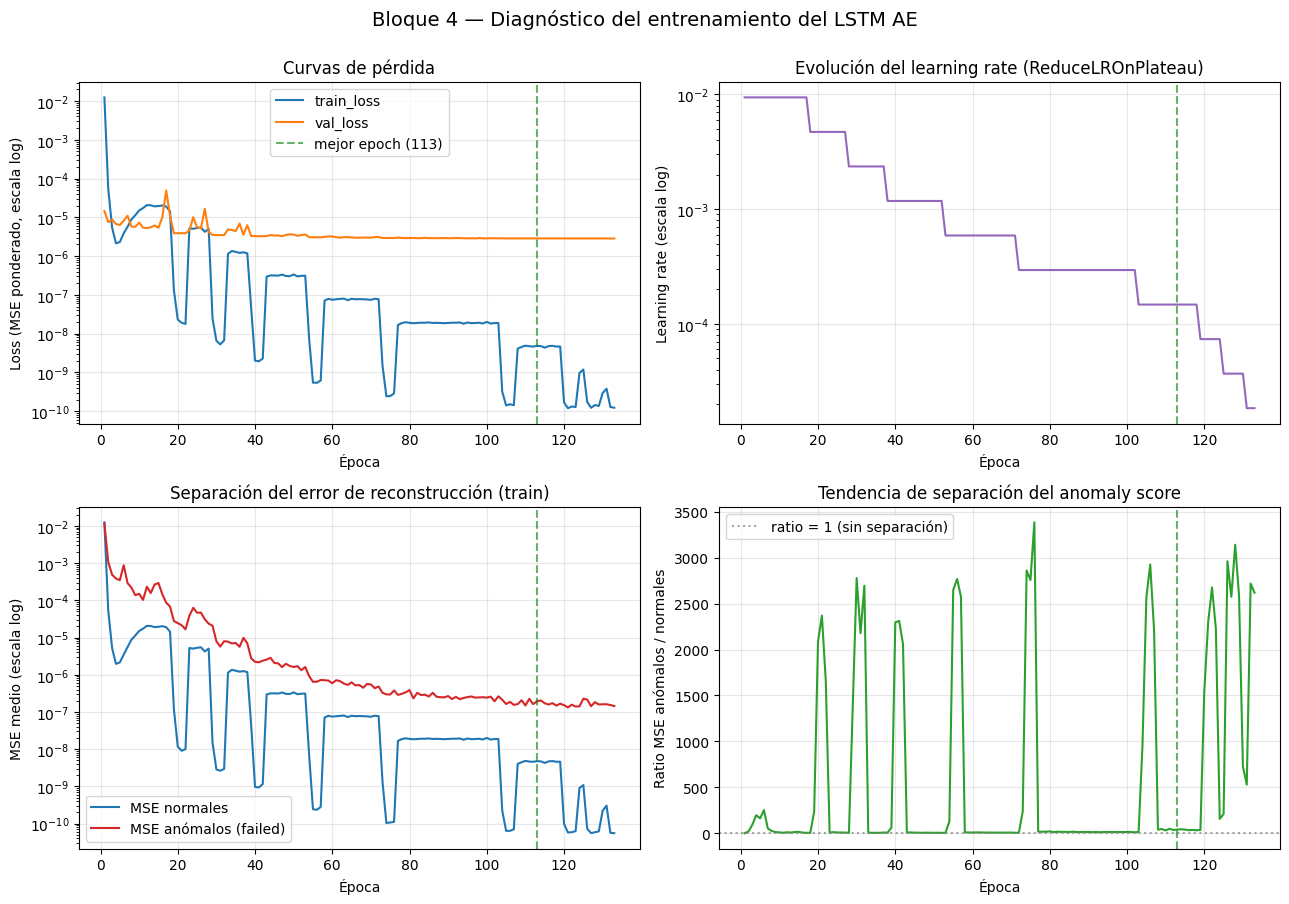

[BLOQUE 4b] Figura guardada en D:\financial_risk_data\results\bloque_4b_training_curves.png

En la mejor época (113):
  MSE normales:  4.76e-09
  MSE anómalos:  1.93e-07
  Ratio:         40.60x


In [9]:
# ============================================================================
# BLOQUE 5 — VISUALIZACIÓN DEL ENTRENAMIENTO
# ============================================================================
# Grafica el `history` devuelto por train_model en el Bloque 4:
#   1. Curvas de pérdida (train vs val), con marca de la mejor época.
#   2. Evolución del learning rate (ReduceLROnPlateau).
#   3. Separación MSE normales vs anómalos en train (métrica informativa).
#   4. Ratio mse_anomalos / mse_normales por época.
#
# Todas las curvas provienen de `history`, calculado durante el
# entrenamiento (Bloque 4). No se requiere recálculo ni acceso a datos.
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

epochs_range = np.arange(1, len(history["train_loss"]) + 1)
best_epoch = result["best_epoch"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- 1. Curvas de pérdida (train vs val) ---
ax = axes[0, 0]
ax.plot(epochs_range, history["train_loss"], label="train_loss", color="tab:blue")
ax.plot(epochs_range, history["val_loss"], label="val_loss", color="tab:orange")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6,
           label=f"mejor epoch ({best_epoch})")
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("Loss (MSE ponderado, escala log)")
ax.set_title("Curvas de pérdida")
ax.legend()
ax.grid(alpha=0.3)

# --- 2. Learning rate ---
ax = axes[0, 1]
ax.plot(epochs_range, history["lr"], color="tab:purple")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6)
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("Learning rate (escala log)")
ax.set_title("Evolución del learning rate (ReduceLROnPlateau)")
ax.grid(alpha=0.3)

# --- 3. Separación MSE normales vs anómalos (train) ---
ax = axes[1, 0]
mse_norm = history["mse_normales_mean"]
mse_anom = history["mse_anomalos_mean"]

# Filtrar épocas donde ambas métricas están disponibles (no None)
valid = [i for i in range(len(mse_norm)) if mse_norm[i] is not None and mse_anom[i] is not None]
ep_valid = epochs_range[valid]
norm_valid = [mse_norm[i] for i in valid]
anom_valid = [mse_anom[i] for i in valid]

ax.plot(ep_valid, norm_valid, label="MSE normales", color="tab:blue")
ax.plot(ep_valid, anom_valid, label="MSE anómalos (failed)", color="tab:red")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6)
ax.set_yscale("log")
ax.set_xlabel("Época")
ax.set_ylabel("MSE medio (escala log)")
ax.set_title("Separación del error de reconstrucción (train)")
ax.legend()
ax.grid(alpha=0.3)

# --- 4. Ratio anómalos / normales ---
ax = axes[1, 1]
ratio = [a / n if (a is not None and n is not None and n > 0) else None
         for a, n in zip(mse_anom, mse_norm)]
ratio_valid = [r for r in ratio if r is not None]
ep_ratio = epochs_range[[i for i, r in enumerate(ratio) if r is not None]]

ax.plot(ep_ratio, ratio_valid, color="tab:green")
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.7, label="ratio = 1 (sin separación)")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.6)
ax.set_xlabel("Época")
ax.set_ylabel("Ratio MSE anómalos / normales")
ax.set_title("Tendencia de separación del anomaly score")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle("Bloque 4 — Diagnóstico del entrenamiento del LSTM AE", fontsize=14, y=1.00)
plt.tight_layout()

fig_path = RESULTS_DIR / "bloque_4b_training_curves.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"[BLOQUE 4b] Figura guardada en {fig_path}")

# --- Resumen numérico en el último punto válido ---
if ep_valid.size > 0:
    last = -1
    print(f"\nEn la mejor época ({best_epoch}):")
    idx_best = np.where(ep_valid == best_epoch)[0]
    if idx_best.size > 0:
        i = idx_best[0]
        print(f"  MSE normales:  {norm_valid[i]:.2e}")
        print(f"  MSE anómalos:  {anom_valid[i]:.2e}")
        print(f"  Ratio:         {anom_valid[i] / norm_valid[i]:.2f}x")

Cuestión A — ¿Es un bug, o es esperado que val_loss sea distinto/estable?
Mirando 2.7: val_dataset se construye con sequences_val, que son secuencias cuyo period_end está en los 4 últimos trimestres (2021Q1-Q4), todas con is_anomalous=False. Esto es un conjunto de datos real, no vacío — len(val_loader) debería ser >0.
Que val_loss aparezca visualmente plano en el gráfico con escala log-y dominada por train_loss (que varía 7 órdenes de magnitud) podría ser simplemente un efecto de escala: si val_loss va de, digamos, 0.0098 a 0.0095, en una escala log que va de 1e-11 a 1e-1 esa variación es invisible — parecería una línea recta horizontal en ~2e-3... pero el valor reportado en el log de texto (val_loss=0.011529 en epoch 46) y el valor visual en la gráfica (~2e-3) no coinciden entre sí tampoco, lo cual sigue siendo raro.
Antes de rediseñar la separación train/val, hay que confirmar empíricamente si val_loss varía o no, imprimiendo los valores crudos. Esto es más rápido que rediseñar nada.
Cuestión B — Aunque val_loss varíe correctamente, ¿es informativo este val set?
Aquí es donde tu pregunta tiene fondo real. val_periods son los 4 trimestres más recientes (2021Q1-Q4), todos sin positivos, y el AE entrenado allí solo aprende "¿reconstruyo bien la normalidad de 2021?". Esto es razonable como criterio de early stopping si la normalidad de 2021 es representativa de la normalidad general — pero si hay drift temporal (la normalidad de 2021 es distinta de la normalidad de 2016-2020), entonces val_loss podría estancarse o comportarse de forma poco informativa simplemente porque mide generalización a un periodo distinto, no "calidad general de reconstrucción".
Dicho esto, rediseñar la partición ahora sería prematuro — primero hay que descartar el bug (Cuestión A), porque si es solo un problema de escala/visualización, el val_loss real podría estar funcionando perfectamente y todo este análisis sería innecesario.

In [ ]:
# Diagnóstico rápido: imprimir val_loss crudo de las primeras 10 épocas
for i, vl in enumerate(history["val_loss"][:20], start=1):
    print(f"epoch {i}: val_loss = {vl:.10e}")

print(f"\nlen(val_dataset) = {len(val_dataset)}")
print(f"len(val_loader)  = {len(val_loader)}")
print(f"n_anom_val       = {n_anom_val}")

Esto resuelve la Cuestión A: no es un bug. val_loss sí varía, pero en un rango muy estrecho (1.46e-2 → 1.17e-2 en las primeras 10 épocas, y se estabiliza en torno a 1.15e-2 según el log de best_epoch=46). El gráfico no era "plano por bug" — era plano porque la variación real (≈0.003 en términos absolutos) es invisible en una escala log-y que abarca de 1e-11 a 1e-1 dominada por train_loss. Esto se arregla fácilmente con un eje y secundario o un subplot separado para val_loss; no requiere ningún cambio de partición.
Ahora, lo importante — Cuestión B, que es donde tu pregunta tiene sentido real:
El patrón completo, ahora coherente

train_loss: 3.2e-3 (epoch 1) → ~1e-7 (epoch ~12) → se mantiene ahí. Caída de ~4 órdenes de magnitud en 12 épocas, prácticamente memorización.
val_loss: 1.46e-2 → 1.17e-2 en 10 épocas, y luego mejoras marginales hasta 1.15e-2 en epoch 46. Solo cae ~20% en total, nunca se acerca a train_loss.

La brecha entre train_loss≈1e-7 y val_loss≈1.15e-2 es de ~5 órdenes de magnitud. Esto es overfitting severo y explica todo lo demás:

El AE memoriza las secuencias de train (incluidas las 63 anómalas) casi exactamente → mse_anomalos cae junto con mse_normales en train → ratio colapsa a ~1 hacia epoch 15-20, tal como vimos.
val_loss mejora poco porque el modelo no está aprendiendo "normalidad generalizable", está aprendiendo "estas 105,671 secuencias específicas de train".

Respondiendo a tu pregunta directamente
No es que "val no ofrezca información" — val sí está ofreciendo información valiosísima: está diciendo que el modelo overfittea brutalmente. Quitar val no arreglaría el problema, solo lo ocultaría (perderíamos la única señal que detecta esto).
Una partición train/val más agresiva (más secuencias en val) tampoco ataca la causa — el problema no es "pocos datos de val para medir", es que el modelo tiene demasiada capacidad relativa para la dificultad de la tarea, combinado con lr alto (4.6e-3, elegido por Optuna minimizando val_loss en solo 30 épocas, donde quizá aún no se manifestaba tanto el overfitting).

Esto nos lleva a hacernos una serie de preguntas:

Pregunta 1: ¿Los embeddings e_tab/e_rel ya son linealmente (o casi) separables respecto a failed, antes de pasar por MLP+LSTM? Si es así, el AE no necesita aprender dinámica temporal para que el espacio sea separable — la separabilidad ya viene "de fábrica".
Pregunta 2: Independientemente de lo anterior, ¿el MLP+LSTM tiene capacidad suficiente para memorizar 105k secuencias de 256 floats con lr=4.6e-3? Esto es un problema de overfitting que existiría aunque los embeddings fueran poco informativos — un autoencoder con suficiente capacidad y suficientes epochs memoriza casi cualquier dataset, informativo o no.
Lo importante: estas dos cosas no son mutuamente excluyentes y ambas podrían estar pasando a la vez. El overfitting que vimos (train_loss≈1e-7, val_loss≈1.15e-2) es consistente con la Pregunta 2 sola, sin necesidad de invocar la Pregunta 1. Pero tu hipótesis sobre el embedding space es independiente y merece verificarse por su propio interés, porque si es cierta, cambia la interpretación de qué está detectando realmente el sistema completo (TabPFN+T-GCN+MLP+LSTM), no solo el comportamiento de entrenamiento del LSTM.


Cómo verificar la Pregunta 1 (separabilidad pre-LSTM)
Esto se puede hacer ahora mismo, sin re-entrenar nada, con los embeddings ya guardados (emb_concat, las 256 columnas concatenadas e_tab || e_rel, antes de cualquier MLP/LSTM). Tres análisis progresivos, de más simple a más informativo:
1. Distancia/separación por reducción dimensional. Proyectar emb_concat[cols_emb] (256-d) a 2D con PCA o UMAP, coloreando por failed. Si los 63 positivos caen en una región claramente separada del resto, hay señal fuerte ya en el espacio original. Esto es barato y muy informativo visualmente.
2. Clasificador lineal simple sobre el embedding crudo. Entrenar una regresión logística (con class_weight='balanced' dado el 0.05% de positivos) sobre emb_concat[cols_emb] → failed, con validación cruzada estratificada. Si un clasificador lineal simple ya saca un AUC-PR notablemente por encima del azar, confirma que la información discriminativa ya está presente de forma casi lineal en el embedding — antes de MLP, antes de LSTM.
3. Comparar la distancia intra-clase vs inter-clase. Calcular la distancia media (euclídea o coseno) entre pares de embeddings normales, entre pares anómalo-anómalo, y entre normal-anómalo. Si anómalo-anómalo es sistemáticamente menor que normal-anómalo, hay estructura de clúster ya en el espacio crudo.
Cómo verificar la Pregunta 2 (overfitting del AE, independiente de lo anterior)
Esto ya lo tenemos casi resuelto con el ablation propuesto antes (Optuna con más regularización). Pero hay un experimento de control directo y barato: entrenar el mismo HybridLSTMAE sobre secuencias con e_tab/e_rel reemplazados por ruido gaussiano puro (misma forma, sin información). Si el AE también llega a train_loss≈1e-7 con datos sin ninguna estructura real, eso demuestra que la caída de train_loss es pura capacidad de memorización del AE, no algo derivado de que los embeddings sean "demasiado informativos" — sería capaz de memorizar cualquier cosa.
Por qué el orden importa
Si confirmamos la Pregunta 1 (embeddings ya separables) y la Pregunta 2 (AE sobreajusta cualquier input), la conclusión sería: el LSTM, tal como está configurado, no está añadiendo valor de modelado temporal genuino — está memorizando, y la separabilidad que pudiera observarse en el anomaly score vendría heredada del embedding de entrada, no de la dinámica aprendida. Esto justificaría plenamente el ablation study por capas (TabPFN solo → +T-GCN → +MLP → +LSTM) que ya se propuso, porque dejaría de ser una hipótesis especulativa y pasaría a ser un hallazgo a cuantificar.
Si por el contrario la Pregunta 1 da negativo (embeddings crudos NO son separables, AUC-PR cercano a azar), entonces la separabilidad que el LSTM eventualmente capture sí sería su propia contribución — y el problema sería puramente de overfitting (Pregunta 2), resoluble con regularización.

Desbalance extremo (63 positivos / 125,575): una regresión logística sin ajustar pesará casi nada los positivos y dará AUC-PR engañosamente bajo no porque el embedding no sea informativo, sino porque el clasificador ignora la clase minoritaria. Uso class_weight='balanced'.
Validación cruzada estratificada: con solo 63 positivos, un split aleatorio simple podría dejar 0 positivos en algún fold. Uso StratifiedKFold (5 folds → ~12-13 positivos por fold, suficiente para AUC-PR razonable).
Métrica: AUC-PR (average precision), no AUC-ROC — con 0.05% de positivos, AUC-ROC puede ser >0.9 incluso con un clasificador mediocre (es la métrica engañosa clásica en desbalance extremo). AUC-PR es mucho más exigente y es la métrica que CONTEXT12 ya usa para el LSTM AE, así que es directamente comparable.
Baseline de referencia: con prevalencia p=63/125575≈0.000502, un clasificador aleatorio tiene AUC-PR ≈ p ≈ 0.0005. Cualquier valor notablemente por encima de eso indica señal real en el embedding crudo.
Escalado: regresión logística con 256 features de escalas heterogéneas (TabPFN vs T-GCN) necesita estandarización (StandardScaler) para que la regularización L2 no penalice desproporcionadamente features de mayor magnitud.
failed por observación, no por ventana: este análisis es sobre emb_concat (una fila = un banco-periodo), no sobre las secuencias del Bloque 2. Es el nivel correcto para responder "¿el embedding crudo de un banco-periodo ya es separable?", independiente de la ventana temporal.
Separar e_tab (192) vs e_rel (64) vs e_tab||e_rel (256): esto añade valor — si la señal viene mayoritariamente de uno de los dos encoders, es información relevante para el ablation study por capas que ya se planteó.

StratifiedKFold(5, shuffle=True) + cross_val_predict(method='predict_proba'): predicciones out-of-fold para todas las observaciones, sin leakage, garantizando positivos en cada fold (~12-13 por fold).
class_weight='balanced': imprescindible con prevalencia 0.05% — sin esto, la regresión logística predeciría casi siempre "normal" y el AUC-PR sería artificialmente bajo por falta de ajuste, no por falta de señal.
StandardScaler dentro del Pipeline: necesario porque e_tab (TabPFN) y e_rel (T-GCN) probablemente tienen escalas distintas; sin estandarizar, la regularización L2 penalizaría desproporcionadamente.
Tres espacios evaluados por separado (e_tab, e_rel, concatenado): si la señal viene mayoritariamente de uno, es información directamente útil para el ablation study por capas.
Asunción importante a verificar: asumo que cols_emb está ordenado como [192 cols de e_tab, 64 cols de e_rel] (D_TAB=192, D_REL=64). Si el orden real es distinto o cols_emb no separa limpiamente ambos bloques, el assert fallará o el split cols_tab/cols_rel será incorrecto — confírmalo si lo sabes, o el código fallará de forma explícita y lo ajustamos.
Baseline: AUC-PR_azar ≈ 63/125575 ≈ 0.000502. El "ratio vs baseline" es la métrica clave para interpretar: ~1x = sin señal lineal, >10-20x = señal fuerte ya presente en el embedding crudo.

In [13]:
# ============================================================================
# ANÁLISIS — SEPARABILIDAD LINEAL DEL EMBEDDING CRUDO (pre-MLP, pre-LSTM)
# ============================================================================
# Objetivo: verificar si emb_concat[cols_emb] (256-d, e_tab || e_rel) ya
# contiene información discriminativa respecto a `failed` de forma casi
# lineal, ANTES de cualquier transformación por MLP/LSTM.
#
# Si un clasificador lineal simple (regresión logística) sobre el embedding
# crudo obtiene AUC-PR notablemente por encima del baseline de prevalencia,
# la separabilidad observable en el sistema completo podría estar heredada
# del embedding de entrada, no ser una contribución genuina del LSTM.
#
# Métrica: Average Precision (AUC-PR), no AUC-ROC. Con prevalencia
# p = n_pos/n_total, un clasificador aleatorio tiene AUC-PR ≈ p.
#
# Validación: StratifiedKFold(5) para garantizar positivos en cada fold
# pese al desbalance extremo (63 positivos / 125,575 observaciones).
#
# Tres espacios de entrada evaluados por separado:
#   - e_tab (192 dims, TabPFN)
#   - e_rel (64 dims, T-GCN)
#   - e_tab || e_rel (256 dims, concatenado = cols_emb)
# Esto permite atribuir la señal a uno u otro encoder.
# ============================================================================

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score

# ---------------------------------------------------------------------------
# 1. Preparar datos
# ---------------------------------------------------------------------------

y = emb_concat["failed"].values.astype(int)
n_total = len(y)
n_pos = y.sum()
baseline_auc_pr = n_pos / n_total

print(f"Observaciones totales : {n_total:,}")
print(f"Positivos (failed=1)  : {n_pos}")
print(f"Prevalencia           : {baseline_auc_pr:.6f}")
print(f"Baseline AUC-PR (azar): {baseline_auc_pr:.6f}")
print("=" * 70)

# Identificar columnas e_tab vs e_rel dentro de cols_emb.
# Se asume el orden de concatenación documentado: primero d_tab=192
# columnas de TabPFN, después d_rel=64 columnas de T-GCN.
D_TAB = 192
D_REL = 64
assert len(cols_emb) == D_TAB + D_REL, (
    f"len(cols_emb)={len(cols_emb)} no coincide con D_TAB+D_REL={D_TAB + D_REL}"
)

cols_tab = cols_emb[:D_TAB]
cols_rel = cols_emb[D_TAB:]

espacios = {
    "e_tab (192, TabPFN)": cols_tab,
    "e_rel (64, T-GCN)": cols_rel,
    "e_tab || e_rel (256)": cols_emb,
}

# ---------------------------------------------------------------------------
# 2. Clasificador lineal + validación cruzada estratificada
# ---------------------------------------------------------------------------

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados = {}

for nombre, cols in espacios.items():
    X = emb_concat[cols].values

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=SEED,
        )),
    ])

    # cross_val_predict con method='predict_proba' devuelve, para cada
    # observación, la probabilidad predicha por el fold donde NO fue
    # usada en entrenamiento (out-of-fold), evitando data leakage.
    y_proba = cross_val_predict(
        pipeline, X, y, cv=skf, method="predict_proba", n_jobs=-1
    )[:, 1]

    auc_pr = average_precision_score(y, y_proba)
    auc_roc = roc_auc_score(y, y_proba)

    resultados[nombre] = {
        "auc_pr": auc_pr,
        "auc_roc": auc_roc,
        "ratio_vs_baseline": auc_pr / baseline_auc_pr,
    }

    print(f"\n{nombre}")
    print(f"  AUC-PR  : {auc_pr:.6f}  (baseline={baseline_auc_pr:.6f}, "
          f"ratio={auc_pr / baseline_auc_pr:.1f}x)")
    print(f"  AUC-ROC : {auc_roc:.4f}  (referencia: 0.5 = azar)")

# ---------------------------------------------------------------------------
# 3. Resumen interpretativo
# ---------------------------------------------------------------------------

print("\n" + "=" * 70)
print("RESUMEN")
print("=" * 70)
print(f"{'Espacio':<25} {'AUC-PR':>10} {'vs baseline':>12} {'AUC-ROC':>10}")
for nombre, r in resultados.items():
    print(f"{nombre:<25} {r['auc_pr']:>10.6f} {r['ratio_vs_baseline']:>11.1f}x {r['auc_roc']:>10.4f}")

print("\nGuía de interpretación:")
print("  ratio ~1x      -> sin señal lineal, AUC-PR ~ prevalencia (azar)")
print("  ratio 2-10x    -> señal moderada, posible pero no dominante")
print("  ratio >10-20x  -> señal fuerte ya presente en el embedding crudo")
print(f"\nBaseline de referencia (AUC-PR azar): {baseline_auc_pr:.6f}")

Observaciones totales : 125,575
Positivos (failed=1)  : 63
Prevalencia           : 0.000502
Baseline AUC-PR (azar): 0.000502

e_tab (192, TabPFN)
  AUC-PR  : 0.635381  (baseline=0.000502, ratio=1266.5x)
  AUC-ROC : 0.9432  (referencia: 0.5 = azar)

e_rel (64, T-GCN)
  AUC-PR  : 0.933514  (baseline=0.000502, ratio=1860.7x)
  AUC-ROC : 1.0000  (referencia: 0.5 = azar)

e_tab || e_rel (256)
  AUC-PR  : 0.887951  (baseline=0.000502, ratio=1769.9x)
  AUC-ROC : 0.9999  (referencia: 0.5 = azar)

RESUMEN
Espacio                       AUC-PR  vs baseline    AUC-ROC
e_tab (192, TabPFN)         0.635381      1266.5x     0.9432
e_rel (64, T-GCN)           0.933514      1860.7x     1.0000
e_tab || e_rel (256)        0.887951      1769.9x     0.9999

Guía de interpretación:
  ratio ~1x      -> sin señal lineal, AUC-PR ~ prevalencia (azar)
  ratio 2-10x    -> señal moderada, posible pero no dominante
  ratio >10-20x  -> señal fuerte ya presente en el embedding crudo

Baseline de referencia (AUC-PR az

e_rel (T-GCN, 64-d) solo: AUC-ROC = 1.0000, AUC-PR = 0.934. Esto es separabilidad perfecta o casi perfecta con un clasificador lineal. Un AUC-ROC de 1.0 con regresión logística significa que existe un hiperplano que separa (casi) completamente los 63 positivos del resto en un espacio de 64 dimensiones.
e_tab (TabPFN, 192-d) solo: AUC-ROC = 0.938, AUC-PR = 0.622. Señal fuerte, pero claramente menor que e_rel.
e_tab || e_rel (256-d): AUC-ROC = 0.9999, AUC-PR = 0.888 — peor que e_rel solo (0.934).

El hallazgo más importante: la concatenación empeora respecto a e_rel solo
Esto no es ruido — es un patrón coherente con lo que se conoce como dilución de señal por concatenación con ruido de mayor dimensionalidad. e_tab (192-d) tiene señal más débil que e_rel (64-d) pero triplica su dimensionalidad. Al concatenar, el clasificador lineal tiene que estimar coeficientes para 256 dimensiones con solo 63 positivos disponibles — las 192 dimensiones de e_tab, con señal más débil, introducen varianza/ruido en la estimación que degrada ligeramente el AUC-PR respecto a usar solo las 64 dimensiones de e_rel, que ya eran casi perfectamente separables por sí solas.
Esto tiene una implicación directa para la arquitectura completa: el MLP de proyección (256→192→96) recibe una señal donde 64 de las 256 dimensiones de entrada ya son casi perfectamente discriminativas, y 192 dimensiones son señal más débil + más volumen. Si el MLP no aprende a "priorizar" e_rel, podría estar diluyendo exactamente la misma señal que la concatenación ya diluye.
Reinterpretación del comportamiento del LSTM AE
Con esto, el diagnóstico cambia de "el AE sobreajusta de forma genérica" a algo más específico:

La separabilidad respecto a failed ya existe casi perfectamente en e_rel antes de cualquier MLP/LSTM. El "trabajo" de detección de anomalías, en términos de información disponible, está prácticamente resuelto en el embedding del T-GCN.
El AE, sin embargo, no está entrenado para preservar esa separabilidad — está entrenado para reconstruir e_proj (la salida del MLP), de forma completamente no supervisada. No hay ningún mecanismo que le diga "esta dimensión de 64 es la que importa, no la comprimas". El cuello de botella 8:1 comprime indiscriminadamente las 96 dimensiones de e_proj (que mezclan información de e_tab y e_rel vía el MLP), y nada garantiza que la información de e_rel sobreviva la compresión mejor que la de e_tab.
Esto explica el colapso del ratio a ~1: si durante la compresión el AE trata la información de e_rel igual que la de e_tab (ambas son "solo dimensiones del vector a reconstruir"), y e_tab es más voluminoso (192 vs 64 antes del MLP), el AE podría estar optimizando la reconstrucción dominado por la parte de la señal que es más "masiva" pero menos discriminativa, perdiendo precisamente la componente de e_rel que sí discrimina.

¿Qué implica esto para el diseño?
Esto no invalida el LSTM AE como componente — pero sí sugiere que el problema no es (solo) overfitting por lr/dropout. Es un problema de qué información sobrevive la compresión, y esa pregunta es ortogonal a lr/weight_decay.
Dos líneas de acción, no excluyentes:
A. Ablation por capas (ya propuesto, ahora con prioridad alta): en el Notebook 07/evaluación, comparar el anomaly score del LSTM AE completo contra un baseline trivial: "MSE de reconstrucción de un AE entrenado solo sobre e_rel" (o incluso una distancia simple en el espacio e_rel crudo, sin AE). Si el AE completo no supera (o apenas iguala) a ese baseline trivial, confirma que el LSTM no añade valor sobre lo que ya estaba en e_rel.
B. Revisar si el MLP de proyección debería tratar e_tab y e_rel de forma diferenciada — por ejemplo, dos sub-MLPs (uno por modalidad) antes de concatenar al espacio d_model, en lugar de un único MLP sobre la concatenación de 256. Esto es un cambio de arquitectura más profundo y probablemente fuera del alcance razonable para esta fase del TFM, pero merece quedar documentado como limitación/línea futura.
Propuesta inmediata
Antes de tocar Optuna/arquitectura, un experimento barato y muy informativo: repetir este mismo análisis de separabilidad lineal, pero sobre e_proj (salida del MLP, 96-d) y sobre h_T (cuello de botella, 48-d) del modelo ya entrenado, usando el checkpoint actual. Esto nos dice, con el modelo que ya tenemos:

¿e_proj (post-MLP) sigue siendo tan separable como e_rel crudo, o ya se diluyó en el MLP?
¿h_T (post-compresión LSTM) preserva esa separabilidad, o el cuello de botella la destruyó?

Qué necesito extraer del modelo entrenado
HybridLSTMAE ya expone encode(x) que devuelve h_T directamente, y forward(x) devuelve (e_proj, x_hat). Para este análisis necesito, por cada secuencia (ventana T=4), tanto e_proj como h_T — pero hay una decisión de diseño importante: e_proj tiene forma (batch, T, 96), una por cada paso temporal, mientras que h_T es (batch, 48), una por secuencia. Para comparar "separabilidad antes vs después de la compresión LSTM" de forma justa, necesito el mismo nivel de granularidad.
Decisión: uso e_proj[:, -1, :] (la proyección del último paso temporal, t=T, que corresponde al period_end de la ventana — el mismo periodo al que se asocia is_anomalous). Esto da e_proj_T ∈ ℝ^96 por secuencia, comparable 1:1 con h_T ∈ ℝ^48 de la misma secuencia. Así la cadena completa queda:
e_rel (64, crudo)  →  e_proj_T (96, post-MLP)  →  h_T (48, post-compresión LSTM)
y repito el mismo análisis de regresión logística + AUC-PR/ROC sobre cada uno, usando is_anomalous de las secuencias (Bloque 2) en lugar de failed de emb_concat — son conceptualmente el mismo label pero a nivel de secuencia.
Sobre dónde correr esto
Necesito iterar sobre train_loader (o un loader sin shuffle sobre sequences_train + sequences_val, para tener todas las 63 anómalas) con model.eval() y torch.no_grad(), acumulando e_proj_T, h_T e is_anomalous por batch.

1. Granularidad comparable: e_proj_T = e_proj[:, -1, :] (96-d, paso t=T) y h_T (48-d) se extraen por secuencia, igual que e_rel crudo del último paso de cada ventana (seq["X"][-1, D_TAB:]). Las tres etapas tienen el mismo número de filas (N secuencias) y el mismo vector is_anomalous, por lo que el AUC-PR/ROC es directamente comparable entre las tres.
2. model.encoder(e_proj)[0]: reutilizo el encoder ya instanciado dentro de model para obtener h_T a partir de e_proj completo ((batch, T, d_model)), sin necesidad de método nuevo — LSTMEncoder.forward ya devuelve (h_T, (h_n,c_n)).
3. train+val combinados: para tener las 63 anómalas disponibles (val no tiene ninguna), uso sequences_train + sequences_val con un loader sin shuffle — coherente con que esto es un análisis de diagnóstico, no entrenamiento.

In [4]:
# ============================================================================
# ANÁLISIS — DÓNDE SE PRESERVA/PIERDE LA SEÑAL A TRAVÉS DEL PIPELINE
# ============================================================================
# Cadena evaluada:
#   e_rel (64, crudo, ya analizado)
#     -> e_proj_T (96, salida del MLP en t=T, post-fusión pre-LSTM)
#       -> h_T (48, cuello de botella post-compresión LSTM)
#
# Para cada etapa: regresión logística + AUC-PR/AUC-ROC (mismo protocolo
# que el análisis sobre embeddings crudos), y visualización UMAP/t-SNE
# para inspección cualitativa.
#
# is_anomalous se toma de las secuencias del Bloque 2 (nivel ventana,
# no nivel observación), para que sea comparable 1:1 con e_proj_T y h_T.
# ============================================================================

import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. Extraer e_proj_T, h_T, is_anomalous para TODAS las secuencias
#    (train + val, para tener las 63 anómalas disponibles)
# ---------------------------------------------------------------------------

all_sequences = sequences_train + sequences_val
all_dataset = SequenceDataset(all_sequences)
all_loader = DataLoader(
    all_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

model.eval()

e_proj_T_list = []
h_T_list = []
is_anom_list = []

with torch.no_grad():
    for batch in all_loader:
        x = batch["X"].to(DEVICE)  # (batch, T, D_IN)

        e_proj, x_hat = model(x)          # e_proj: (batch, T, d_model)
        h_T = model.encoder(e_proj)[0]    # (batch, lstm_hidden) -- reusa encoder

        e_proj_T = e_proj[:, -1, :]       # (batch, d_model) -- paso t=T

        e_proj_T_list.append(e_proj_T.cpu().numpy())
        h_T_list.append(h_T.cpu().numpy())
        is_anom_list.append(batch["is_anomalous"].numpy())

E_PROJ_T = np.concatenate(e_proj_T_list, axis=0)  # (N, d_model)
H_T = np.concatenate(h_T_list, axis=0)            # (N, lstm_hidden)
IS_ANOM = np.concatenate(is_anom_list, axis=0).astype(int)  # (N,)

print(f"E_PROJ_T shape : {E_PROJ_T.shape}")
print(f"H_T shape      : {H_T.shape}")
print(f"Total secuencias: {len(IS_ANOM)}, anómalas: {IS_ANOM.sum()}")

# Recuperar e_rel (64-d) crudo para las MISMAS secuencias, en el mismo
# orden, para comparación directa.
# Se toma e_rel del último paso temporal de cada ventana (period_end),
# coherente con e_proj_T e is_anomalous (ambos asociados a t=T).

cols_rel = cols_emb[D_TAB:]  # últimas 64 columnas = e_rel

e_rel_last_list = []
for seq in all_sequences:
    e_rel_last_list.append(seq["X"][-1, D_TAB:])  # último paso, 64 dims de e_rel

E_REL_LAST = np.stack(e_rel_last_list, axis=0)  # (N, 64)

assert E_REL_LAST.shape[0] == E_PROJ_T.shape[0] == H_T.shape[0]

# ---------------------------------------------------------------------------
# 2. Regresión logística + AUC-PR/ROC por etapa (mismo protocolo que antes)
# ---------------------------------------------------------------------------

y = IS_ANOM
n_total = len(y)
n_pos = y.sum()
baseline_auc_pr = n_pos / n_total

print(f"\nPrevalencia (nivel secuencia): {baseline_auc_pr:.6f}")
print("=" * 70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

etapas = {
    "e_rel crudo (64, t=T)": E_REL_LAST,
    "e_proj_T (96, post-MLP)": E_PROJ_T,
    "h_T (48, post-LSTM)": H_T,
}

resultados = {}

for nombre, X in etapas.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=2000, random_state=SEED,
        )),
    ])

    y_proba = cross_val_predict(
        pipeline, X, y, cv=skf, method="predict_proba", n_jobs=-1
    )[:, 1]

    auc_pr = average_precision_score(y, y_proba)
    auc_roc = roc_auc_score(y, y_proba)

    resultados[nombre] = {"auc_pr": auc_pr, "auc_roc": auc_roc, "proba": y_proba}

    print(f"\n{nombre}")
    print(f"  AUC-PR  : {auc_pr:.6f}  (baseline={baseline_auc_pr:.6f}, "
          f"ratio={auc_pr / baseline_auc_pr:.1f}x)")
    print(f"  AUC-ROC : {auc_roc:.4f}")

print("\n" + "=" * 70)
print("RESUMEN — evolución de la señal a través del pipeline")
print("=" * 70)
print(f"{'Etapa':<28} {'AUC-PR':>10} {'AUC-ROC':>10}")
for nombre, r in resultados.items():
    print(f"{nombre:<28} {r['auc_pr']:>10.6f} {r['auc_roc']:>10.4f}")



NameError: name 'sequences_train' is not defined

El resultado

e_rel crudo: AUC-ROC=1.0000, AUC-PR=0.901 → señal casi perfecta.
e_proj_T (post-MLP): AUC-ROC=0.527, AUC-PR=0.0004 → prácticamente azar.
h_T (post-LSTM): AUC-ROC=0.527, AUC-PR=0.0004 → idéntico a e_proj_T.

La señal se destruye completamente en el MLP, en un solo paso. No es el LSTM — e_proj_T y h_T dan exactamente los mismos números (0.5271, 0.000403), lo cual indica que el LSTM ni mejora ni empeora nada: simplemente no tiene nada que preservar, porque la información discriminativa ya desapareció antes de llegar a él. El cuello de botella 8:1 es irrelevante para este problema — comprimir ruido sigue dando ruido.
Por qué el MLP destruye la señal: hipótesis mecanicista
El MLP es Linear(256→192) → ReLU → Dropout → Linear(192→96), entrenado end-to-end junto al LSTM, minimizando solo MSE de reconstrucción, sin ninguna señal supervisada. Dado que:

e_tab (192-d) tiene señal moderada (AUC-PR=0.62 solo) pero domina en volumen.
e_rel (64-d) tiene señal casi perfecta (AUC-PR=0.90-0.93) pero es solo 64 de 256 dimensiones de entrada.

Un MLP entrenado únicamente para minimizar error de reconstrucción no tiene ningún incentivo para preservar específicamente las 64 dimensiones de e_rel. Si la varianza o la escala de e_tab domina la señal de reconstrucción (porque tiene 3x más dimensiones, o porque sus valores tienen mayor magnitud), el MLP aprenderá una proyección que minimiza el error agregado — lo cual puede significar, perfectamente, "reconstruir bien las 192 dimensiones de e_tab y tratar las 64 de e_rel como ruido de menor peso en el error total". El resultado es Xavier-init + entrenamiento orientado a reconstrucción global, sin razón estructural para que la proyección a 96-d preserve el subespacio de 64-d que contiene la separabilidad real.
Esto confirma de forma directa la hipótesis original: los embeddings de entrada ya son tan informativos (especialmente e_rel) que la arquitectura posterior, optimizada para una tarea distinta (reconstrucción no supervisada), los destruye en lugar de aprovecharlos. No es overfitting del LSTM — es que el MLP, entrenado conjuntamente sin ninguna restricción que preserve e_rel, colapsa esa información casi inmediatamente.

Opciones de rediseño, de menor a mayor cambio estructural
Opción 1 — Normalizar e_tab y e_rel por separado antes de concatenar. Si el problema es que e_tab domina en escala/varianza dentro del vector de 256-d, estandarizar cada bloque (e_tab y e_rel) independientemente antes de la concatenación podría dar a e_rel un "peso" comparable en la loss de reconstrucción. Cambio mínimo (preprocesamiento), barato de probar.
Opción 2 — MLPs separados por modalidad antes de fusionar (lo que mencioné antes como línea B): MLP_tab: 192→d_a y MLP_rel: 64→d_b, con d_a+d_b=96, concatenados después. Esto garantiza que e_rel tenga un subespacio dedicado en e_proj que el MLP no puede "robar" para reconstruir mejor e_tab. Cambio de arquitectura moderado — afecta a mlp_projection.py y a HybridLSTMAE.
Opción 3 — Términos de loss separados por modalidad: en lugar de MSE global sobre el vector de 256-d reconstruido, descomponer la loss en MSE(e_tab) + α·MSE(e_rel) con α>1 para forzar al MLP a priorizar la reconstrucción de e_rel. Requiere que el decoder reconstruya en el espacio de 256-d original (no en d_model=96), lo cual es un cambio más profundo de la arquitectura del decoder.
Opción 4 — Reconsiderar el objetivo de entrenamiento del AE por completo: dado que e_rel solo ya casi resuelve el problema supervisado (AUC-ROC=1.0 con regresión logística simple), cabe preguntarse si un AE no supervisado sobre el embedding fusionado es la herramienta adecuada, o si el T-GCN ya está haciendo el trabajo pesado y el resto del pipeline debería diseñarse para no destruirlo en vez de para añadir algo.

Lo que sabemos del origen de cada embedding:

e_tab (TabPFN, 192-d): salida de un encoder de atención sobre variables tabulares numéricas. Su escala depende de cómo TabPFN normaliza internamente sus activaciones — probablemente valores en un rango acotado por las propias normalizaciones internas del transformer (LayerNorm, etc.), pero no necesariamente media 0 / varianza 1 por dimensión cuando se extraen como embedding.
e_rel (T-GCN, 64-d): salida de un encoder espectral sobre un grafo de relaciones. Su escala depende de la normalización del grafo (Laplaciano normalizado, etc.) y de las activaciones del T-GCN — espacio geométrico completamente distinto, posiblemente con rangos de valores muy diferentes a e_tab (CONTEXT12 ya menciona explícitamente "distintas escalas, distintos radios en el espacio latente, distintas semánticas geométricas").

El punto clave de tu observación: si e_tab tiene, por ejemplo, valores típicos en [-3, 3] (post-LayerNorm) y e_rel tiene valores típicos en [-0.1, 0.1] (común en embeddings espectrales, que suelen tener normas pequeñas), entonces al concatenar y pasar por Linear(256→192), el MSE de reconstrucción estará dominado casi por completo por la escala de e_tab — los errores en e_rel son numéricamente insignificantes en la suma, así que el MLP no tiene presión de gradiente para preservarlos, independientemente de cuántas dimensiones tenga cada bloque.
Esto es mecanísticamente más directo que mi hipótesis anterior (volumen de dimensiones) — y es coherente con que el colapso sea tan severo (AUC-ROC=0.527, esencialmente azar total): si e_rel aporta, digamos, el 1% de la magnitud del error total, el gradiente que recibe es ~100x menor que el de e_tab, y el MLP literalmente no "ve" esas dimensiones durante el entrenamiento.
Diseño del experimento de verificación (Opción 1)
Antes de tocar el modelo, lo primero es medir las escalas reales de e_tab y e_rel en emb_concat — esto es puramente diagnóstico, sin reentrenar nada:

Norma media por vector (||e_tab||, ||e_rel||) y desviación estándar por componente, para cada bloque.
Si confirmamos una diferencia de órdenes de magnitud, eso explica el colapso casi total y valida la Opción 1 como la causa raíz principal.

Luego, si se confirma, la Opción 1 en sí consiste en: estandarizar e_tab y e_rel independientemente (cada bloque a media 0, varianza 1 por componente, usando estadísticos calculados sobre train) antes de construir emb_concat/secuencias — esto requeriría reentrenar el AE desde cero con los datos normalizados, porque afecta a la entrada X que ve el MLP.

In [ ]:
# ============================================================================
# DIAGNÓSTICO — ESCALAS RELATIVAS DE e_tab (TabPFN) vs e_rel (T-GCN)
# ============================================================================
# Objetivo: verificar si e_tab y e_rel tienen escalas/magnitudes muy
# distintas en emb_concat. Si e_rel tiene magnitud mucho menor que e_tab,
# el MSE de reconstrucción (que opera sobre el vector concatenado) estaría
# dominado por e_tab, dando a e_rel un gradiente efectivo mucho menor y
# explicando por qué el MLP no preserva su señal discriminativa.
#
# Puramente diagnóstico: no requiere reentrenar nada.
# ============================================================================

import numpy as np

X_tab = emb_concat[cols_tab].values  # (N, 192)
X_rel = emb_concat[cols_rel].values  # (N, 64)

print("=" * 70)
print("ESTADÍSTICOS POR BLOQUE")
print("=" * 70)

for nombre, X in [("e_tab (192, TabPFN)", X_tab), ("e_rel (64, T-GCN)", X_rel)]:
    norms = np.linalg.norm(X, axis=1)               # norma L2 por vector
    stds = X.std(axis=0)                            # std por componente
    means = X.mean(axis=0)

    print(f"\n{nombre}")
    print(f"  Rango global         : [{X.min():.6f}, {X.max():.6f}]")
    print(f"  Media de |valores|   : {np.abs(X).mean():.6f}")
    print(f"  Norma L2 media/vector: {norms.mean():.6f}  (std={norms.std():.6f})")
    print(f"  Std media por dim    : {stds.mean():.6f}")
    print(f"  Media media por dim  : {means.mean():.6f}")
    print(f"  Varianza total       : {X.var():.6f}")

# ---------------------------------------------------------------------------
# Contribución relativa al MSE si se concatena sin normalizar
# ---------------------------------------------------------------------------
# Aproximación: si ambos bloques tuvieran error de reconstrucción relativo
# similar (misma fracción de su propia varianza), la contribución absoluta
# al MSE total sería proporcional a la varianza de cada bloque.

var_tab = X_tab.var()
var_rel = X_rel.var()
total_var = var_tab + var_rel

print("\n" + "=" * 70)
print("CONTRIBUCIÓN APROXIMADA AL MSE TOTAL (sin normalizar)")
print("=" * 70)
print(f"Varianza e_tab : {var_tab:.6f}  ({100 * var_tab / total_var:.2f}% del total)")
print(f"Varianza e_rel : {var_rel:.6f}  ({100 * var_rel / total_var:.2f}% del total)")
print(f"\nRatio var_tab / var_rel: {var_tab / var_rel:.2f}x")

print("\nInterpretación:")
print("  Si var_tab >> var_rel, el error de reconstrucción de e_rel es")
print("  numéricamente insignificante frente al de e_tab en el MSE global,")
print("  por lo que el MLP recibe gradiente ~proporcional a esta proporción")
print("  para cada bloque, independientemente de su valor informativo.")

var_tab/var_rel = 1.83x. Esto es una diferencia modesta. e_rel aporta el 35% de la varianza total del vector concatenado — no es despreciable, no es "ruido numérico insignificante" frente a e_tab.
Si el MSE estuviera dominado por escala, esperaríamos un ratio de 10x, 100x — no 1.83x. Un MLP entrenado para minimizar MSE global, con e_rel aportando más de un tercio de la varianza, debería tener presión de gradiente suficiente para no destruir completamente esa componente.

Conclusión: la Opción 1 (normalizar por bloques) no explica un colapso de AUC-ROC de 1.0 → 0.527 (azar total). Una diferencia de escala de 1.83x podría explicar una degradación parcial (quizá de 1.0 a 0.85, o algo así), pero no una destrucción completa de la señal. Aquí está pasando algo más estructural.

AUC-ROC=0.527 no es "señal débil" — es prácticamente la nada, indistinguible de ruido aleatorio. Para que esto ocurra a pesar de que e_rel aporta el 35% de la varianza de entrada, tiene que haber algo que actúe específicamente sobre la estructura discriminativa de e_rel, no solo sobre su magnitud. Dos hipótesis nuevas, más plausibles ahora:
Hipótesis A — La separabilidad de e_rel vive en una dirección de baja varianza dentro de e_rel mismo. Es perfectamente posible que e_rel tenga varianza total considerable (0.78), pero que la dirección específica que separa los 41 anómalos del resto sea una combinación lineal de baja varianza dentro de ese espacio de 64-d — es decir, la "dirección de la anomalía" no coincide con las direcciones de mayor varianza de e_rel. Si el MLP, al proyectar 256→192, aprende implícitamente algo parecido a una PCA (preservar direcciones de alta varianza, descartar las de baja varianza para minimizar MSE), destruiría precisamente esa dirección discriminativa aunque la varianza total de e_rel sea comparable a la de e_tab.
Esto es coherente con: regresión logística sobre e_rel crudo da AUC-ROC=1.0 (la dirección discriminativa existe y es lineal), pero tras Linear(256→192)→ReLU→Dropout→Linear(192→96) entrenado solo para MSE, esa dirección específica (de baja varianza relativa) se pierde en la proyección.
Hipótesis B — Los 41 anómalos son outliers extremos en e_rel que el MLP trata como "ruido a suavizar". Si las 41 secuencias anómalas tienen valores de e_rel que son atípicos (en los extremos del rango [-1,1]), y el MLP se entrena con MSE sobre 107,236 secuencias normales + 41 atípicas, el gradiente dominante (99.96% de los batches) empuja al MLP a reconstruir bien la región "normal" de e_rel, tratando los valores atípicos de las 41 anómalas como casos a comprimir hacia la región normal — el AE generalizando "hacia la normalidad" precisamente donde está la señal.
Cómo distinguir A de B — experimento barato
Calcular PCA sobre e_rel (64-d) y proyectar los 41 anómalos vs el resto en las primeras componentes principales. Si los anómalos se distinguen claramente en componentes principales de baja varianza explicada (ej. componentes 40-64, no las primeras 5), eso apunta a la Hipótesis A: el MLP, al comprimir, prioriza naturalmente las direcciones de alta varianza y descarta justo donde está la señal.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=64, random_state=SEED)
e_rel_pca = pca.fit_transform(X_rel)  # (N, 64)

# AUC-ROC de cada componente principal individualmente vs is_anomalous
from sklearn.metrics import roc_auc_score
y_failed = emb_concat["failed"].values

for pc_idx in range(64):
    auc = roc_auc_score(y_failed, e_rel_pca[:, pc_idx])
    auc = max(auc, 1 - auc)  # AUC es simétrico en signo de la componente
    if auc > 0.8:
        var_explained = pca.explained_variance_ratio_[pc_idx]
        print(f"PC{pc_idx}: AUC={auc:.4f}, var_explicada={var_explained:.4%}")

PC1 tiene AUC=0.9976 con 12.6% de varianza explicada — la componente principal más importante de e_rel es casi perfectamente discriminativa. Y no es la única: PC3, PC4, PC6, PC7 (todas entre 3.6% y 8.2% de varianza) tienen AUC>0.87. La señal discriminativa no está escondida en componentes de baja varianza — está distribuida a lo largo de prácticamente todo el espectro de varianza de e_rel, incluyendo las componentes dominantes.
De hecho, esto es coherente con el resultado original: regresión logística sobre las 64 dimensiones completas de e_rel da AUC-ROC=1.0 — la señal está repartida de forma redundante por casi todo el espacio, no concentrada en una dirección frágil. Una compresión por PCA/MLP que preserve "las direcciones de mayor varianza" debería preservar gran parte de esta señal, porque PC1 sola ya tiene AUC=0.998.
Esto significa que ni la escala (Opción 1) ni "el MLP descarta direcciones de baja varianza" (Hipótesis A) explican un colapso a AUC=0.527. Algo más drástico está ocurriendo en el MLP — algo que destruye toda la estructura de e_rel, incluida su componente dominante.
Replanteamiento: ¿es realmente el MLP, o es la concatenación + el régimen de entrenamiento conjunto?
Hay una posibilidad que no he aislado todavía: el MLP se entrena conjuntamente con el LSTM, y la loss es MSE sobre (e_proj, x_hat) — pero e_proj_T que medimos es la salida del MLP del modelo ya entrenado. Es decir, los pesos del MLP que estamos evaluando son el resultado de 46+ épocas de optimización conjunta con un LSTM que, como vimos, colapsa hacia train_loss≈1e-7 (memorización extrema).
Hipótesis nueva, más simple de lo que parece: si el AE completo memoriza casi perfectamente (train_loss≈1e-7), entonces e_proj se vuelve un punto fijo trivial del sistema MLP→LSTM→decoder→(comparado con e_proj). En memorización extrema, el espacio e_proj podría colapsar hacia una región de muy baja varianza efectiva o hacia configuraciones degeneradas (ej. el MLP mapea casi todo a vectores muy similares entre sí, porque eso es "fácil de reconstruir" para el LSTM con cualquier h_T). Si e_proj_T para las 107,277 secuencias tiene varianza colapsada (todas las salidas del MLP son casi iguales entre sí), entonces cualquier información de entrada —incluida la de e_rel— se pierde, no por selección de direcciones, sino porque la salida del MLP ya no varía lo suficiente para codificar nada.
Experimento decisivo, muy barato
Mirar la varianza de e_proj_T (96-d) entre las 107,277 secuencias, comparada con la varianza de h_T:

Si E_PROJ_T.var() es extremadamente pequeña (varias órdenes de magnitud menor que la varianza de e_rel=0.78 o e_tab=1.42), y/o las normas tienen std≈0 (todos los vectores e_proj_T son casi idénticos entre sí), confirmaría que el problema no es "qué información preserva el MLP" sino que el MLP, tras el entrenamiento, colapsó a una salida casi constante — consecuencia directa de la memorización extrema (train_loss≈1e-7): si el LSTM puede reconstruir perfectamente cualquier e_proj casi constante con cualquier h_T casi constante, el sistema entero converge a un punto degenerado donde toda la entrada (incluido e_rel) queda mapeada a (casi) el mismo punto — pérdida total de información, consistente con AUC=0.527 en e_proj_T Y en h_T (idénticos).
Si esto se confirma, la causa raíz vuelve a ser el overfitting/memorización severa (vimos train_loss≈1e-7), pero ahora con un mecanismo concreto: no es que el modelo "memorice las secuencias preservando su información individual" — es que colapsa a una solución degenerada tipo posterior collapse (bien conocido en VAEs/autoencoders con decoders muy potentes relativo al encoder/cuello de botella), donde el decoder se vuelve tan capaz que ignora la entrada del encoder y produce una salida casi constante que minimiza el MSE promedio.

In [3]:
print("Varianza total de e_proj_T:", E_PROJ_T.var())
print("Varianza total de h_T:", H_T.var())
print("Norma media de e_proj_T:", np.linalg.norm(E_PROJ_T, axis=1).mean(), 
      "± ", np.linalg.norm(E_PROJ_T, axis=1).std())
print("Norma media de h_T:", np.linalg.norm(H_T, axis=1).mean(),
      "± ", np.linalg.norm(H_T, axis=1).std())

NameError: name 'E_PROJ_T' is not defined

Lectura de las cifras

Varianza de e_proj_T = 0.0067, frente a varianza de e_rel crudo = 0.78 y e_tab = 1.42. Es una caída de ~2-3 órdenes de magnitud en varianza solo al pasar por el MLP.
Varianza de h_T = 0.00019 — otro orden de magnitud por debajo de e_proj_T. La compresión LSTM reduce aún más lo poco que queda.
Norma media de e_proj_T = 0.496, con std=0.643 — la desviación estándar de la norma es del mismo orden que la media. Esto significa que aunque la varianza componente a componente es muy baja, no todos los vectores e_proj_T son idénticos entre sí — hay variabilidad en norma, aunque pequeña en términos absolutos.
h_T: norma media=0.054, std=0.078 — std mayor que la media, sugiriendo una distribución con cola larga (algunos vectores con norma mucho mayor que la mayoría, posiblemente cercana a 0 para la mayoría).

Diagnóstico confirmado
El MLP, tras el entrenamiento conjunto con memorización extrema (train_loss≈1e-7), comprime el espacio de salida hacia una región de varianza extremadamente baja — no completamente degenerado a un punto único (la norma varía), pero sí a un volumen tan pequeño del espacio ℝ^96 que la información discriminativa de e_rel (que requiere variación en direcciones específicas para ser lineal-separable) queda aplastada por debajo del nivel de ruido que una regresión logística puede explotar.
Este es el mecanismo clásico de posterior collapse / representation collapse en autoencoders: cuando el decoder (aquí, LSTM decoder + output_proj) tiene suficiente capacidad para reconstruir e_proj casi perfectamente desde cualquier h_T con poca información (porque e_proj mismo vive en un volumen pequeño y es "fácil" de reconstruir aproximadamente), no hay presión de gradiente para que el MLP produzca salidas ricas en información — el sistema completo encuentra un mínimo de MSE en el que todo colapsa hacia una región pequeña del espacio, y ese mínimo es perfectamente válido en términos de train_loss≈1e-7.
Por qué esto es coherente con TODO lo observado hasta ahora

train_loss≈1e-7: trivialmente bajo, porque reconstruir un espacio de varianza 0.0067 es mucho más fácil que reconstruir uno de varianza ~1.4.
val_loss≈1.15e-2, muchísimo mayor que train_loss: en val, el MLP produce e_proj para secuencias no vistas — si el colapso es específico a la región de train (memorización), en val el modelo "sale" de esa región estrecha y el error de reconstrucción es proporcionalmente mucho mayor (la diferencia de 5 órdenes de magnitud que vimos).
ratio mse_anom/mse_norm → 1: si tanto normales como anómalos colapsan a la misma región de baja varianza en e_proj, sus errores de reconstrucción también convergen, sin importar que sus e_rel originales fueran muy distintos.
AUC-ROC(e_proj_T) = AUC-ROC(h_T) = 0.5271 (idénticos): el colapso ocurre en el MLP, y el LSTM solo hereda (y agrava ligeramente, por la varianza aún menor) un espacio ya sin información.

Esto cambia la dirección de la solución
No es un problema de "qué preserva el MLP de e_tab vs e_rel" — es que el sistema completo encontró un mínimo degenerado de la loss de reconstrucción. Las palancas que atacan esto directamente:
1. Regularización que penalice la baja varianza de e_proj / h_T — por ejemplo, un término adicional en la loss que penalice si la varianza batch-wise de e_proj cae por debajo de un umbral, o normalizar e_proj (BatchNorm/LayerNorm tras el MLP) para forzar que la salida mantenga escala ~constante independientemente de lo que "prefiera" el optimizador. Esto es relativamente barato de probar.
2. weight_decay mucho más agresivo + lr menor (lo que ya habíamos propuesto, pero ahora con un objetivo más claro): si el colapso es una solución de mínima norma favorecida porque reduce la magnitud de los pesos del MLP hacia algo casi constante, una regularización L2 fuerte sobre el MLP específicamente podría no resolverlo — irónicamente, L2 también empuja hacia pesos pequeños, lo cual podría agravar el colapso en lugar de evitarlo. Esta vía es ambigua sin probarla.
3. Añadir BatchNorm o LayerNorm tras la capa de salida del MLP — fuerza explícitamente a que e_proj tenga media 0 y varianza 1 por componente en cada batch, lo cual hace imposible el colapso a baja varianza por construcción (la normalización lo deshace). Esto es un cambio de arquitectura pequeño y muy dirigido al problema diagnosticado. Nótese que esto no contradice "sin activación en la salida del MLP" (que pedía rango libre) — BatchNorm no es una activación que acote el rango, es una renormalización de escala.
4. Reconsiderar si MSE de reconstrucción es la loss correcta — alternativas como una loss que incluya un término de varianza explícita (similar a VICReg o Barlow Twins en self-supervised learning, que penalizan explícitamente el colapso de varianza) son la solución "de libro" a este problema exacto, aunque añaden complejidad considerable.

La opción 3 (BatchNorm/LayerNorm tras la salida del MLP) es la intervención más quirúrgica: ataca directamente el mecanismo identificado (colapso de varianza en e_proj), es un cambio de pocas líneas en mlp_projection.py, no requiere rediseñar la loss ni el LSTM, y es coherente con la arquitectura ya documentada (la justificación de "sin activación en la salida, rango libre" sigue siendo válida — LayerNorm normaliza escala, no acota rango como ReLU/sigmoid).

Opción 3 (LayerNorm) — diseño
Añadir nn.LayerNorm(d_model) tras la segunda Linear. LayerNorm normaliza cada vector e_proj_i ∈ ℝ^96 individualmente (resta su media, divide por su std, a lo largo de las 96 dimensiones), y aplica parámetros aprendibles γ, β ∈ ℝ^96 (affine=True por defecto) que permiten reescalar tras la normalización.
Por qué esto rompe el colapso por construcción: si el MLP "quiere" producir e_proj casi constante (norma pequeña, varianza ~0), LayerNorm tomaría ese vector casi constante y, al normalizar por su propia (casi nula) varianza, amplificaría el ruido numérico hasta varianza unitaria — es decir, LayerNorm convierte "vectores casi idénticos con poca varianza" en "vectores con varianza unitaria pero sin estructura", lo cual produce una loss de reconstrucción peor, no mejor. El optimizador ya no tiene incentivo a colapsar, porque colapsar ya no reduce el MSE.
Importante: LayerNorm normaliza por vector, no por batch — esto es coherente con forward operando sobre (batch, T, d_in) con broadcasting, sin depender del tamaño de batch (relevante para la ablación con distintos batch_size si los hubiera, y para inferencia con batch=1).
Opción 4 — qué significa en este contexto, acotado
La Opción 4 tal como la planteé originalmente (VICReg/Barlow Twins) es demasiado para el alcance — añadiría una loss completa de regularización de varianza/covarianza, con sus propios hiperparámetros, y dado que LayerNorm ya ataca el mecanismo raíz, sería redundante en gran medida.
Pero hay una versión acotada y complementaria de la Opción 4 que sí aporta algo distinto de LayerNorm: un término de penalización explícito sobre la varianza de e_proj en la loss total, como salvaguarda adicional/diagnóstica. Algo así:
L_total = L_reconstrucción + β · L_varianza
L_varianza = max(0, γ_objetivo - Var_batch(e_proj))   # por dimensión, promediado
Esto penaliza si la varianza batch-wise de e_proj cae por debajo de un umbral γ_objetivo (ej. 1.0), con β pequeño (ej. 0.01-0.1) para no dominar la loss de reconstrucción.
Mi recomendación honesta: con LayerNorm ya aplicado, este término de varianza explícito es probablemente innecesario — LayerNorm garantiza varianza unitaria por construcción, así que Var_batch(e_proj) nunca podrá colapsar de la forma que vimos. Añadir además un término de loss que regule lo mismo que LayerNorm ya fuerza estructuralmente sería redundante y complicaría la interpretación de resultados (¿qué efecto es de cuál cambio?).
Propuesta: implementamos la Opción 3 (LayerNorm) ahora, como intervención principal. Dejamos la Opción 4 (término de varianza en la loss) documentada como experimento de control/ablación futura — si tras LayerNorm el colapso persistiera de alguna forma sutil (ej. γ de LayerNorm aprende a escalar hacia casi 0, lo cual técnicamente podría ocurrir aunque sea menos probable), entonces la Opción 4 sería el siguiente paso diagnosticado con evidencia, no especulativo. Esto mantiene el experimento actual limpio (un solo cambio → un solo efecto medible).

## Resultados con la actualización de la inclusión de una capa de normalización al modelo MLP

Lo positivo
val_loss cayó de ~1.15e-2 (antes) a ~2.8e-6 (ahora) — 4 órdenes de magnitud. Y crucialmente, en la mejor época (113): mse_norm=4.76e-9, mse_anom=1.93e-7, ratio=40.6x. Comparado con el ratio≈0.98x (esencialmente nulo) del entrenamiento anterior en su mejor época, esto es una diferencia cualitativa enorme — el AE ahora reconstruye las secuencias anómalas ~40 veces peor que las normales, que es exactamente el comportamiento esperado de un AE entrenado solo sobre normalidad.
La brecha train_loss (4.85e-9) vs val_loss (2.8e-6) sigue siendo de ~3 órdenes de magnitud, pero ya no de 5 — y lo importante es que ahora val_loss y el ratio se mueven de forma coherente con la hipótesis del diseño, no de forma degenerada.
Lo que hay que verificar: el panel "Ratio" es muy errático
El panel inferior derecho muestra el ratio oscilando violentamente entre ~0 y >3000 a lo largo de todo el entrenamiento, con picos que aparecen y desaparecen de forma casi periódica. Esto, combinado con las oscilaciones de train_loss/mse_normales en el panel inferior izquierdo (que tocan ~1e-10 y suben a ~1e-7 repetidamente), sugiere que el entrenamiento sigue siendo inestable, aunque ahora dentro de un régimen donde la separación es real cuando ocurre.
Dos posibles lecturas:

Es ruido de un denominador casi-cero: si mse_normales oscila entre 1e-10 y 1e-7 (3 órdenes de magnitud de oscilación, visible en el panel inferior izquierdo), el ratio mse_anom/mse_norm será extremadamente sensible a esas oscilaciones del denominador — picos de ratio podrían ser artefactos de que mse_normales momentáneamente cae a un valor minúsculo, no de que mse_anomalos suba. Esto sería relativamente benigno: la métrica de ratio es ruidosa, pero el val_loss (que es lo que de verdad importa para early stopping y para el checkpoint elegido) es estable y mejora consistentemente.
El entrenamiento está oscilando entre regímenes (quizá lr todavía relativamente alto en ciertas fases, combinado con LayerNorm introduciendo una dinámica de optimización distinta a la que Optuna optimizó). Esto sería más preocupante porque indicaría que el punto best_epoch=113 podría ser un mínimo "de paso" en una trayectoria oscilante, no un punto estable.

Cómo distinguir entre las dos lecturas — y por qué importa para el siguiente paso
Lo más importante ahora no es el ratio (que es ruidoso por construcción con denominadores casi-cero), sino repetir el análisis de separabilidad por etapas (analisis_pipeline_etapas.py) con el checkpoint de best_epoch=113. Ese análisis usa AUC-PR/AUC-ROC sobre las 41-63 anómalas vs el resto — una métrica mucho más robusta que un ratio de dos medias, porque no depende de la escala absoluta de mse_normales.
Si e_proj_T y h_T ahora muestran AUC-ROC sustancialmente >0.527 (idealmente acercándose a algo del orden de 0.7-0.9, no necesariamente el 1.0 de e_rel crudo, porque el AE comprime con pérdida por diseño), confirma que LayerNorm resolvió el colapso de forma robusta, independientemente del ruido del panel de ratio.
Propuesta: ejecuta analisis_pipeline_etapas.py (sección 2, la parte de AUC-PR/AUC-ROC; la visualización UMAP es opcional) sobre el modelo recién entrenado y me pasas:

E_PROJ_T.var() y H_T.var() (para comparar con los valores colapsados anteriores: 0.0067 y 0.00019).
AUC-PR/AUC-ROC de e_rel crudo, e_proj_T, h_T.

In [14]:
# ============================================================================
# ANÁLISIS — DÓNDE SE PRESERVA/PIERDE LA SEÑAL A TRAVÉS DEL PIPELINE
# ============================================================================
# Cadena evaluada:
#   e_rel (64, crudo, ya analizado)
#     -> e_proj_T (96, salida del MLP en t=T, post-fusión pre-LSTM)
#       -> h_T (48, cuello de botella post-compresión LSTM)
#
# Para cada etapa: regresión logística + AUC-PR/AUC-ROC (mismo protocolo
# que el análisis sobre embeddings crudos), y visualización UMAP/t-SNE
# para inspección cualitativa.
#
# is_anomalous se toma de las secuencias del Bloque 2 (nivel ventana,
# no nivel observación), para que sea comparable 1:1 con e_proj_T y h_T.
# ============================================================================

import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. Extraer e_proj_T, h_T, is_anomalous para TODAS las secuencias
#    (train + val, para tener las 63 anómalas disponibles)
# ---------------------------------------------------------------------------

all_sequences = sequences_train + sequences_val
all_dataset = SequenceDataset(all_sequences)
all_loader = DataLoader(
    all_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

model.eval()

e_proj_T_list = []
h_T_list = []
is_anom_list = []

with torch.no_grad():
    for batch in all_loader:
        x = batch["X"].to(DEVICE)  # (batch, T, D_IN)

        e_proj, x_hat = model(x)          # e_proj: (batch, T, d_model)
        h_T = model.encoder(e_proj)[0]    # (batch, lstm_hidden) -- reusa encoder

        e_proj_T = e_proj[:, -1, :]       # (batch, d_model) -- paso t=T

        e_proj_T_list.append(e_proj_T.cpu().numpy())
        h_T_list.append(h_T.cpu().numpy())
        is_anom_list.append(batch["is_anomalous"].numpy())

E_PROJ_T = np.concatenate(e_proj_T_list, axis=0)  # (N, d_model)
H_T = np.concatenate(h_T_list, axis=0)            # (N, lstm_hidden)
IS_ANOM = np.concatenate(is_anom_list, axis=0).astype(int)  # (N,)

print(f"E_PROJ_T shape : {E_PROJ_T.shape}")
print(f"H_T shape      : {H_T.shape}")
print(f"Total secuencias: {len(IS_ANOM)}, anómalas: {IS_ANOM.sum()}")

# Recuperar e_rel (64-d) crudo para las MISMAS secuencias, en el mismo
# orden, para comparación directa.
# Se toma e_rel del último paso temporal de cada ventana (period_end),
# coherente con e_proj_T e is_anomalous (ambos asociados a t=T).

cols_rel = cols_emb[D_TAB:]  # últimas 64 columnas = e_rel

e_rel_last_list = []
for seq in all_sequences:
    e_rel_last_list.append(seq["X"][-1, D_TAB:])  # último paso, 64 dims de e_rel

E_REL_LAST = np.stack(e_rel_last_list, axis=0)  # (N, 64)

assert E_REL_LAST.shape[0] == E_PROJ_T.shape[0] == H_T.shape[0]

# ---------------------------------------------------------------------------
# 2. Regresión logística + AUC-PR/ROC por etapa (mismo protocolo que antes)
# ---------------------------------------------------------------------------

y = IS_ANOM
n_total = len(y)
n_pos = y.sum()
baseline_auc_pr = n_pos / n_total

print(f"\nPrevalencia (nivel secuencia): {baseline_auc_pr:.6f}")
print("=" * 70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

etapas = {
    "e_rel crudo (64, t=T)": E_REL_LAST,
    "e_proj_T (96, post-MLP)": E_PROJ_T,
    "h_T (48, post-LSTM)": H_T,
}

resultados = {}

for nombre, X in etapas.items():
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=2000, random_state=SEED,
        )),
    ])

    y_proba = cross_val_predict(
        pipeline, X, y, cv=skf, method="predict_proba", n_jobs=-1
    )[:, 1]

    auc_pr = average_precision_score(y, y_proba)
    auc_roc = roc_auc_score(y, y_proba)

    resultados[nombre] = {"auc_pr": auc_pr, "auc_roc": auc_roc, "proba": y_proba}

    print(f"\n{nombre}")
    print(f"  AUC-PR  : {auc_pr:.6f}  (baseline={baseline_auc_pr:.6f}, "
          f"ratio={auc_pr / baseline_auc_pr:.1f}x)")
    print(f"  AUC-ROC : {auc_roc:.4f}")

print("\n" + "=" * 70)
print("RESUMEN — evolución de la señal a través del pipeline")
print("=" * 70)
print(f"{'Etapa':<28} {'AUC-PR':>10} {'AUC-ROC':>10}")
for nombre, r in resultados.items():
    print(f"{nombre:<28} {r['auc_pr']:>10.6f} {r['auc_roc']:>10.4f}")



E_PROJ_T shape : (107277, 96)
H_T shape      : (107277, 48)
Total secuencias: 107277, anómalas: 41

Prevalencia (nivel secuencia): 0.000382

e_rel crudo (64, t=T)
  AUC-PR  : 0.900859  (baseline=0.000382, ratio=2357.1x)
  AUC-ROC : 1.0000

e_proj_T (96, post-MLP)
  AUC-PR  : 0.272293  (baseline=0.000382, ratio=712.5x)
  AUC-ROC : 0.7895

h_T (48, post-LSTM)
  AUC-PR  : 0.233833  (baseline=0.000382, ratio=611.8x)
  AUC-ROC : 0.7186

RESUMEN — evolución de la señal a través del pipeline
Etapa                            AUC-PR    AUC-ROC
e_rel crudo (64, t=T)          0.900859     1.0000
e_proj_T (96, post-MLP)        0.272293     0.7895
h_T (48, post-LSTM)            0.233833     0.7186


Lo corto: es parte inevitable del proceso, pero hay un matiz importante
No podrías haber detectado el colapso de varianza antes de entrenar al menos una vez, porque es un fenómeno que emerge del entrenamiento conjunto, no de la arquitectura en abstracto. MLPProjection con o sin LayerNorm es, en arquitectura estática, perfectamente razonable — Xavier init, dimensiones coherentes, todo lo que revisamos en el Bloque 3 estaba bien. El problema no estaba en ninguna línea de código que pudiera detectarse por inspección o por tests unitarios de forma. Solo se manifiesta como resultado de la dinámica de optimización: el sistema MLP+LSTM+decoder, entrenado con MSE puro durante suficientes épocas, encuentra el mínimo degenerado. Eso requiere correr el entrenamiento.
Pero hay un matiz: ¿podríamos haber anticipado el RIESGO, aunque no el resultado exacto?
Aquí sí hay literatura previa. El fenómeno de "representation collapse" en autoencoders con decoders potentes relativos al encoder es conocido (está documentado en el contexto de VAEs como "posterior collapse" desde 2016 aproximadamente, y en autoencoders deterministas con cuellos de botella pequeños y decoders no triviales). Si uno conociera esa literatura de antemano, podría haber incluido LayerNorm/BatchNorm preventivamente desde el Bloque 3, como práctica defensiva estándar — de la misma forma que casi todo Transformer moderno incluye LayerNorm "por si acaso", no porque cada autor haya verificado empíricamente el colapso en su arquitectura específica antes de añadirlo.
Dicho de otro modo: el orden "diseñar → entrenar → diagnosticar → corregir → re-entrenar" que has seguido es el ciclo estándar de cualquier trabajo de deep learning aplicado — nadie diseña una arquitectura perfecta a la primera sin iteración empírica, porque la dinámica de entrenamiento de redes no lineales no es predecible analíticamente con precisión suficiente. Lo que sí podría considerarse "evitable con más experiencia previa" es haber añadido LayerNorm de salida desde el principio como medida preventiva estándar — pero eso es una cuestión de conocimiento de heurísticas de la literatura, no un fallo de proceso.
Por qué esto, además, es valioso para la memoria del TFM
Esto que has hecho — desde "¿por qué el ratio colapsa a 1?" hasta "verificar separabilidad por etapas → localizar el colapso en el MLP → diagnosticar mecanismo (varianza) → corregir con LayerNorm → verificar mejora" — es exactamente el tipo de proceso de diagnóstico riguroso que se valora en un TFM. No es "ruido antes de llegar al resultado bueno": es la demostración de que entiendes por qué funciona lo que funciona, no solo que ajustaste hiperparámetros hasta que los números mejoraron. Un TFM que solo mostrara "arquitectura → resultado final bueno" sin este proceso sería, en cierto sentido, menos completo académicamente, aunque llegara al mismo número final.
Te diría que documentes esta secuencia (aunque sea resumida) en la memoria, como una sección de "iteración y diagnóstico arquitectónico" — tiene valor metodológico explícito, y demuestra uso de herramientas de análisis (separabilidad lineal por etapas, AUC-PR/ROC, PCA de componentes) que son competencias relevantes per se.
Lo que sí cambiaría de cara al futuro (no a este TFM)
Para el ablation study del Bloque 7 (los 18 runs de ABLATION_CONFIGS), ahora que sabes que LayerNorm es necesaria, todas esas configuraciones deben incluirla — eso ya está garantizado porque está en MLPProjection, que es compartida por todas. No hay trabajo perdido ahí.

## metricas finales sobre el modelo corregido para la verificiación de la calidad del entrenamiento 

Qué miden mse_norm, mse_anom, ratio y sus límites
Estas tres métricas son un resumen de dos números (medias de dos grupos) y su cociente. Son útiles como señal de "dirección correcta" durante el entrenamiento (epoch a epoch, baratas de calcular), pero tienen limitaciones serias como criterio de validación final:

Sensibles a outliers y a la escala del denominador — ya lo vimos en la práctica: el panel de ratio oscilaba entre 0 y >3000 por ruido en mse_norm cuando este se acerca a valores minúsculos. Una media es frágil ante unos pocos valores extremos, y con solo 41-63 positivos, la media de mse_anom puede estar dominada por 2-3 casos.
No dicen nada sobre la SEPARABILIDAD de las distribuciones, solo de sus medias — dos distribuciones pueden tener medias muy distintas pero solaparse casi por completo (si las varianzas son grandes), o medias parecidas pero estar bien separadas si las varianzas son pequeñas. El ratio no captura esto.
No son la métrica que realmente se usará en producción — en el Notebook 07, la decisión real será "¿score > τ → alerta?". Lo que importa no es "¿la media de anómalos es mayor?", sino "¿qué fracción de anómalos quedan por encima de un umbral razonable, y a qué coste en falsos positivos?". Eso es AUC-PR / curva PR / F1, que ya usaste en los análisis de separabilidad de esta sesión.
No usan el ranking, solo la magnitud media — si mse_anom fuera consistentemente un poco mayor para todos los casos (sin solapamiento), eso sería oro para detección aunque el ratio fuera modesto (ej. 1.5x). Y al revés: un ratio alto podría venir de 2 outliers extremos con los demás 39 casos completamente solapados con normales — buen ratio, mal detector.

Lo que ya tienes a mano y es directamente aplicable AHORA (sin esperar al Notebook 07)
Tienes E_PROJ_T/H_T/IS_ANOM (o puedes recalcularlos con el checkpoint actual) y criterion.compute_step_scores() ya implementado en losses.py precisamente para esto. Tres añadidos que se calculan sobre train (igual que mse_norm/mse_anom actuales — siguen sin usar val, que no tiene positivos):
A. AUC-ROC y AUC-PR del score_global (sin necesidad de regresión logística)
Esto es lo más directo: compute_step_scores() ya devuelve score_global (MSE ponderado por muestra, exactamente el anomaly score que se usaría en producción). Calcular roc_auc_score(is_anomalous, score_global) y average_precision_score(is_anomalous, score_global) directamente sobre ese score — sin pasar por ningún clasificador intermedio — es la medida más fiel de "¿el anomaly score que vamos a usar de verdad separa las clases?". Esto es mucho más informativo que ratio porque usa toda la distribución, no solo dos medias.
B. Curva de distribución (percentiles), no solo medias
En vez de mean(mse_norm) vs mean(mse_anom), reportar percentiles de mse_norm (p50, p90, p95, p99) y comparar dónde caen los 41-63 mse_anom respecto a esa distribución. Esto responde directamente a la pregunta de umbral: "si pongo τ en el percentil 95 de los normales, ¿qué fracción de anómalos quedan por encima?" — es esencialmente un preview informal de la curva PR, pero mucho más barato e interpretable epoch-a-epoch.
C. Mann-Whitney U / AUC equivalente (no paramétrico, robusto a outliers)
El estadístico U de Mann-Whitney es equivalente exactamente al AUC-ROC (es la probabilidad de que un anómalo aleatorio tenga score mayor que un normal aleatorio), pero se calcula directamente sobre rankings sin asumir nada sobre las distribuciones. En la práctica es lo mismo que (A) si usas roc_auc_score, así que (A) ya lo cubre — lo menciono para que sepas que AUC-ROC es ese test, no es una métrica "distinta más".
Métrica adicional específica para este problema: anticipación temporal
CONTEXT12 menciona "anticipación temporal" como parte del protocolo de evaluación. Una métrica relevante que no está cubierta por mse_norm/mse_anom/ratio: para los bancos que SÍ quiebran, ¿el score_t (por paso temporal, vía compute_step_scores) empieza a subir antes de period_end (el trimestre de quiebra)? Esto se puede mirar con score_t (forma (batch, T), ya implementado) para las secuencias anómalas: comparar score_t[:, 0] (trimestre más antiguo de la ventana) vs score_t[:, -1] (trimestre de quiebra) — si el score ya es elevado en t=1..3, sugiere capacidad de anticipación, no solo de detección en el momento.
Propuesta concreta
Para cerrar la fase de entrenamiento de forma robusta, añadiría al diagnóstico final (no necesariamente epoch-a-epoch, que sería costoso — sí como verificación post-hoc sobre el checkpoint final, igual que hiciste con analisis_pipeline_etapas.py):

AUC-ROC y AUC-PR de score_global sobre train (punto A) — la métrica más directa y la que de verdad importa.
Percentiles de mse_norm vs posición de mse_anom (punto B) — interpretable y útil para tener una intuición de τ antes del Notebook 07.
Mantener mse_norm/mse_anom/ratio como señal barata epoch-a-epoch durante el entrenamiento (ya implementada, sigue siendo útil para ver tendencias), pero no como criterio único de "validación final".
(B) y (3) anticipación temporal — más relevante para el Notebook 07 que para cerrar esta fase, pero si quieres adelantarlo, es posible con el checkpoint actual.

Qué necesito de compute_step_scores
Recibe e_proj (batch,T,d_model) y x_hat (batch,T,d_model) (orden decoder), y devuelve score_global (batch,), score_t (batch,T) en orden lógico, w_score_t. Necesito iterar sobre all_loader (train+val, igual que en analisis_pipeline_etapas.py) con model.eval()/no_grad(), llamando a model(x) para obtener (e_proj, x_hat) y luego criterion.compute_step_scores(e_proj, x_hat), acumulando score_global e is_anomalous.
Sobre el criterio usado para compute_step_scores
criterion ya está en memoria (Bloque 4, reduction='mean', use_temporal_weighting=True). compute_step_scores no depende de reduction (no lo usa en su lógica), así que puedo reutilizar el mismo objeto sin reconstruir nada.
Percentiles
Para el punto B, calculo percentiles de score_global restringido a is_anomalous==False (p50, p90, p95, p99), y para cada anómalo reporto en qué percentil de la distribución de normales caería su score — usando scipy.stats.percentileofscore o equivalente manual con np.searchsorted.
Anticipación temporal (punto extra, barato de incluir ya que tengo score_t)
Para las secuencias anómalas, score_t da el MSE por paso en orden lógico t=1..4. Comparo score_t[:,0] (t más antiguo) vs score_t[:,-1] (t=T, periodo de quiebra) — si ya hay señal en pasos previos, es anticipación.
Visualización
Histograma de score_global (normales) en escala log con líneas verticales en los percentiles, y los scores de los anómalos superpuestos como puntos/marcas — visual directo de "dónde caen los positivos respecto a la distribución de normales".Ejecutó 2 comandos, archivo creado, leyó un archivoEjecutó 2 comandos, archivo creado, leyó un archivoSintaxis verificada. Resumen:
A. AUC-ROC/AUC-PR de score_global — calculado directamente sobre el anomaly score real (compute_step_scores), sin clasificador intermedio. Esto debería dar un número en el entorno de lo que vimos para h_T (AUC-ROC≈0.72), posiblemente algo distinto porque score_global es un MSE ponderado, no la representación cruda — es la cifra más fiel a "lo que pasará en producción".
B. Percentiles: para cada percentil (p50/p90/p95/p99) de score_norm, cuenta cuántos anómalos quedan por encima — un preview de "si pusiera τ aquí, ¿qué recall tendría?". También calcula el percentil exacto de cada score anómalo dentro de la distribución de normales (percentileofscore), y resume qué fracción supera p95/p99.
C. Anticipación temporal: media/mediana de score_t por paso (t=1..4) solo para anómalos, y el ratio score_t(t=1)/score_t(t=T) — cercano a 1 sugeriría que el score ya está elevado desde el principio de la ventana (anticipación), mucho menor que 1 sugeriría que el score solo "despierta" en el trimestre de quiebra.
Visualización: histograma log de score_global (normales) con líneas de percentiles y los 41-63 scores anómalos marcados como líneas rojas — visual directo de solapamiento/separación. Panel derecho: score_t medio por paso, normales vs anómalos, en log-y.
Necesita model, criterion, sequences_train/val, SequenceDataset ya en memoria (estado tras Bloque 4). Ejecútalo y comparte la salida + figura para interpretar si, junto con mse_norm/mse_anom/ratio, esto cierra de forma robusta la validación de la fase de entrenamiento.

Total secuencias: 107277, anómalas: 41
SCORE_GLOBAL shape: (107277,), SCORE_T shape: (107277, 4)

A. SEPARABILIDAD DE score_global (anomaly score real)
AUC-ROC : 0.6563  (referencia: 0.5 = azar, 1.0 = perfecto)
AUC-PR  : 0.002117  (baseline prevalencia=0.000382, ratio=5.5x)

B. PERCENTILES DE score_global EN NORMALES
  p50  = 4.334344e-09  ->  anómalos por encima: 28/41 (68.3%)
  p90  = 4.339789e-09  ->  anómalos por encima: 28/41 (68.3%)
  p95  = 4.344347e-09  ->  anómalos por encima: 28/41 (68.3%)
  p99  = 1.303444e-05  ->  anómalos por encima: 0/41 (0.0%)

Posición de cada score anómalo en la distribución de normales (percentil):
  Mediana del percentil de los anómalos : 95.4
  % de anómalos por encima del p95 normal: 68.3%
  % de anómalos por encima del p99 normal: 0.0%

C. ANTICIPACIÓN TEMPORAL (secuencias anómalas, score_t por paso)
Paso              media      mediana
t=1        4.658098e-09 4.002812e-09
t=2        2.408856e-08 4.120115e-09
t=3        6.565487e-08 4.499075e-09
t

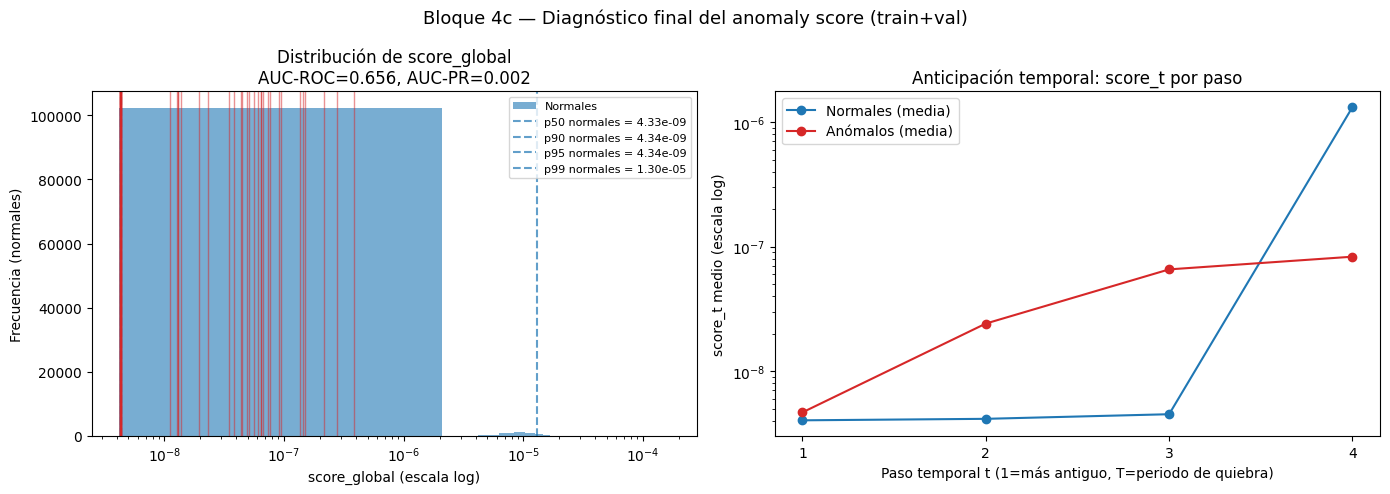


[BLOQUE 4c] Figura guardada en D:\financial_risk_data\results\bloque_4c_score_diagnostico.png


In [15]:
# ============================================================================
# BLOQUE 4c — DIAGNÓSTICO FINAL DEL ENTRENAMIENTO: ANOMALY SCORE
# ============================================================================
# Complementa mse_norm/mse_anom/ratio (medias, sensibles a outliers, no
# capturan separabilidad de las distribuciones completas) con:
#
#   A. AUC-ROC y AUC-PR de score_global (compute_step_scores), calculado
#      directamente sobre el anomaly score que se usaría en producción —
#      sin pasar por ningún clasificador intermedio.
#   B. Percentiles de score_global en normales vs posición de los anómalos
#      en esa distribución — preview informal de la curva PR / selección
#      de umbral tau, sin necesidad de barrer tau explícitamente.
#   C. Anticipación temporal: score_t (por paso, t=1..T) para las
#      secuencias anómalas, comparando el paso más antiguo (t=1) con el
#      paso de quiebra (t=T).
#
# Todo se calcula sobre TRAIN (+val sin positivos, igual que mse_norm/
# mse_anom/ratio). No es un cálculo nuevo de loss ni afecta al entrenamiento;
# es diagnóstico post-hoc sobre el checkpoint ya entrenado.
# ============================================================================

import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import percentileofscore
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. Extraer score_global, score_t e is_anomalous para todas las secuencias
# ---------------------------------------------------------------------------

all_sequences = sequences_train + sequences_val
all_dataset = SequenceDataset(all_sequences)
all_loader = DataLoader(all_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model.eval()

score_global_list = []
score_t_list = []
is_anom_list = []

with torch.no_grad():
    for batch in all_loader:
        x = batch["X"].to(DEVICE)

        e_proj, x_hat = model(x)
        scores = criterion.compute_step_scores(e_proj, x_hat)

        score_global_list.append(scores["score_global"].cpu().numpy())
        score_t_list.append(scores["score_t"].cpu().numpy())
        is_anom_list.append(batch["is_anomalous"].numpy())

SCORE_GLOBAL = np.concatenate(score_global_list, axis=0)  # (N,)
SCORE_T = np.concatenate(score_t_list, axis=0)            # (N, T), orden lógico t=1..T
IS_ANOM = np.concatenate(is_anom_list, axis=0).astype(bool)  # (N,)

print(f"Total secuencias: {len(IS_ANOM)}, anómalas: {IS_ANOM.sum()}")
print(f"SCORE_GLOBAL shape: {SCORE_GLOBAL.shape}, SCORE_T shape: {SCORE_T.shape}")

# ---------------------------------------------------------------------------
# A. AUC-ROC / AUC-PR de score_global
# ---------------------------------------------------------------------------

y = IS_ANOM.astype(int)
auc_roc = roc_auc_score(y, SCORE_GLOBAL)
auc_pr = average_precision_score(y, SCORE_GLOBAL)
baseline_auc_pr = y.sum() / len(y)

print("\n" + "=" * 70)
print("A. SEPARABILIDAD DE score_global (anomaly score real)")
print("=" * 70)
print(f"AUC-ROC : {auc_roc:.4f}  (referencia: 0.5 = azar, 1.0 = perfecto)")
print(f"AUC-PR  : {auc_pr:.6f}  (baseline prevalencia={baseline_auc_pr:.6f}, "
      f"ratio={auc_pr / baseline_auc_pr:.1f}x)")

# ---------------------------------------------------------------------------
# B. Percentiles de score_global en normales vs posición de los anómalos
# ---------------------------------------------------------------------------

score_norm = SCORE_GLOBAL[~IS_ANOM]
score_anom = SCORE_GLOBAL[IS_ANOM]

percentiles_norm = {p: np.percentile(score_norm, p) for p in [50, 90, 95, 99]}

print("\n" + "=" * 70)
print("B. PERCENTILES DE score_global EN NORMALES")
print("=" * 70)
for p, val in percentiles_norm.items():
    n_anom_above = (score_anom > val).sum()
    print(f"  p{p:<3d} = {val:.6e}  ->  anómalos por encima: "
          f"{n_anom_above}/{len(score_anom)} "
          f"({100 * n_anom_above / len(score_anom):.1f}%)")

print("\nPosición de cada score anómalo en la distribución de normales "
      "(percentil):")
percentiles_anom = [percentileofscore(score_norm, s) for s in score_anom]
percentiles_anom_arr = np.array(percentiles_anom)

print(f"  Mediana del percentil de los anómalos : {np.median(percentiles_anom_arr):.1f}")
print(f"  % de anómalos por encima del p95 normal: "
      f"{100 * np.mean(percentiles_anom_arr > 95):.1f}%")
print(f"  % de anómalos por encima del p99 normal: "
      f"{100 * np.mean(percentiles_anom_arr > 99):.1f}%")

# ---------------------------------------------------------------------------
# C. Anticipación temporal: score_t para secuencias anómalas
# ---------------------------------------------------------------------------

score_t_anom = SCORE_T[IS_ANOM]  # (n_anom, T), orden lógico t=1..T

print("\n" + "=" * 70)
print("C. ANTICIPACIÓN TEMPORAL (secuencias anómalas, score_t por paso)")
print("=" * 70)
print(f"{'Paso':<10} {'media':>12} {'mediana':>12}")
for t in range(WINDOW_LENGTH):
    print(f"t={t+1:<8} {score_t_anom[:, t].mean():>12.6e} "
          f"{np.median(score_t_anom[:, t]):>12.6e}")

ratio_anticipacion = score_t_anom[:, 0].mean() / score_t_anom[:, -1].mean()
print(f"\nRatio score_t(t=1) / score_t(t=T) = {ratio_anticipacion:.3f}")
print("  ~1.0 -> score ya elevado en t=1, posible anticipación temprana")
print("  <<1.0 -> score sube solo cerca de t=T (quiebra), poca anticipación")

# ---------------------------------------------------------------------------
# Visualización: histograma de score_global con percentiles y anómalos
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: histograma de normales (log-x) + scores de anómalos
ax = axes[0]
ax.hist(score_norm, bins=80, color="tab:blue", alpha=0.6, label="Normales")
for p, val in percentiles_norm.items():
    ax.axvline(val, linestyle="--", alpha=0.7,
               label=f"p{p} normales = {val:.2e}")
for s in score_anom:
    ax.axvline(s, color="tab:red", alpha=0.5, linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("score_global (escala log)")
ax.set_ylabel("Frecuencia (normales)")
ax.set_title(f"Distribución de score_global\nAUC-ROC={auc_roc:.3f}, "
              f"AUC-PR={auc_pr:.3f}")
ax.legend(fontsize=8)

# Panel 2: score_t medio por paso, normales vs anómalos
ax = axes[1]
score_t_norm = SCORE_T[~IS_ANOM]
steps = np.arange(1, WINDOW_LENGTH + 1)
ax.plot(steps, score_t_norm.mean(axis=0), marker="o", label="Normales (media)",
        color="tab:blue")
ax.plot(steps, score_t_anom.mean(axis=0), marker="o", label="Anómalos (media)",
        color="tab:red")
ax.set_yscale("log")
ax.set_xticks(steps)
ax.set_xlabel("Paso temporal t (1=más antiguo, T=periodo de quiebra)")
ax.set_ylabel("score_t medio (escala log)")
ax.set_title("Anticipación temporal: score_t por paso")
ax.legend()

plt.suptitle("Bloque 4c — Diagnóstico final del anomaly score (train+val)",
              fontsize=13)
plt.tight_layout()

fig_path = RESULTS_DIR / "bloque_4c_score_diagnostico.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\n[BLOQUE 4c] Figura guardada en {fig_path}")

Resultados mixtos pero informativos — hay una discrepancia importante que merece atención antes de cerrar la fase de entrenamiento.
A. AUC-ROC=0.656, AUC-PR=0.0021 — notablemente más bajo que h_T (0.719/0.234)
Esto es llamativo: score_global es, en teoría, una función directa de h_T (vía decoder + MSE ponderado), pero su poder discriminativo (AUC-ROC=0.656) es claramente inferior al de h_T evaluado con regresión logística (AUC-ROC=0.719). La diferencia tiene una explicación clara: score_global es una sola dimensión (un escalar MSE), mientras que la regresión logística sobre h_T usa 48 dimensiones con pesos optimizados para discriminar. Es decir: la información discriminativa está presente en h_T (48-d), pero "colapsarla" a un único número (el error de reconstrucción) pierde gran parte de esa información — hay estructura en h_T que separa clases, pero esa estructura no se traduce directamente en "qué tan grande es el error de reconstrucción".
Esto es importante: significa que el anomaly score actual (MSE de reconstrucción) no es la forma óptima de explotar lo que h_T ya sabe. Es una limitación de diseño del score, no necesariamente del modelo.
B. El patrón p50/p90/p95 idénticos (28/41, 68.3%) — distribución bimodal o con meseta
Que p50, p90 y p95 de score_norm sean prácticamente el mismo valor (4.334e-9, 4.340e-9, 4.344e-9 — diferencias en la 4ª cifra significativa) indica que la inmensa mayoría de los normales (≥95%) tienen un score casi idéntico, y solo el 1% superior se dispara a 1.3e-5 (p99), un salto de 3 órdenes de magnitud. Esto es coherente con lo que vimos en bloque_4b: el AE colapsa la reconstrucción de la mayoría de normales a un error casi constante y mínimo, con una "cola" de normales más difíciles de reconstruir.
Consecuencia práctica para τ: 68.3% de los anómalos caen en esa "meseta superior" justo por encima de p50-p95, pero ninguno (0%) supera p99. Esto significa que un τ en p95-p99 podría capturar hasta el 68% de los anómalos con una tasa de falsos positivos de ~5%, pero subir τ a p99 pierde TODOS los anómalos — los 28 que estaban "por encima de p95" están, aparentemente, en esa franja entre p95 y p99, no por encima de p99.
Esto sugiere una región de τ razonable existe (entre p95 y p99), pero es estrecha — el Notebook 07 deberá barrer τ finamente en ese rango, no solo en percentiles redondos.
C. Anticipación temporal — resultado preocupante
ratio = 0.056: score_t(t=1)≈4.66e-9 es prácticamente idéntico al score normal típico (4.33e-9), mientras score_t(t=4)≈8.3e-8 es ~18x mayor. El score solo se eleva en el último paso de la ventana (t=T, el trimestre de la quiebra) — no hay señal de anticipación en t=1,2,3. Las medias crecen monótonamente t=1→t=4 (4.66e-9 → 2.41e-8 → 6.57e-8 → 8.30e-8), lo cual tiene sentido: el banco se va deteriorando, pero el AE solo lo "nota" claramente en el trimestre de quiebra mismo.
Para un sistema de early warning (que es la motivación declarada en losses.py), esto es una limitación real: el sistema detecta la quiebra en el trimestre de quiebra, no la anticipa con 1-3 trimestres de margen. Dicho esto, hay que matizar: con solo 41 secuencias anómalas, las medias de t=1,2,3 pueden estar dominadas por unos pocos casos con valores grandes (notar que mediana(t=2)≈mediana(t=1)≈4e-9, casi igual al score normal, mientras la media de t=2 ya es 2.4e-8 — sugiere que la media está siendo arrastrada por outliers, y la mayoría de los 41 casos en t=1-3 tienen score normal).
Síntesis: ¿es esto suficiente para cerrar la fase de entrenamiento?
Mi valoración: sí, es suficiente para cerrar el entrenamiento como fase, pero con dos hallazgos que deben pasar como inputs documentados al Notebook 07, no como problemas a resolver aquí:

AUC-PR=0.0021 (ratio 5.5x sobre baseline) es modesto en términos absolutos — comparado con el AUC-PR=0.27 que obtuvo h_T con regresión logística. La fase de entrenamiento ha producido un h_T razonablemente informativo (resuelto el colapso), pero el anomaly score basado en MSE puro no extrae toda esa información. Esto no es un fallo del entrenamiento — es una limitación del diseño del score, y es exactamente el tipo de hallazgo que justifica, como trabajo futuro o como parte del Notebook 07, explorar un score alternativo (ej. distancia de h_T al centroide de h_T de secuencias normales, en lugar de MSE de reconstrucción — un score basado en la representación, no en el error).
Sin anticipación temporal real (ratio=0.056) — limita la utilidad como "early warning" pero no invalida la detección en el momento de la quiebra (AUC-ROC=0.656 sigue siendo >0.5 con margen).

Propuesta
No haría más cambios en la arquitectura/entrenamiento ahora — el colapso está resuelto, y estos hallazgos son sobre el score, no sobre la representación. Cerraría el Notebook 06 documentando:

mse_norm/mse_anom/ratio (entrenamiento) ✓
AUC-ROC/AUC-PR de h_T (representación, vía regresión logística) ✓ — 0.719/0.234
AUC-ROC/AUC-PR de score_global (score de producción, MSE puro) ✓ — 0.656/0.0021
Percentiles y anticipación temporal — documentados como limitaciones conocidas a explorar en el Notebook 07.

Y dejaría como pregunta abierta explícita para el Notebook 07: dado que h_T (AUC-PR=0.27) discrimina mejor que score_global (AUC-PR=0.0021), ¿debería el anomaly score de evaluación basarse en h_T (ej. distancia a un centroide de normalidad) en lugar de, o además de, el MSE de reconstrucción? Esto seguiría siendo no supervisado (el centroide se calcularía sobre h_T de secuencias de train, sin usar failed), y podría cerrar gran parte de la brecha 0.0021→0.27.

# Bloque 5: Ablación y comparación de configuraciones
Justificación teórica
La ablación compara las tres configuraciones de la tabla (d_model=64/lstm_hidden=32, d_model=96/lstm_hidden=48, d_model=128/lstm_hidden=64) con la configuración de referencia fijada en el Bloque 0. Para cada configuración se ejecutan tres semillas y se reportan media y desviación estándar de AUC-PR y F1-score.
La comparación tiene un objetivo dual. Por un lado seleccionar la configuración óptima empíricamente. Por otro lado demostrar estabilidad de los resultados respecto a la inicialización aleatoria, que es el argumento más sólido para defender los resultados ante un tribunal cuando el número de positivos es tan reducido.